<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DU NOTEBOOK

## Contexte

BottleNeck est un marchand de vin qui utilise plusieurs sources de données pour suivre ses produits, ses ventes et ses stocks. Les références issues de l’ERP et du site Web ne correspondent pas directement et doivent être rapprochées à l’aide d’un fichier de liaison.

Les données analysées correspondent :

- à une extraction des stocks au **31 octobre** ;
- aux ventes réalisées du **1er au 31 octobre**.

## Objectifs de l’analyse

Ce notebook vise à :

- contrôler la qualité des données provenant de l’ERP, du site Web et du fichier de liaison ;
- identifier et tracer les anomalies sans modifier les données sources ;
- rapprocher les différentes bases de manière fiable ;
- calculer les principaux indicateurs commerciaux et opérationnels ;
- analyser le chiffre d’affaires, les ventes, les prix, les marges et les stocks ;
- identifier les valeurs atypiques et évaluer leur cohérence métier ;
- formuler des recommandations pour améliorer la qualité des données et la prise de décision ;
- expérimenter et évaluer un POC de prédiction du volume mensuel des ventes.

## Amélioration du livrable

Cette version améliorée renforce la **traçabilité**, la **reproductibilité** et la **fiabilité** des contrôles. L’intelligence artificielle est utilisée comme outil d’assistance pour identifier des pistes d’amélioration, proposer des variantes et générer des tests.

Les solutions proposées par l’IA sont systématiquement vérifiées, comparées et validées avant leur intégration. Les prompts, expérimentations, résultats, limites et décisions sont présentés dans la documentation associée au projet.



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
# Bibliothèques générales
from pathlib import Path
import sys
import warnings

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd
import seaborn as sns
import sklearn

# Validation des données
import pandera
import pandera.pandas as pa

# Clustering
from sklearn.cluster import KMeans

# Prétraitement
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Modèles
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, PoissonRegressor

# Validation et métriques
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score)

from sklearn.model_selection import (
    KFold,
    cross_validate,
    cross_val_predict)

In [2]:
# Configuration de l'affichage des DataFrames
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [3]:
# Définition du répertoire contenant les fichiers sources
DATA_DIR = Path(".")

fichiers = {
    "web": DATA_DIR / "web.xlsx",
    "erp": DATA_DIR / "erp.xlsx",
    "liaison": DATA_DIR / "liaison.xlsx"}

# Vérification de la présence des fichiers
fichiers_manquants = [
    str(chemin)
    for chemin in fichiers.values()
    if not chemin.exists()]

if fichiers_manquants:
    raise FileNotFoundError(
        f"Fichier(s) introuvable(s) : {fichiers_manquants}")

# L’extension Excel signalée concerne des métadonnées non utilisées dans l’analyse
with warnings.catch_warnings():
    warnings.filterwarnings("ignore",
        message="Unknown extension is not supported and will be removed",
        category=UserWarning,
        module=r"openpyxl\..*")

    df_web_raw = pd.read_excel(fichiers["web"])
    df_erp_raw = pd.read_excel(fichiers["erp"])
    df_liaison_raw = pd.read_excel(fichiers["liaison"])
# Création de copies de travail pour préserver les données originales
df_web = df_web_raw.copy()
df_erp = df_erp_raw.copy()
df_liaison = df_liaison_raw.copy()

In [4]:
# Vérification de la structure des fichiers chargés
dataframes = {
    "Web": df_web,
    "ERP": df_erp,
    "Liaison": df_liaison}

for nom, df in dataframes.items():
    print(f"\n{nom} : {df.shape[0]} lignes × {df.shape[1]} colonnes")
    print(f"Colonnes : {df.columns.tolist()}")



Web : 1513 lignes × 29 colonnes
Colonnes : ['sku', 'virtual', 'downloadable', 'rating_count', 'average_rating', 'total_sales', 'tax_status', 'tax_class', 'post_author', 'post_date', 'post_date_gmt', 'post_content', 'product_type', 'post_title', 'post_excerpt', 'post_status', 'comment_status', 'ping_status', 'post_password', 'post_name', 'post_modified', 'post_modified_gmt', 'post_content_filtered', 'post_parent', 'guid', 'menu_order', 'post_type', 'post_mime_type', 'comment_count']

ERP : 825 lignes × 6 colonnes
Colonnes : ['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status', 'purchase_price']

Liaison : 825 lignes × 2 colonnes
Colonnes : ['id_web', 'product_id']


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [5]:
# Aperçu général du fichier ERP
print(
    f"ERP : {df_erp.shape[0]} lignes × "
    f"{df_erp.shape[1]} colonnes")

display(df_erp.head())

ERP : 825 lignes × 6 colonnes


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [6]:
# Synthèse de la structure et de la qualité des variables
resume_erp = pd.DataFrame({
    "type": df_erp.dtypes.astype(str),
    "valeurs_non_nulles": df_erp.notna().sum(),
    "valeurs_manquantes": df_erp.isna().sum(),
    "valeurs_uniques": df_erp.nunique(dropna=True)})

display(resume_erp)

,type,valeurs_non_nulles,valeurs_manquantes,valeurs_uniques
product_id,int64,825,0,825
onsale_web,int64,825,0,2
price,float64,825,0,383
stock_quantity,int64,825,0,84
stock_status,object,825,0,2
purchase_price,float64,825,0,660


In [7]:
# Contrôle des doublons et de l’unicité de la clé ERP
nb_lignes_dupliquees = df_erp.duplicated().sum()
nb_product_id_dupliques = df_erp["product_id"].duplicated().sum()

print(f"Lignes entièrement dupliquées : {nb_lignes_dupliquees}")
print(f"Product_id dupliqués : {nb_product_id_dupliques}")

if nb_product_id_dupliques > 0:
    display(df_erp[df_erp["product_id"].duplicated(keep=False)].sort_values("product_id"))

Lignes entièrement dupliquées : 0
Product_id dupliqués : 0


### 2.1.1 – Analyse détaillée des variables ERP

Cette section analyse les principales variables du fichier ERP afin d’identifier les anomalies, de vérifier leur cohérence et de définir les règles de traitement adaptées.

#### 2.1.1.1 – Analyse de la variable PRIX

In [8]:
# Conversion contrôlée de la variable price sans modifier les données sources
price_numeric = pd.to_numeric(
    df_erp["price"],
    errors="coerce")

# Synthèse de la qualité de la variable price
resume_prix = pd.Series({
    "nombre_observations": len(df_erp),
    "valeurs_manquantes_source": int(df_erp["price"].isna().sum()),
    "valeurs_non_numeriques": int(
        (df_erp["price"].notna() & price_numeric.isna()).sum()),
    "prix_nuls": int((price_numeric == 0).sum()),
    "prix_negatifs": int((price_numeric < 0).sum()),
    "prix_minimum_brut": price_numeric.min(),
    "prix_minimum_valide": price_numeric[price_numeric > 0].min(),
    "prix_maximum": price_numeric.max()})

display(resume_prix.to_frame(name="valeur"))

,valeur
nombre_observations,825.0
valeurs_manquantes_source,0.0
valeurs_non_numeriques,0.0
prix_nuls,0.0
prix_negatifs,3.0
prix_minimum_brut,-20.0
prix_minimum_valide,5.2
prix_maximum,225.0


In [9]:
# Identification et qualification des anomalies de prix
controle_prix_erp = df_erp[
    ["product_id", "price", "purchase_price"]].copy()

controle_prix_erp["price_numeric"] = price_numeric

controle_prix_erp["type_anomalie"] = np.select(
    [    controle_prix_erp["price"].isna(),
        (controle_prix_erp["price"].notna()
         & controle_prix_erp["price_numeric"].isna()),
        controle_prix_erp["price_numeric"] == 0,
        controle_prix_erp["price_numeric"] < 0],
    [   "prix_manquant",
        "prix_non_numerique",
        "prix_nul",
        "prix_negatif"],
    default="valide")

anomalies_prix_erp = controle_prix_erp[
    controle_prix_erp["type_anomalie"] != "valide"].copy()

display(anomalies_prix_erp)

,product_id,price,purchase_price,price_numeric,type_anomalie
151,4233,-20.0,10.33,-20.0,prix_negatif
469,5017,-8.0,4.34,-8.0,prix_negatif
739,6594,-9.1,4.61,-9.1,prix_negatif


In [10]:
# Création d'une variable dédiée aux analyses
# Les prix strictement positifs sont conservés.
# Les valeurs absentes, non numériques, nulles ou négatives
# sont exclues des calculs en attendant une validation métier.
df_erp["price_analysis"] = price_numeric.where(price_numeric > 0)

# Documentation de la décision de traitement
anomalies_prix_erp["decision_traitement"] = ("exclure_des_calculs_analytiques")

anomalies_prix_erp["action_recommandee"] = ("verifier_et_corriger_dans_ERP")

print("Prix négatifs conservés dans la source :", int((df_erp["price"] < 0).sum()))

print("Valeurs exclues de price_analysis :", int(df_erp["price_analysis"].isna().sum()))

Prix négatifs conservés dans la source : 3
Valeurs exclues de price_analysis : 3


### Conclusion – Qualité de la variable `price`

L’analyse de la variable `price` met en évidence **trois valeurs négatives**, associées aux produits 4233, 5017 et 6594. Aucun prix manquant, nul ou non numérique n’a été identifié.

Les valeurs originales sont conservées dans la colonne `price` afin de garantir la traçabilité. Une colonne distincte, `price_analysis`, a été créée pour les analyses : seuls les prix strictement positifs y sont retenus.

Les trois prix négatifs sont exclus des calculs analytiques en attendant une validation par les équipes métier. Une vérification et une correction dans l’ERP sont recommandées.

#### 2.1.1.2 – Analyse de la variable STOCK

Cette section analyse la qualité et la cohérence des informations de stock enregistrées dans l’ERP.

L’analyse porte sur :

- les quantités négatives, nulles, positives ou manquantes ;
- la cohérence entre `stock_quantity` et `stock_status` ;
- l’identification des anomalies nécessitant une validation métier ;
- la création d’une variable dédiée aux analyses, sans modification des données sources.

In [11]:
# Conversion contrôlée de la variable stock_quantity
# sans modifier les données sources
stock_numeric = pd.to_numeric(df_erp["stock_quantity"], errors="coerce")

# Synthèse de la qualité de la variable stock_quantity
resume_stock = pd.Series({"nombre_observations": len(df_erp), "valeurs_manquantes_source": int(df_erp["stock_quantity"].isna().sum()),
    "valeurs_non_numeriques": int((df_erp["stock_quantity"].notna() & stock_numeric.isna()).sum()),
    "stocks_negatifs": int((stock_numeric < 0).sum()),
    "stocks_nuls": int((stock_numeric == 0).sum()),
    "stocks_positifs": int((stock_numeric > 0).sum()),
    "stock_minimum_brut": stock_numeric.min(),
    "stock_maximum": stock_numeric.max()})

display(resume_stock.to_frame(name="valeur"))

,valeur
nombre_observations,825
valeurs_manquantes_source,0
valeurs_non_numeriques,0
stocks_negatifs,2
stocks_nuls,90
stocks_positifs,733
stock_minimum_brut,-10
stock_maximum,145


In [12]:
# Préparation du contrôle de cohérence des stocks
controle_stock_erp = df_erp[
    ["product_id", "stock_quantity", "stock_status"]].copy()

controle_stock_erp["stock_numeric"] = stock_numeric

controle_stock_erp["stock_status_normalise"] = (controle_stock_erp["stock_status"].astype("string").str.strip().str.lower())

# Calcul du statut attendu uniquement pour les quantités valides
controle_stock_erp["stock_status_attendu"] = pd.Series(pd.NA, index=controle_stock_erp.index, dtype="string")

controle_stock_erp.loc[controle_stock_erp["stock_numeric"] == 0, "stock_status_attendu"] = "outofstock"

controle_stock_erp.loc[controle_stock_erp["stock_numeric"] > 0,"stock_status_attendu"] = "instock"

# Qualification des anomalies
controle_stock_erp["type_anomalie"] = np.select([controle_stock_erp["stock_quantity"].isna(),(controle_stock_erp["stock_quantity"].notna()
            & controle_stock_erp["stock_numeric"].isna()),
        controle_stock_erp["stock_numeric"] < 0,
       (controle_stock_erp["stock_numeric"] >= 0) &
       (controle_stock_erp["stock_status_normalise"]
        != controle_stock_erp["stock_status_attendu"])],
       ["stock_manquant",
        "stock_non_numerique",
        "stock_negatif",
        "incoherence_statut_stock"], default="valide")

anomalies_stock_erp = controle_stock_erp[controle_stock_erp["type_anomalie"] != "valide"].copy()

display(anomalies_stock_erp)

,product_id,stock_quantity,stock_status,stock_numeric,stock_status_normalise,stock_status_attendu,type_anomalie
4,4039,3,outofstock,3,outofstock,instock,incoherence_statut_stock
398,4885,0,instock,0,instock,outofstock,incoherence_statut_stock
449,4973,-10,outofstock,-10,outofstock,<NA>,stock_negatif
573,5700,-1,outofstock,-1,outofstock,<NA>,stock_negatif


In [13]:
# Création d'une quantité de stock dédiée aux analyses
# Les quantités négatives ou invalides sont exclues.
df_erp["stock_quantity_analysis"] = stock_numeric.where(stock_numeric >= 0)

# Création d'un statut cohérent destiné aux analyses
df_erp["stock_status_analysis"] = pd.Series(pd.NA, index=df_erp.index, dtype="string")

df_erp.loc[df_erp["stock_quantity_analysis"] == 0, "stock_status_analysis"] = "outofstock"

df_erp.loc[df_erp["stock_quantity_analysis"] > 0, "stock_status_analysis"] = "instock"

# Documentation des décisions de traitement
anomalies_stock_erp["decision_traitement"] = np.select([
        anomalies_stock_erp["type_anomalie"] == "stock_negatif",
        anomalies_stock_erp["type_anomalie"]
        == "incoherence_statut_stock"],
    ["exclure_quantite_des_calculs", "utiliser_statut_calcule_pour_analyse"], default="validation_metier_requise")

anomalies_stock_erp["action_recommandee"] = ("verifier_et_corriger_dans_ERP")

print("Stocks négatifs conservés dans la source :", int((df_erp["stock_quantity"] < 0).sum()))

print("Quantités exclues de stock_quantity_analysis :", int(df_erp["stock_quantity_analysis"].isna().sum()))

print("Incohérences de statut sur quantités valides :",
    int((df_erp["stock_quantity_analysis"].notna() & (df_erp["stock_status"].astype("string")!= df_erp["stock_status_analysis"])).sum()))

Stocks négatifs conservés dans la source : 2
Quantités exclues de stock_quantity_analysis : 2
Incohérences de statut sur quantités valides : 2


### Conclusion – Qualité des variables de stock

L’analyse met en évidence **quatre anomalies** :

- les produits 4973 et 5700 présentent des quantités négatives ;
- le produit 4039 possède un stock positif, mais un statut `outofstock` ;
- le produit 4885 possède un stock nul, mais un statut `instock`.

Les valeurs originales sont conservées dans `stock_quantity` et `stock_status` afin de garantir la traçabilité.

Deux variables distinctes ont été créées pour les analyses :

- `stock_quantity_analysis`, qui exclut les quantités négatives ;
- `stock_status_analysis`, qui recalcule le statut à partir des quantités valides.

Les anomalies doivent être vérifiées et corrigées dans l’ERP. Aucune modification définitive des données sources n’est réalisée dans le notebook.

#### 2.1.1.3 – Analyse de la variable ONSALE_WEB

La variable `onsale_web` indique si un produit ERP est configuré pour être commercialisé sur le site Web.

Cette section vise à :

- vérifier les valeurs présentes dans la variable ;
- identifier les valeurs manquantes ou inattendues ;
- analyser la relation entre la disponibilité en ligne et le statut de stock ;
- repérer les éventuelles incohérences nécessitant une validation métier.

In [14]:
# Contrôle de la variable onsale_web
valeurs_onsale_attendues = [0, 1]
masque_onsale_inattendu = df_erp["onsale_web"].notna() & ~df_erp["onsale_web"].isin(valeurs_onsale_attendues)

resume_onsale = pd.Series({
    "nombre_observations": len(df_erp),
    "valeurs_manquantes": int(df_erp["onsale_web"].isna().sum()),
    "produits_non_actives_web": int((df_erp["onsale_web"] == 0).sum()),
    "produits_actives_web": int((df_erp["onsale_web"] == 1).sum()),
    "valeurs_inattendues": int(masque_onsale_inattendu.sum())})

display(resume_onsale.to_frame(name="valeur"))

,valeur
nombre_observations,825
valeurs_manquantes,0
produits_non_actives_web,109
produits_actives_web,716
valeurs_inattendues,0


In [15]:
# Analyse croisée entre activation Web et statut de stock
statut_stock_affiche = df_erp["stock_status_analysis"].fillna("anomalie_stock")
activation_web_affichee = df_erp["onsale_web"].map({0: "non_active", 1: "active"})

table_onsale_stock = pd.crosstab(
    statut_stock_affiche,
    activation_web_affichee,
    margins=True,
    margins_name="Total")

display(table_onsale_stock)

onsale_web,active,non_active,Total
stock_status_analysis,,,
anomalie_stock,1,1,2
instock,668,65,733
outofstock,47,43,90
Total,716,109,825


### Conclusion – Qualité de la variable `onsale_web`

La variable `onsale_web` est complète et conforme au codage attendu :

- **716 produits** sont activés sur le site Web, soit 86,8 % du catalogue ERP ;
- **109 produits** ne sont pas activés ;
- aucune valeur manquante ou inattendue n’a été identifiée.

L’analyse croisée avec le statut de stock montre notamment :

- 47 produits actifs sur le Web mais actuellement sans stock ;
- 65 produits disposant d’un stock positif mais non activés sur le Web ;
- deux produits présentant une quantité de stock invalide, répartis entre les deux statuts d’activation.

Ces situations ne sont pas automatiquement considérées comme des anomalies. Un produit peut rester visible lorsqu’il est temporairement indisponible, ou être désactivé malgré la présence de stock pour des raisons commerciales.

Une validation auprès des équipes métier serait nécessaire avant de définir une règle de contrôle supplémentaire.

#### 2.1.1.4 – Analyse de la variable PRIX D’ACHAT

La variable `purchase_price` correspond au prix d’achat unitaire enregistré dans l’ERP.

Cette section vise à :

- vérifier le format et la complétude de la variable ;
- identifier les valeurs nulles, négatives ou non numériques ;
- analyser les valeurs minimum et maximum ;
- comparer le prix d’achat au prix de vente hors taxes ;
- repérer les situations pouvant générer une marge négative et nécessitant une validation métier.

In [16]:
# Conversion contrôlée de la variable purchase_price
purchase_price_numeric = pd.to_numeric(df_erp["purchase_price"], errors="coerce")

resume_purchase_price = pd.Series({
    "nombre_observations": len(df_erp),
    "valeurs_manquantes_source": int(df_erp["purchase_price"].isna().sum()),
    "valeurs_non_numeriques": int((df_erp["purchase_price"].notna() & purchase_price_numeric.isna()).sum()),
    "prix_achat_nuls": int((purchase_price_numeric == 0).sum()),
    "prix_achat_negatifs": int((purchase_price_numeric < 0).sum()),
    "prix_achat_minimum": purchase_price_numeric.min(),
    "prix_achat_maximum": purchase_price_numeric.max()})

display(resume_purchase_price.to_frame(name="valeur"))

,valeur
nombre_observations,825.00
valeurs_manquantes_source,0.00
valeurs_non_numeriques,0.00
prix_achat_nuls,0.00
prix_achat_negatifs,0.00
prix_achat_minimum,2.74
prix_achat_maximum,137.81


In [17]:
# Hypothèse métier à confirmer : TVA de 20 %
TAUX_TVA = 0.20

# Variables dédiées aux analyses
df_erp["purchase_price_analysis"] = purchase_price_numeric.where(purchase_price_numeric > 0)
df_erp["price_ht_analysis"] = df_erp["price_analysis"] / (1 + TAUX_TVA)

# Identification des produits dont le prix d’achat dépasse le prix de vente HT
masque_marge_negative = (
    df_erp["price_ht_analysis"].notna()
    & df_erp["purchase_price_analysis"].notna()
    & (df_erp["purchase_price_analysis"] > df_erp["price_ht_analysis"]))

anomalies_prix_achat_erp = df_erp.loc[
    masque_marge_negative,
    ["product_id", "price", "price_ht_analysis", "purchase_price"]].copy()

anomalies_prix_achat_erp["ecart_unitaire"] = (
    anomalies_prix_achat_erp["price_ht_analysis"]
    - anomalies_prix_achat_erp["purchase_price"])

anomalies_prix_achat_erp["action_recommandee"] = ("verifier_prix_vente_prix_achat_et_TVA")

display(anomalies_prix_achat_erp)

,product_id,price,price_ht_analysis,purchase_price,ecart_unitaire,action_recommandee
210,4355,12.65,10.541667,77.48,-66.938333,verifier_prix_vente_prix_achat_et_TVA
391,4864,8.30,6.916667,9.99,-3.073333,verifier_prix_vente_prix_achat_et_TVA
724,6324,92.00,76.666667,99.00,-22.333333,verifier_prix_vente_prix_achat_et_TVA
817,7196,31.00,25.833333,31.20,-5.366667,verifier_prix_vente_prix_achat_et_TVA


### Conclusion – Qualité de la variable `purchase_price`

La variable `purchase_price` est complète et conforme au format attendu :

- aucun prix d’achat manquant ou non numérique ;
- aucune valeur nulle ou négative ;
- des prix d’achat compris entre **2,74 € et 137,81 €**.

En considérant l’hypothèse d’une TVA de 20 %, quatre produits présentent un prix d’achat supérieur au prix de vente HT : 4355, 4864, 6324 et 7196.

Ces écarts peuvent résulter d’une erreur de saisie, d’une mise à jour incomplète des prix, d’une condition commerciale particulière ou d’une hypothèse de TVA inadaptée. Ils ne sont donc pas corrigés automatiquement.

Une validation métier est nécessaire afin de vérifier les prix d’achat, les prix de vente et le taux de TVA applicable avant toute décision de traitement. L’impact réel sur la performance commerciale sera analysé après le rapprochement avec les données de ventes.

### 2.1.2 – Consolidation des anomalies ERP

Les anomalies détectées dans les différentes variables sont regroupées dans un journal unique afin de garantir leur traçabilité.

Ce journal précise la source, le produit concerné, la variable contrôlée, le type d’anomalie, la valeur observée, la référence utilisée, la décision de traitement et l’action métier recommandée.

In [18]:
# Standardisation des anomalies de prix
journal_prix = pd.DataFrame({
    "source": "ERP",
    "product_id": anomalies_prix_erp["product_id"],
    "variable": "price",
    "type_anomalie": anomalies_prix_erp["type_anomalie"],
    "valeur_originale": anomalies_prix_erp["price"],
    "valeur_reference": pd.NA,
    "decision_traitement": anomalies_prix_erp["decision_traitement"],
    "action_recommandee": anomalies_prix_erp["action_recommandee"]})

# Standardisation des anomalies de stock
journal_stock = pd.DataFrame({
    "source": "ERP",
    "product_id": anomalies_stock_erp["product_id"],
    "variable": "stock_quantity / stock_status",
    "type_anomalie": anomalies_stock_erp["type_anomalie"],
    "valeur_originale": anomalies_stock_erp.apply(
        lambda ligne: f"quantite={ligne['stock_quantity']}; statut={ligne['stock_status']}", axis=1),
    "valeur_reference": anomalies_stock_erp["stock_status_attendu"],
    "decision_traitement": anomalies_stock_erp["decision_traitement"],
    "action_recommandee": anomalies_stock_erp["action_recommandee"]})

# Standardisation des anomalies de prix d’achat
journal_prix_achat = pd.DataFrame({
    "source": "ERP",
    "product_id": anomalies_prix_achat_erp["product_id"],
    "variable": "purchase_price",
    "type_anomalie": "prix_achat_superieur_prix_vente_ht",
    "valeur_originale": anomalies_prix_achat_erp["purchase_price"],
    "valeur_reference": anomalies_prix_achat_erp["price_ht_analysis"],
    "decision_traitement": "validation_metier_requise",
    "action_recommandee": anomalies_prix_achat_erp["action_recommandee"]})

# Journal consolidé des anomalies ERP
journal_anomalies_erp = pd.concat(
    [journal_prix, journal_stock, journal_prix_achat], ignore_index=True)

display(journal_anomalies_erp)

,source,product_id,variable,type_anomalie,valeur_originale,valeur_reference,decision_traitement,action_recommandee
0,ERP,4233,price,prix_negatif,-20.0,NaN,exclure_des_calculs_analytiques,verifier_et_corriger_dans_ERP
1,ERP,5017,price,prix_negatif,-8.0,NaN,exclure_des_calculs_analytiques,verifier_et_corriger_dans_ERP
2,ERP,6594,price,prix_negatif,-9.1,NaN,exclure_des_calculs_analytiques,verifier_et_corriger_dans_ERP
3,ERP,4039,stock_quantity / stock_status,incoherence_statut_stock,quantite=3; statut=outofstock,instock,utiliser_statut_calcule_pour_analyse,verifier_et_corriger_dans_ERP
4,ERP,4885,stock_quantity / stock_status,incoherence_statut_stock,quantite=0; statut=instock,outofstock,utiliser_statut_calcule_pour_analyse,verifier_et_corriger_dans_ERP
5,ERP,4973,stock_quantity / stock_status,stock_negatif,quantite=-10; statut=outofstock,<NA>,exclure_quantite_des_calculs,verifier_et_corriger_dans_ERP
6,ERP,5700,stock_quantity / stock_status,stock_negatif,quantite=-1; statut=outofstock,<NA>,exclure_quantite_des_calculs,verifier_et_corriger_dans_ERP
7,ERP,4355,purchase_price,prix_achat_superieur_prix_vente_ht,77.48,10.541667,validation_metier_requise,verifier_prix_vente_prix_achat_et_TVA
8,ERP,4864,purchase_price,prix_achat_superieur_prix_vente_ht,9.99,6.916667,validation_metier_requise,verifier_prix_vente_prix_achat_et_TVA
9,ERP,6324,purchase_price,prix_achat_superieur_prix_vente_ht,99.0,76.666667,validation_metier_requise,verifier_prix_vente_prix_achat_et_TVA


In [19]:
# Synthèse des anomalies ERP par variable et par type
resume_anomalies_erp = (
    journal_anomalies_erp
    .groupby(["variable", "type_anomalie"])
    .size()
    .reset_index(name="nombre_anomalies"))

display(resume_anomalies_erp)
print(f"Nombre total d’anomalies ERP : {len(journal_anomalies_erp)}")

,variable,type_anomalie,nombre_anomalies
0,price,prix_negatif,3
1,purchase_price,prix_achat_superieur_prix_vente_ht,4
2,stock_quantity / stock_status,incoherence_statut_stock,2
3,stock_quantity / stock_status,stock_negatif,2


Nombre total d’anomalies ERP : 11


### Synthèse de la qualité des données ERP

L’analyse du fichier ERP a permis d’identifier et de tracer **11 anomalies** :

- 3 prix de vente négatifs ;
- 2 quantités de stock négatives ;
- 2 incohérences entre la quantité et le statut de stock ;
- 4 prix d’achat supérieurs au prix de vente HT.

Les valeurs sources sont conservées sans modification. Des variables distinctes ont été créées pour les analyses, tandis que les anomalies ont été regroupées dans un journal précisant les décisions de traitement et les actions métier recommandées.

Aucune correction définitive ne doit être appliquée dans les systèmes sans validation des équipes responsables de l’ERP, des stocks, des prix et de la fiscalité.

### 2.2 – Analyse exploratoire du fichier Web

Le fichier Web contient les informations issues du site de vente en ligne : références SKU, quantités vendues, descriptions et caractéristiques des produits.

Cette section vise à :

- analyser la structure et la qualité du fichier ;
- distinguer les produits des pièces jointes et des lignes techniques ;
- vérifier la présence et l’unicité des SKU ;
- identifier les produits sans SKU et les valeurs de ventes incohérentes ;
- sélectionner les variables nécessaires au rapprochement avec l’ERP ;
- préserver les anomalies dans un journal avant de construire la base analytique.

In [20]:
# Aperçu général du fichier Web
print(f"Web : {df_web.shape[0]} lignes × {df_web.shape[1]} colonnes")
display(df_web.head())

Web : 1513 lignes × 29 colonnes


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,NaN,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,NaN,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,NaN,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,NaN,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [21]:
# Synthèse de la structure et de la qualité des variables Web
resume_web = pd.DataFrame({
    "type": df_web.dtypes.astype(str),
    "valeurs_non_nulles": df_web.notna().sum(),
    "valeurs_manquantes": df_web.isna().sum(),
    "valeurs_uniques": df_web.nunique(dropna=True)})

print(f"Le fichier Web contient {df_web.shape[0]} lignes et {df_web.shape[1]} colonnes."),

display(resume_web)

Le fichier Web contient 1513 lignes et 29 colonnes.


,type,valeurs_non_nulles,valeurs_manquantes,valeurs_uniques
sku,object,1428,85,714
virtual,int64,1513,0,1
downloadable,int64,1513,0,1
rating_count,int64,1513,0,1
average_rating,float64,1430,83,1
total_sales,float64,1430,83,29
tax_status,object,716,797,1
tax_class,float64,0,1513,0
post_author,float64,1430,83,2
post_date,datetime64[ns],1430,83,716


In [22]:
# Répartition des lignes selon le type de contenu et la présence du SKU
type_ligne = df_web["post_type"].fillna("post_type_manquant")
presence_sku = df_web["sku"].notna().map({True: "sku_renseigne", False: "sku_manquant"})

table_structure_web = pd.crosstab(type_ligne, presence_sku, margins=True, margins_name="Total")
display(table_structure_web)

sku,sku_manquant,sku_renseigne,Total
post_type,,,
attachment,0,714,714
post_type_manquant,83,0,83
product,2,714,716
Total,85,1428,1513


In [23]:
# Analyse des lignes sans post_type
lignes_sans_post_type = df_web[df_web["post_type"].isna()].copy()

print(f"Nombre de lignes sans post_type : {len(lignes_sans_post_type)}")
print(f"Lignes entièrement dupliquées dans ce groupe : {lignes_sans_post_type.duplicated().sum()}")

colonnes_renseignees_sans_type = lignes_sans_post_type.notna().sum()
display(colonnes_renseignees_sans_type[colonnes_renseignees_sans_type > 0].to_frame("valeurs_renseignees"))

Nombre de lignes sans post_type : 83
Lignes entièrement dupliquées dans ce groupe : 82


,valeurs_renseignees
virtual,83
downloadable,83
rating_count,83


In [24]:
# Identification des produits sans SKU
produits_sans_sku = df_web[(df_web["post_type"] == "product") & (df_web["sku"].isna())].copy()

colonnes_controle_sku = [
    "post_title",
    "total_sales",
    "product_type",
    "post_name",
    "guid"]

display(produits_sans_sku[colonnes_controle_sku])

,post_title,total_sales,product_type,post_name,guid
1084,Pierre Jean Villa Condrieu Jardin Suspendu 2018,-56.0,Vin,pierre-jean-villa-condrieu-suspendu-2018,https://www.bottle-neck.fr/?post_type=product&...
1087,Pierre Jean Villa Côte Rôtie Fongeant 2017,-17.0,Vin,pierre-jean-villa-cote-rotie-fongeant-2017,https://www.bottle-neck.fr/?post_type=product&...


In [25]:
# Extraction d’un identifiant potentiel depuis le guid
produits_sans_sku["product_id_potentiel"] = pd.to_numeric(
    produits_sans_sku["guid"].str.extract(r"p=(\d+)", expand=False), errors="coerce").astype("Int64")

produits_sans_sku["identifiant_present_dans_ERP"] = (produits_sans_sku["product_id_potentiel"].isin(df_erp["product_id"]))

display(produits_sans_sku[["post_title", "total_sales", "product_id_potentiel", "identifiant_present_dans_ERP"]])

,post_title,total_sales,product_id_potentiel,identifiant_present_dans_ERP
1084,Pierre Jean Villa Condrieu Jardin Suspendu 2018,-56.0,5075,True
1087,Pierre Jean Villa Côte Rôtie Fongeant 2017,-17.0,5070,True


In [26]:
# Sélection des lignes correspondant aux produits
df_web_products = df_web[df_web["post_type"] == "product"].copy()

# Conversion contrôlée des ventes
total_sales_numeric = pd.to_numeric(df_web_products["total_sales"], errors="coerce")

# Contrôles de qualité des produits Web
resume_produits_web = pd.Series({
    "nombre_produits": len(df_web_products),
    "sku_manquants": int(df_web_products["sku"].isna().sum()),
    "sku_dupliques_hors_manquants": int(df_web_products["sku"].dropna().duplicated().sum()),
    "sku_non_exclusivement_numeriques": int((~df_web_products["sku"].dropna().astype(str).str.isnumeric()).sum()),
    "ventes_manquantes": int(total_sales_numeric.isna().sum()),
    "ventes_negatives": int((total_sales_numeric < 0).sum()),
    "ventes_nulles": int((total_sales_numeric == 0).sum()),
    "ventes_positives": int((total_sales_numeric > 0).sum()),
    "product_type_manquants": int(df_web_products["product_type"].isna().sum()),
    "post_title_manquants": int(df_web_products["post_title"].isna().sum())})

display(resume_produits_web.to_frame(name="valeur"))

,valeur
nombre_produits,716
sku_manquants,2
sku_dupliques_hors_manquants,0
sku_non_exclusivement_numeriques,2
ventes_manquantes,0
ventes_negatives,2
ventes_nulles,25
ventes_positives,689
product_type_manquants,1
post_title_manquants,0


In [27]:
# Identification des SKU non exclusivement numériques
masque_sku_non_numerique = (
    df_web_products["sku"].notna() & ~df_web_products["sku"].astype(str).str.isnumeric())

sku_non_numeriques = df_web_products.loc[masque_sku_non_numerique, ["sku", "post_title", "product_type", "total_sales"]].copy()

display(sku_non_numeriques)

,sku,post_title,product_type,total_sales
272,13127-1,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,Vin,4.0
1387,bon-cadeau-25-euros,Bon cadeau de 25€,NaN,7.0


In [28]:
# Création des variables Web dédiées aux analyses
df_web_products["sku_analysis"] = df_web_products["sku"].astype("string").str.strip()
df_web_products["sku_analysis"] = df_web_products["sku_analysis"].replace("", pd.NA)

df_web_products["total_sales_analysis"] = total_sales_numeric.where(total_sales_numeric >= 0)
df_web_products["product_type_analysis"] = df_web_products["product_type"].astype("string").fillna("Non renseigné")

# Sélection des produits exploitables pour le rapprochement ERP-Web
masque_web_exploitable = (df_web_products["sku_analysis"].notna() & df_web_products["total_sales_analysis"].notna())

colonnes_web_analysis = [
    "sku",
    "sku_analysis",
    "total_sales",
    "total_sales_analysis",
    "product_type",
    "product_type_analysis",
    "post_title"]

df_web_analysis = df_web_products.loc[masque_web_exploitable, colonnes_web_analysis].copy()

print(f"Produits Web identifiés : {len(df_web_products)}")
print(f"Produits retenus pour l’analyse : {len(df_web_analysis)}")
print(f"Produits exclus et conservés dans le journal : {(~masque_web_exploitable).sum()}")

Produits Web identifiés : 716
Produits retenus pour l’analyse : 714
Produits exclus et conservés dans le journal : 2


In [29]:
# Identification des produits sans catégorie
produits_sans_type = df_web_products[df_web_products["product_type"].isna()].copy()

display(produits_sans_type[["sku", "post_title", "total_sales", "product_type_analysis"]])

,sku,post_title,total_sales,product_type_analysis
1387,bon-cadeau-25-euros,Bon cadeau de 25€,7.0,Non renseigné


### 2.2.1 – Consolidation des anomalies Web

Cette section consolide les anomalies et particularités identifiées dans le fichier Web afin d’assurer leur traçabilité.

Les contrôles distinguent :

- les anomalies bloquantes pour le rapprochement ou les calculs, comme l’absence de SKU et les ventes négatives ;
- les informations incomplètes mais exploitables, comme une catégorie produit non renseignée ;
- les lignes techniques issues de l’export, exclues du périmètre analytique sans être supprimées de la source.

Aucune correction automatique n’est appliquée aux données d’origine. Chaque cas fait l’objet d’une décision de traitement et d’une recommandation.

In [30]:
# Préparation des groupes d’anomalies
ventes_negatives_web = df_web_products[total_sales_numeric < 0].copy()
lignes_techniques_web = df_web[df_web["post_type"].isna()].copy()

anomalies_web = []

# Produits sans SKU
for _, ligne in produits_sans_sku.iterrows():
    anomalies_web.append({
        "source": "Web",
        "product_id": pd.NA,
        "variable": "sku",
        "type_anomalie": "sku_manquant",
        "valeur_originale": ligne["post_title"],
        "valeur_reference": f"product_id potentiel={ligne['product_id_potentiel']}",
        "decision_traitement": "exclure_du_rapprochement_automatique",
        "action_recommandee": "valider_identifiant_et_completer_SKU"})

# Ventes négatives
for _, ligne in ventes_negatives_web.iterrows():
    anomalies_web.append({
        "source": "Web",
        "product_id": pd.NA,
        "variable": "total_sales",
        "type_anomalie": "ventes_negatives",
        "valeur_originale": f"{ligne['post_title']} | total_sales={ligne['total_sales']}",
        "valeur_reference": "valeur_attendue_superieure_ou_egale_a_0",
        "decision_traitement": "exclure_des_calculs_analytiques",
        "action_recommandee": "verifier_retour_annulation_ou_erreur_de_saisie"})

# Catégorie produit manquante
for _, ligne in produits_sans_type.iterrows():
    anomalies_web.append({
        "source": "Web",
        "product_id": pd.NA,
        "variable": "product_type",
        "type_anomalie": "categorie_non_renseignee",
        "valeur_originale": ligne["sku"],
        "valeur_reference": "Non renseigné",
        "decision_traitement": "conserver_dans_analyse",
        "action_recommandee": "completer_categorie_dans_Web"})

# Lignes techniques de l’export
anomalies_web.append({
    "source": "Web",
    "product_id": pd.NA,
    "variable": "structure_export",
    "type_anomalie": "lignes_techniques",
    "valeur_originale": f"{len(lignes_techniques_web)} lignes dont {lignes_techniques_web.duplicated().sum()} dupliquées",
    "valeur_reference": "ligne_product_ou_attachment",
    "decision_traitement": "exclure_de_la_base_analytique",
    "action_recommandee": "verifier_le_parametrage_de_export_Web"})

# Création du journal consolidé
journal_anomalies_web = pd.DataFrame(anomalies_web)

display(journal_anomalies_web)

,source,product_id,variable,type_anomalie,valeur_originale,valeur_reference,decision_traitement,action_recommandee
0,Web,<NA>,sku,sku_manquant,Pierre Jean Villa Condrieu Jardin Suspendu 2018,product_id potentiel=5075,exclure_du_rapprochement_automatique,valider_identifiant_et_completer_SKU
1,Web,<NA>,sku,sku_manquant,Pierre Jean Villa Côte Rôtie Fongeant 2017,product_id potentiel=5070,exclure_du_rapprochement_automatique,valider_identifiant_et_completer_SKU
2,Web,<NA>,total_sales,ventes_negatives,Pierre Jean Villa Condrieu Jardin Suspendu 201...,valeur_attendue_superieure_ou_egale_a_0,exclure_des_calculs_analytiques,verifier_retour_annulation_ou_erreur_de_saisie
3,Web,<NA>,total_sales,ventes_negatives,Pierre Jean Villa Côte Rôtie Fongeant 2017 | t...,valeur_attendue_superieure_ou_egale_a_0,exclure_des_calculs_analytiques,verifier_retour_annulation_ou_erreur_de_saisie
4,Web,<NA>,product_type,categorie_non_renseignee,bon-cadeau-25-euros,Non renseigné,conserver_dans_analyse,completer_categorie_dans_Web
5,Web,<NA>,structure_export,lignes_techniques,83 lignes dont 82 dupliquées,ligne_product_ou_attachment,exclure_de_la_base_analytique,verifier_le_parametrage_de_export_Web


In [31]:
resume_anomalies_web = (
    journal_anomalies_web
    .groupby(["variable", "type_anomalie"])
    .size()
    .reset_index(name="nombre_anomalies"))

display(resume_anomalies_web)

,variable,type_anomalie,nombre_anomalies
0,product_type,categorie_non_renseignee,1
1,sku,sku_manquant,2
2,structure_export,lignes_techniques,1
3,total_sales,ventes_negatives,2


### Conclusion sur la qualité du fichier Web

Le fichier Web contient **1 513 lignes**, réparties entre :

- **716 produits** ;
- **714 pièces jointes** (`attachment`) ;
- **83 lignes techniques sans `post_type`**, dont 82 sont entièrement dupliquées.

Parmi les 716 produits, **714 disposent d’un SKU et de ventes exploitables**. Deux produits présentent simultanément un SKU manquant et des ventes négatives. Ils sont conservés dans les données sources, mais exclus du rapprochement automatique et des calculs analytiques dans l’attente d’une validation métier.

Deux SKU ne sont pas exclusivement numériques (`13127-1` et `bon-cadeau-25-euros`). Ils correspondent toutefois à des identifiants métier valides et ne sont donc pas considérés comme des anomalies.

Le produit `bon-cadeau-25-euros` ne possède pas de catégorie renseignée. Il est conservé dans l’analyse avec la valeur normalisée `Non renseigné`, sans modification de la donnée d’origine.

Les pièces jointes et les lignes techniques sont exclues du périmètre analytique, mais restent conservées dans la source brute. Le journal Web contient **6 enregistrements de contrôle**, correspondant à **4 catégories d’anomalies ou de particularités**.

### 2.3 – Analyse du fichier de liaison

Le fichier de liaison permet de rapprocher les références produits de l’ERP (`product_id`) avec les références utilisées sur le site Web (`id_web`).

Cette section vise à :

- vérifier la complétude et l’unicité des identifiants ;
- contrôler la présence des `product_id` dans l’ERP ;
- vérifier que les `id_web` renseignés correspondent à des SKU présents parmi les produits Web ;
- identifier les liaisons manquantes ou invalides ;
- préparer une table de liaison fiable pour le rapprochement des données.

In [32]:
print(f"Le fichier de liaison contient {df_liaison.shape[0]} lignes et {df_liaison.shape[1]} colonnes.")
display(df_liaison.head())

resume_liaison = pd.DataFrame({
    "valeur": [
        len(df_liaison),
        df_liaison["product_id"].isna().sum(),
        df_liaison["id_web"].isna().sum(),
        df_liaison["product_id"].dropna().duplicated().sum(),
        df_liaison["id_web"].dropna().duplicated().sum()]}, index=[
    "nombre_observations",
    "product_id_manquants",
    "id_web_manquants",
    "product_id_dupliques_hors_manquants",
    "id_web_dupliques_hors_manquants"])

display(resume_liaison)

Le fichier de liaison contient 825 lignes et 2 colonnes.


,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039


,valeur
nombre_observations,825
product_id_manquants,0
id_web_manquants,91
product_id_dupliques_hors_manquants,0
id_web_dupliques_hors_manquants,0


In [33]:
# Création de variables normalisées pour les contrôles
df_liaison["product_id_analysis"] = pd.to_numeric(df_liaison["product_id"], errors="coerce").astype("Int64")

df_liaison["id_web_analysis"] = (
    df_liaison["id_web"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA))

# Vérification des product_id dans l’ERP
product_ids_erp = set(pd.to_numeric(df_erp["product_id"], errors="coerce").dropna().astype(int))

masque_product_id_absent_erp = ~df_liaison["product_id_analysis"].isin(product_ids_erp)
liaisons_absentes_erp = df_liaison[masque_product_id_absent_erp].copy()

print("Product_id présents dans l’ERP :", len(df_liaison) - len(liaisons_absentes_erp))
print("Product_id absents de l’ERP :", len(liaisons_absentes_erp))

if not liaisons_absentes_erp.empty:
    display(liaisons_absentes_erp)

Product_id présents dans l’ERP : 825
Product_id absents de l’ERP : 0


In [34]:
# Ensemble des SKU présents parmi les produits Web
sku_web_valides = set(df_web_products["sku_analysis"].dropna())

# Classification des lignes du fichier de liaison
masque_id_web_manquant = df_liaison["id_web_analysis"].isna()
masque_id_web_valide = df_liaison["id_web_analysis"].isin(sku_web_valides)

df_liaison["statut_liaison_web"] = np.select(
    [masque_id_web_manquant, masque_id_web_valide],
    ["id_web_manquant", "liaison_valide"], default="id_web_absent_du_Web")

resume_statut_liaison = (
    df_liaison["statut_liaison_web"]
    .value_counts()
    .rename_axis("statut")
    .reset_index(name="nombre"))

display(resume_statut_liaison)

,statut,nombre
0,liaison_valide,714
1,id_web_manquant,91
2,id_web_absent_du_Web,20


In [35]:
# Normalisation des identifiants
df_liaison["product_id_analysis"] = pd.to_numeric(df_liaison["product_id"], errors="coerce").astype("Int64")

df_liaison["id_web_analysis"] = (df_liaison["id_web"].astype("string").str.strip().replace("", pd.NA))

df_web_products["sku_analysis"] = (df_web_products["sku"].astype("string").str.strip().replace("", pd.NA))

# Vérification de la présence des id_web parmi les produits Web
sku_web_valides = set(df_web_products["sku_analysis"].dropna())

masque_id_web_manquant = df_liaison["id_web_analysis"].isna()
masque_id_web_valide = df_liaison["id_web_analysis"].isin(sku_web_valides)

df_liaison["statut_liaison_web"] = np.select([masque_id_web_manquant, masque_id_web_valide], ["id_web_manquant", "liaison_valide"], default="id_web_absent_du_Web")

# Ajout du statut de commercialisation provenant de l’ERP
onsale_par_product_id = df_erp.set_index("product_id")["onsale_web"]
df_liaison["onsale_web_erp"] = df_liaison["product_id_analysis"].map(onsale_par_product_id)

df_liaison["statut_vente_web"] = df_liaison["onsale_web_erp"].map({0: "non_active", 1: "active"})

# Croisement des résultats
tableau_controle_liaison = pd.crosstab(
    df_liaison["statut_liaison_web"],
    df_liaison["statut_vente_web"],
    margins=True)

display(tableau_controle_liaison)

statut_vente_web,active,non_active,All
statut_liaison_web,,,
id_web_absent_du_Web,0,20,20
id_web_manquant,3,88,91
liaison_valide,713,1,714
All,716,109,825


In [36]:
# Cas prioritaires : produits actifs sans liaison ou produit inactif encore lié au Web
masque_cas_prioritaire = (
    ((df_liaison["statut_vente_web"] == "active") &
     (df_liaison["statut_liaison_web"] != "liaison_valide"))|
    ((df_liaison["statut_vente_web"] == "non_active") &
     (df_liaison["statut_liaison_web"] == "liaison_valide")))

cas_prioritaires_liaison = df_liaison.loc[masque_cas_prioritaire, ["product_id", "id_web", "onsale_web_erp", "statut_liaison_web"]].copy()

display(cas_prioritaires_liaison)

,product_id,id_web,onsale_web_erp,statut_liaison_web
123,4200,16295,0,liaison_valide
242,4594,NaN,1,id_web_manquant
486,5070,NaN,1,id_web_manquant
487,5075,NaN,1,id_web_manquant


In [37]:
references_obsoletes_liaison = df_liaison.loc[
    df_liaison["statut_liaison_web"] == "id_web_absent_du_Web", ["product_id", "id_web", "onsale_web_erp", "statut_liaison_web"]].copy()

print("Références potentiellement obsolètes :", len(references_obsoletes_liaison))
display(references_obsoletes_liaison)

Références potentiellement obsolètes : 20


,product_id,id_web,onsale_web_erp,statut_liaison_web
193,4289,13771,0,id_web_absent_du_Web
236,4568,15065,0,id_web_absent_du_Web
241,4584,14785,0,id_web_absent_du_Web
355,4741,12601,0,id_web_absent_du_Web
391,4864,15154,0,id_web_absent_du_Web
394,4869,14360,0,id_web_absent_du_Web
424,4921,15608,0,id_web_absent_du_Web
425,4922,15586,0,id_web_absent_du_Web
470,5018,15272,0,id_web_absent_du_Web
473,5021,15630,0,id_web_absent_du_Web


### 2.3.1 – Consolidation des anomalies du fichier de liaison

Les anomalies sont qualifiées en tenant compte du statut de commercialisation enregistré dans l’ERP.

L’absence d’un `id_web` n’est pas considérée comme une anomalie lorsque le produit n’est pas commercialisé en ligne. En revanche, les produits actifs sans liaison, les incohérences de statut et les références potentiellement obsolètes sont conservés dans le journal de contrôle.

In [38]:
actifs_sans_liaison = df_liaison[
    (df_liaison["statut_vente_web"] == "active") & (df_liaison["statut_liaison_web"] != "liaison_valide")].copy()

inactifs_avec_liaison = df_liaison[(df_liaison["statut_vente_web"] == "non_active") & (df_liaison["statut_liaison_web"] == "liaison_valide")].copy()

anomalies_liaison = []

# Produits actifs sans id_web
for _, ligne in actifs_sans_liaison.iterrows():anomalies_liaison.append({
        "source": "Liaison",
        "product_id": ligne["product_id"],
        "variable": "id_web",
        "type_anomalie": "id_web_manquant_produit_actif",
        "valeur_originale": pd.NA,
        "valeur_reference": "onsale_web=1",
        "decision_traitement": "exclure_du_rapprochement_automatique",
        "action_recommandee": "completer_et_valider_la_table_de_liaison"})

# Produit inactif possédant encore une liaison valide
for _, ligne in inactifs_avec_liaison.iterrows():anomalies_liaison.append({
        "source": "Liaison",
        "product_id": ligne["product_id"],
        "variable": "onsale_web / id_web",
        "type_anomalie": "produit_inactif_avec_liaison_valide",
        "valeur_originale": f"id_web={ligne['id_web']}; onsale_web=0",
        "valeur_reference": "statuts_a_mettre_en_coherence",
        "decision_traitement": "conserver_sous_reserve_de_validation",
        "action_recommandee": "verifier_activation_Web_et_statut_ERP"})

# Références potentiellement obsolètes
for _, ligne in references_obsoletes_liaison.iterrows():anomalies_liaison.append({
        "source": "Liaison",
        "product_id": ligne["product_id"],
        "variable": "id_web",
        "type_anomalie": "reference_potentiellement_obsolete",
        "valeur_originale": ligne["id_web"],
        "valeur_reference": "SKU_absent_du_fichier_Web_actuel",
        "decision_traitement": "exclure_du_rapprochement_courant",
        "action_recommandee": "verifier_historique_et_nettoyer_la_liaison"})

journal_anomalies_liaison = pd.DataFrame(anomalies_liaison)
display(journal_anomalies_liaison)

,source,product_id,variable,type_anomalie,valeur_originale,valeur_reference,decision_traitement,action_recommandee
0,Liaison,4594,id_web,id_web_manquant_produit_actif,<NA>,onsale_web=1,exclure_du_rapprochement_automatique,completer_et_valider_la_table_de_liaison
1,Liaison,5070,id_web,id_web_manquant_produit_actif,<NA>,onsale_web=1,exclure_du_rapprochement_automatique,completer_et_valider_la_table_de_liaison
2,Liaison,5075,id_web,id_web_manquant_produit_actif,<NA>,onsale_web=1,exclure_du_rapprochement_automatique,completer_et_valider_la_table_de_liaison
3,Liaison,4200,onsale_web / id_web,produit_inactif_avec_liaison_valide,id_web=16295; onsale_web=0,statuts_a_mettre_en_coherence,conserver_sous_reserve_de_validation,verifier_activation_Web_et_statut_ERP
4,Liaison,4289,id_web,reference_potentiellement_obsolete,13771,SKU_absent_du_fichier_Web_actuel,exclure_du_rapprochement_courant,verifier_historique_et_nettoyer_la_liaison
5,Liaison,4568,id_web,reference_potentiellement_obsolete,15065,SKU_absent_du_fichier_Web_actuel,exclure_du_rapprochement_courant,verifier_historique_et_nettoyer_la_liaison
6,Liaison,4584,id_web,reference_potentiellement_obsolete,14785,SKU_absent_du_fichier_Web_actuel,exclure_du_rapprochement_courant,verifier_historique_et_nettoyer_la_liaison
7,Liaison,4741,id_web,reference_potentiellement_obsolete,12601,SKU_absent_du_fichier_Web_actuel,exclure_du_rapprochement_courant,verifier_historique_et_nettoyer_la_liaison
8,Liaison,4864,id_web,reference_potentiellement_obsolete,15154,SKU_absent_du_fichier_Web_actuel,exclure_du_rapprochement_courant,verifier_historique_et_nettoyer_la_liaison
9,Liaison,4869,id_web,reference_potentiellement_obsolete,14360,SKU_absent_du_fichier_Web_actuel,exclure_du_rapprochement_courant,verifier_historique_et_nettoyer_la_liaison


In [39]:
resume_anomalies_liaison = (
    journal_anomalies_liaison
    .groupby(["variable", "type_anomalie"])
    .size()
    .reset_index(name="nombre_anomalies"))

display(resume_anomalies_liaison)

,variable,type_anomalie,nombre_anomalies
0,id_web,id_web_manquant_produit_actif,3
1,id_web,reference_potentiellement_obsolete,20
2,onsale_web / id_web,produit_inactif_avec_liaison_valide,1


### Conclusion sur la qualité du fichier de liaison

Le fichier de liaison contient **825 références ERP**. Tous les `product_id` sont renseignés, uniques et présents dans le fichier ERP.

Parmi les correspondances Web :

- **714 liaisons sont valides** ;
- **91 `id_web` sont manquants** ;
- **20 `id_web` renseignés ne sont pas présents parmi les produits du fichier Web actuel**.

Le croisement avec la variable `onsale_web` montre cependant que toutes les absences ne constituent pas des anomalies :

- 88 produits inactifs ne possèdent pas d’`id_web`, ce qui est cohérent avec leur absence de commercialisation en ligne ;
- 3 produits actifs (`4594`, `5070` et `5075`) ne possèdent pas d’`id_web` et nécessitent une validation prioritaire ;
- 20 produits inactifs disposent de références qui ne sont plus retrouvées dans le fichier Web actuel et sont considérées comme potentiellement obsolètes ;
- 1 produit (`4200`) est déclaré inactif dans l’ERP alors qu’il possède encore une liaison Web valide.

Les données sources restent inchangées. Seules les **714 correspondances valides** seront utilisées pour le rapprochement automatique. Les autres situations sont conservées dans le journal des anomalies avec une décision de traitement et une action recommandée.

### 2.3.2 – Visualisation de la qualité des correspondances

La visualisation croise le statut de la liaison avec le statut de commercialisation Web enregistré dans l’ERP.

Cette approche permet de distinguer les absences de liaison cohérentes avec un produit inactif des situations nécessitant une validation métier.

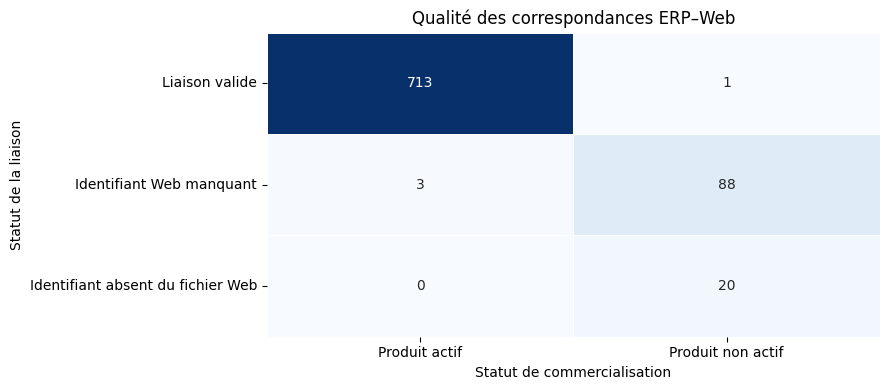

In [40]:
tableau_visualisation_liaison = pd.crosstab(df_liaison["statut_liaison_web"], df_liaison["statut_vente_web"])

tableau_visualisation_liaison = tableau_visualisation_liaison.reindex(["liaison_valide", "id_web_manquant", "id_web_absent_du_Web"])

tableau_visualisation_liaison = tableau_visualisation_liaison.rename(
    index={
        "liaison_valide": "Liaison valide",
        "id_web_manquant": "Identifiant Web manquant",
        "id_web_absent_du_Web": "Identifiant absent du fichier Web"},
    columns={
        "active": "Produit actif",
        "non_active": "Produit non actif"})

plt.figure(figsize=(9, 4))
sns.heatmap(
    tableau_visualisation_liaison,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5)

plt.title("Qualité des correspondances ERP–Web")
plt.xlabel("Statut de commercialisation")
plt.ylabel("Statut de la liaison")
plt.tight_layout()
plt.show()

La majorité des produits actifs disposent d’une liaison valide (**713 produits**).

Parmi les 91 identifiants Web manquants, **88 concernent des produits inactifs** et ne constituent donc pas une anomalie prioritaire. En revanche, **3 produits actifs ne possèdent pas de liaison** et nécessitent une validation.

Par ailleurs, **20 produits inactifs** disposent d’une référence absente du fichier Web actuel, ce qui peut indiquer des liaisons obsolètes. Enfin, un produit déclaré inactif dans l’ERP possède encore une liaison Web valide.

Cette visualisation remplace le graphique circulaire initial, qui ne permettait pas de distinguer ces différentes situations.

### 2.4 – Consolidation globale des anomalies

Les journaux de contrôle issus de l’ERP, du fichier Web et de la table de liaison sont regroupés dans une structure unique.

Cette consolidation permet de :

- centraliser la traçabilité des anomalies ;
- identifier la source et la variable concernées ;
- conserver la décision de traitement appliquée ;
- formaliser les actions correctives recommandées ;
- préparer la priorisation des corrections.

Un enregistrement du journal correspond à un contrôle documenté. Il ne représente pas nécessairement un produit distinct, car un même produit peut présenter plusieurs anomalies et certaines lignes peuvent synthétiser plusieurs occurrences.

In [41]:
colonnes_journal = [
    "source",
    "product_id",
    "variable",
    "type_anomalie",
    "valeur_originale",
    "valeur_reference",
    "decision_traitement",
    "action_recommandee"]

journal_anomalies_global = pd.concat([
        journal_anomalies_erp[colonnes_journal],
        journal_anomalies_web[colonnes_journal],
        journal_anomalies_liaison[colonnes_journal]], ignore_index=True)

resume_journal_par_source = (
    journal_anomalies_global["source"]
    .value_counts()
    .rename_axis("source")
    .reset_index(name="nombre_enregistrements"))

print(f"Journal global : {len(journal_anomalies_global)} enregistrements de contrôle")
display(resume_journal_par_source)
display(journal_anomalies_global.head(10))

Journal global : 41 enregistrements de contrôle


,source,nombre_enregistrements
0,Liaison,24
1,ERP,11
2,Web,6


,source,product_id,variable,type_anomalie,valeur_originale,valeur_reference,decision_traitement,action_recommandee
0,ERP,4233,price,prix_negatif,-20.0,NaN,exclure_des_calculs_analytiques,verifier_et_corriger_dans_ERP
1,ERP,5017,price,prix_negatif,-8.0,NaN,exclure_des_calculs_analytiques,verifier_et_corriger_dans_ERP
2,ERP,6594,price,prix_negatif,-9.1,NaN,exclure_des_calculs_analytiques,verifier_et_corriger_dans_ERP
3,ERP,4039,stock_quantity / stock_status,incoherence_statut_stock,quantite=3; statut=outofstock,instock,utiliser_statut_calcule_pour_analyse,verifier_et_corriger_dans_ERP
4,ERP,4885,stock_quantity / stock_status,incoherence_statut_stock,quantite=0; statut=instock,outofstock,utiliser_statut_calcule_pour_analyse,verifier_et_corriger_dans_ERP
5,ERP,4973,stock_quantity / stock_status,stock_negatif,quantite=-10; statut=outofstock,<NA>,exclure_quantite_des_calculs,verifier_et_corriger_dans_ERP
6,ERP,5700,stock_quantity / stock_status,stock_negatif,quantite=-1; statut=outofstock,<NA>,exclure_quantite_des_calculs,verifier_et_corriger_dans_ERP
7,ERP,4355,purchase_price,prix_achat_superieur_prix_vente_ht,77.48,10.541667,validation_metier_requise,verifier_prix_vente_prix_achat_et_TVA
8,ERP,4864,purchase_price,prix_achat_superieur_prix_vente_ht,9.99,6.916667,validation_metier_requise,verifier_prix_vente_prix_achat_et_TVA
9,ERP,6324,purchase_price,prix_achat_superieur_prix_vente_ht,99.0,76.666667,validation_metier_requise,verifier_prix_vente_prix_achat_et_TVA


#### 2.4.1 – Priorisation des anomalies

Les anomalies sont classées selon trois niveaux :

- **Haute** : anomalie pouvant fausser les indicateurs financiers ou opérationnels, ou empêcher le rapprochement des données ;
- **Moyenne** : incohérence nécessitant une validation ou une maintenance des référentiels, sans bloquer l’analyse actuelle ;
- **Faible** : problème de complétude ou de structure ayant un impact limité sur les résultats.

Cette classification facilite la planification des actions correctives et ne remplace pas la validation des équipes métier.

In [42]:
dictionnaire_priorites = pd.DataFrame([{
        "niveau_priorite": "Haute",
        "definition": "Anomalie pouvant fausser les indicateurs ou empêcher le rapprochement des données.",
        "exemples": "Prix, ventes ou stocks négatifs ; SKU manquant ; produit actif sans liaison.",
        "traitement_recommande": "Analyser et faire valider avant la production des indicateurs définitifs."},

    {    "niveau_priorite": "Moyenne",
        "definition": "Incohérence de référentiel sans impact bloquant sur l’analyse actuelle.",
        "exemples": "Référence potentiellement obsolète ; produit inactif avec liaison Web valide.",
        "traitement_recommande": "Intégrer au plan de maintenance et faire valider par les équipes métier."},

    {   "niveau_priorite": "Faible",
        "definition": "Problème de complétude ou de structure ayant un impact analytique limité.",
        "exemples": "Catégorie non renseignée ; lignes techniques dans l’export.",
        "traitement_recommande": "Corriger dans le cadre de l’amélioration continue des données."},

    {   "niveau_priorite": "À qualifier",
        "definition": "Anomalie non couverte par les règles de priorisation définies.",
        "exemples": "Nouveau type d’anomalie détecté lors d’un contrôle ultérieur.",
        "traitement_recommande": "Effectuer une analyse manuelle avant de définir la priorité."}])

style_dictionnaire = (dictionnaire_priorites.style
    .set_properties(subset=["niveau_priorite"], **{"min-width": "120px", "font-weight": "bold"})
    .set_properties(subset=["definition", "exemples", "traitement_recommande"],
                    **{"min-width": "300px", "max-width": "430px", "white-space": "normal", "text-align": "left"}).hide(axis="index"))

with pd.option_context("display.max_colwidth", None): display(style_dictionnaire)

niveau_priorite,definition,exemples,traitement_recommande
Haute,Anomalie pouvant fausser les indicateurs ou empêcher le rapprochement des données.,"Prix, ventes ou stocks négatifs ; SKU manquant ; produit actif sans liaison.",Analyser et faire valider avant la production des indicateurs définitifs.
Moyenne,Incohérence de référentiel sans impact bloquant sur l’analyse actuelle.,Référence potentiellement obsolète ; produit inactif avec liaison Web valide.,Intégrer au plan de maintenance et faire valider par les équipes métier.
Faible,Problème de complétude ou de structure ayant un impact analytique limité.,Catégorie non renseignée ; lignes techniques dans l’export.,Corriger dans le cadre de l’amélioration continue des données.
À qualifier,Anomalie non couverte par les règles de priorisation définies.,Nouveau type d’anomalie détecté lors d’un contrôle ultérieur.,Effectuer une analyse manuelle avant de définir la priorité.


In [43]:
# Attribution des priorités
anomalies_hautes = ["prix_negatif", "prix_achat_superieur_prix_vente_ht", "incoherence_statut_stock", "stock_negatif", "sku_manquant", "ventes_negatives", "id_web_manquant_produit_actif"]
anomalies_moyennes = ["reference_potentiellement_obsolete", "produit_inactif_avec_liaison_valide"]
anomalies_faibles = ["categorie_non_renseignee", "lignes_techniques"]

mapping_priorites = {x: "Haute" for x in anomalies_hautes}
mapping_priorites.update({x: "Moyenne" for x in anomalies_moyennes})
mapping_priorites.update({x: "Faible" for x in anomalies_faibles})
journal_anomalies_global["niveau_priorite"] = journal_anomalies_global["type_anomalie"].map(mapping_priorites).fillna("À qualifier")

# Synthèse des priorités
ordre_priorites = ["Haute", "Moyenne", "Faible", "À qualifier"]
resume_priorites = (journal_anomalies_global["niveau_priorite"].value_counts()
    .reindex(ordre_priorites, fill_value=0)
    .rename_axis("niveau_priorite")
    .reset_index(name="nombre_enregistrements")
    .merge(dictionnaire_priorites[["niveau_priorite", "definition", "traitement_recommande"]], on="niveau_priorite", how="left"))

resume_priorites = resume_priorites[["niveau_priorite", "definition", "nombre_enregistrements", "traitement_recommande"]]

# Affichage unique
style_priorites = (resume_priorites.style
    .set_properties(subset=["definition", "traitement_recommande"], **{"min-width": "320px", "max-width": "450px", "white-space": "normal", "text-align": "left"})
    .set_properties(subset=["niveau_priorite"], **{"font-weight": "bold"})
    .hide(axis="index"))

with pd.option_context("display.max_colwidth", None):
    display(style_priorites)

niveau_priorite,definition,nombre_enregistrements,traitement_recommande
Haute,Anomalie pouvant fausser les indicateurs ou empêcher le rapprochement des données.,18,Analyser et faire valider avant la production des indicateurs définitifs.
Moyenne,Incohérence de référentiel sans impact bloquant sur l’analyse actuelle.,21,Intégrer au plan de maintenance et faire valider par les équipes métier.
Faible,Problème de complétude ou de structure ayant un impact analytique limité.,2,Corriger dans le cadre de l’amélioration continue des données.
À qualifier,Anomalie non couverte par les règles de priorisation définies.,0,Effectuer une analyse manuelle avant de définir la priorité.


### Conclusion du journal global des anomalies

Le journal consolidé contient **41 enregistrements de contrôle** issus de l’ERP, du fichier Web et de la table de liaison.

La priorisation identifie :

- **18 contrôles de priorité haute**, susceptibles de fausser les indicateurs ou d’empêcher le rapprochement des données ;
- **21 contrôles de priorité moyenne**, principalement liés à la cohérence et à la maintenance des référentiels ;
- **2 contrôles de priorité faible**, relatifs à la complétude ou à la structure des données ;
- **aucun contrôle restant à qualifier**.

Les anomalies de priorité haute doivent être analysées et validées avant la production des indicateurs définitifs. Les autres contrôles alimentent le plan de maintenance et d’amélioration continue de la qualité des données.

Le nombre d’enregistrements ne correspond pas nécessairement au nombre de produits distincts, car un même produit peut présenter plusieurs anomalies dans une ou plusieurs sources.

## 3 – Rapprochement des fichiers

Cette étape construit une base analytique commune à partir de l’ERP, de la table de liaison et des produits Web.

Les jointures sont réalisées avec des contrôles explicites afin de :

- préserver le nombre de lignes attendu ;
- vérifier l’unicité des clés ;
- identifier les correspondances obtenues ou exclues ;
- éviter les duplications involontaires ;
- garantir la traçabilité de la base analytique finale.

### 3.1 – Jointure entre l’ERP et la table de liaison

La première jointure utilise `product_id`, identifiant unique commun aux deux fichiers. Une jointure gauche est appliquée afin de conserver l’ensemble des produits ERP.

Le paramètre `validate="one_to_one"` vérifie qu’un produit ERP correspond à une seule ligne de la table de liaison.

In [44]:
# Sélection des colonnes utiles de la table de liaison
colonnes_liaison_merge = [
    "product_id",
    "id_web",
    "id_web_analysis",
    "statut_liaison_web"]

df_liaison_merge = df_liaison[colonnes_liaison_merge].copy()

# Jointure ERP–Liaison
df_erp_liaison = pd.merge(
    df_erp,
    df_liaison_merge,
    on="product_id",
    how="left",
    validate="one_to_one",
    indicator="merge_erp_liaison")

# Contrôles de la jointure
assert len(df_erp_liaison) == len(df_erp), ("Le nombre de lignes a changé après la jointure ERP–Liaison.")

assert (df_erp_liaison["merge_erp_liaison"] == "both").all(), ("Certains produits ERP ne sont pas présents dans la table de liaison.")

resume_merge_erp_liaison = (
    df_erp_liaison["merge_erp_liaison"]
    .value_counts()
    .rename_axis("resultat_jointure")
    .reset_index(name="nombre_lignes"))

print(f"Dimensions après jointure : {df_erp_liaison.shape}")
display(resume_merge_erp_liaison)
display(df_erp_liaison.head())

Dimensions après jointure : (825, 15)


,resultat_jointure,nombre_lignes
0,both,825
1,left_only,0
2,right_only,0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,price_analysis,stock_quantity_analysis,stock_status_analysis,purchase_price_analysis,price_ht_analysis,id_web,id_web_analysis,statut_liaison_web,merge_erp_liaison
0,3847,1,24.2,16,instock,12.88,24.2,16.0,instock,12.88,20.166667,15298,15298,liaison_valide,both
1,3849,1,34.3,10,instock,17.54,34.3,10.0,instock,17.54,28.583333,15296,15296,liaison_valide,both
2,3850,1,20.8,0,outofstock,10.64,20.8,0.0,outofstock,10.64,17.333333,15300,15300,liaison_valide,both
3,4032,1,14.1,26,instock,6.92,14.1,26.0,instock,6.92,11.750000,19814,19814,liaison_valide,both
4,4039,1,46.0,3,outofstock,23.77,46.0,3.0,instock,23.77,38.333333,19815,19815,liaison_valide,both


#### Conclusion de la jointure ERP–Liaison

La jointure conserve les **825 produits ERP**. Toutes les lignes sont classées `both`, ce qui confirme que chaque `product_id` possède une ligne dans la table de liaison.

La présence de valeurs manquantes dans `id_web` ne constitue pas une défaillance de cette jointure : elle indique que certaines lignes de liaison ne permettent pas de poursuivre automatiquement le rapprochement avec le fichier Web.

### 3.2 – Jointure avec les produits Web

La seconde jointure utilise les identifiants normalisés `id_web_analysis` et `sku_analysis`.

Seules les liaisons préalablement qualifiées comme valides sont utilisées. Les autres situations ne sont pas supprimées silencieusement : elles ont été conservées dans le journal des anomalies avec leur décision de traitement.

La jointure est effectuée avec `validate="one_to_one"` afin de prévenir toute duplication involontaire des produits.

In [45]:
# Sélection des produits disposant d’une liaison Web valide
df_erp_liaison_valide = df_erp_liaison[
    df_erp_liaison["statut_liaison_web"] == "liaison_valide"].copy()

# Lignes non retenues pour le rapprochement automatique
exclusions_jointure_web = df_erp_liaison[
    df_erp_liaison["statut_liaison_web"] != "liaison_valide"].copy()

resume_exclusions_jointure = (
    exclusions_jointure_web["statut_liaison_web"]
    .value_counts()
    .rename_axis("motif_exclusion")
    .reset_index(name="nombre_lignes"))

print("Liaisons valides retenues :", len(df_erp_liaison_valide))
print("Lignes exclues du rapprochement automatique :", len(exclusions_jointure_web))
display(resume_exclusions_jointure)

# Jointure avec la base Web analytique
df_final = pd.merge(
    df_erp_liaison_valide,
    df_web_analysis,
    left_on="id_web_analysis",
    right_on="sku_analysis",
    how="inner",
    validate="one_to_one",
    indicator="merge_web")

# Contrôles de la jointure
assert (df_final["merge_web"] == "both").all(), ("Certaines liaisons qualifiées comme valides ne trouvent pas de produit Web.")

assert df_final["product_id"].is_unique, ("La jointure Web a généré des product_id dupliqués.")

print(f"Dimensions de la base analytique finale : {df_final.shape}")
display(df_final["merge_web"].value_counts())
display(df_final.head())

Liaisons valides retenues : 714
Lignes exclues du rapprochement automatique : 111


,motif_exclusion,nombre_lignes
0,id_web_manquant,91
1,id_web_absent_du_Web,20


Dimensions de la base analytique finale : (714, 23)


merge_web
both          714
left_only       0
right_only      0
Name: count, dtype: int64

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,price_analysis,stock_quantity_analysis,stock_status_analysis,purchase_price_analysis,price_ht_analysis,id_web,id_web_analysis,statut_liaison_web,merge_erp_liaison,sku,sku_analysis,total_sales,total_sales_analysis,product_type,product_type_analysis,post_title,merge_web
0,3847,1,24.2,16,instock,12.88,24.2,16.0,instock,12.88,20.166667,15298,15298,liaison_valide,both,15298,15298,6.0,6.0,Vin,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,both
1,3849,1,34.3,10,instock,17.54,34.3,10.0,instock,17.54,28.583333,15296,15296,liaison_valide,both,15296,15296,9.0,9.0,Vin,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,both
2,3850,1,20.8,0,outofstock,10.64,20.8,0.0,outofstock,10.64,17.333333,15300,15300,liaison_valide,both,15300,15300,0.0,0.0,Vin,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,both
3,4032,1,14.1,26,instock,6.92,14.1,26.0,instock,6.92,11.750000,19814,19814,liaison_valide,both,19814,19814,12.0,12.0,Vin,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,both
4,4039,1,46.0,3,outofstock,23.77,46.0,3.0,instock,23.77,38.333333,19815,19815,liaison_valide,both,19815,19815,3.0,3.0,Vin,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,both


### 3.3 – Contrôle de la base analytique finale

Avant de commencer les analyses, la base finale fait l’objet de contrôles portant sur sa taille, l’unicité de ses identifiants et la disponibilité des variables analytiques.

Ces contrôles permettent de confirmer que la jointure n’a généré ni duplication ni perte inexpliquée de données.

In [46]:
resume_base_finale = pd.DataFrame({
    "valeur": [
        len(df_final),
        df_final["product_id"].nunique(),
        df_final["sku_analysis"].nunique(),
        df_final["price_analysis"].isna().sum(),
        df_final["purchase_price_analysis"].isna().sum(),
        df_final["stock_quantity_analysis"].isna().sum(),
        df_final["total_sales_analysis"].isna().sum(),
        (df_final["product_type_analysis"] == "Non renseigné").sum(),
        (df_final["onsale_web"] == 1).sum(),
        (df_final["onsale_web"] == 0).sum()]}, 
    index=[
    "nombre_lignes",
    "product_id_uniques",
    "sku_uniques",
    "prix_non_exploitables",
    "prix_achat_non_exploitables",
    "stocks_non_exploitables",
    "ventes_non_exploitables",
    "categories_non_renseignees",
    "produits_actifs_dans_ERP",
    "produits_inactifs_dans_ERP"])

display(resume_base_finale)

,valeur
nombre_lignes,714
product_id_uniques,714
sku_uniques,714
prix_non_exploitables,0
prix_achat_non_exploitables,0
stocks_non_exploitables,1
ventes_non_exploitables,0
categories_non_renseignees,1
produits_actifs_dans_ERP,713
produits_inactifs_dans_ERP,1


### Conclusion du rapprochement des données

Le rapprochement produit une base analytique de **714 lignes**, avec **714 `product_id` et 714 SKU uniques**. Aucun doublon n’a été généré par les jointures.

Les **111 lignes ERP non intégrées** dans la base finale ne constituent pas une perte inexpliquée :

- 91 lignes ne possèdent pas d’identifiant Web ;
- 20 références ne sont pas retrouvées dans le fichier Web actuel ;
- toutes ces situations sont conservées dans le journal des anomalies.

Dans la base analytique finale :

- tous les prix de vente, prix d’achat et volumes de ventes sont exploitables ;
- une quantité de stock est exclue des calculs en raison d’un stock négatif ;
- une catégorie produit est conservée sous la valeur `Non renseigné` ;
- 713 produits sont déclarés actifs dans l’ERP ;
- un produit inactif possède encore une liaison Web valide et reste soumis à validation métier.

Les données sources restent inchangées. Les variables normalisées et analytiques permettent de poursuivre les calculs tout en conservant la traçabilité des anomalies.

## 4 – Analyse univariée des prix

Cette étape analyse la distribution des prix de vente présents dans la base analytique finale.

Les objectifs sont de :

- décrire la distribution des prix ;
- identifier les valeurs statistiquement atypiques ;
- comparer deux méthodes de détection : l’écart interquartile et le Z-score ;
- déterminer si les valeurs détectées correspondent à des erreurs ou à des produits premium.

Une valeur statistiquement atypique n’est pas automatiquement une erreur. Sa qualification nécessite une analyse métier complémentaire.

### 4.1 – Analyse descriptive et visualisation de la distribution

In [47]:
serie_prix = df_final["price_analysis"].dropna()

resume_distribution_prix = (serie_prix.describe().rename("valeur").to_frame())

display(resume_distribution_prix)

,valeur
count,714.000000
mean,32.333683
std,27.596332
min,5.200000
25%,14.062500
50%,23.450000
75%,42.075000
max,225.000000


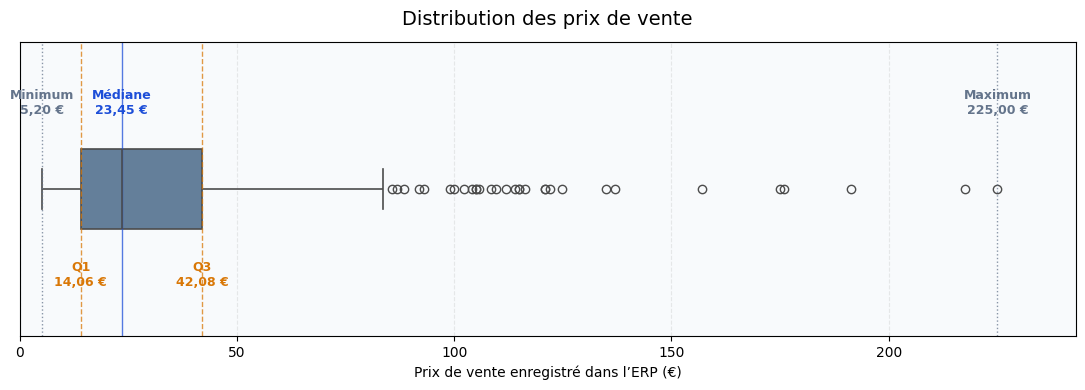

In [48]:
# Statistiques utilisées dans la visualisation
prix_minimum = serie_prix.min()
q1_prix = serie_prix.quantile(0.25)
mediane_prix = serie_prix.median()
q3_prix = serie_prix.quantile(0.75)
prix_maximum = serie_prix.max()

def format_euro(valeur):
    return f"{valeur:.2f} €".replace(".", ",")

# Création du graphique
fig, ax = plt.subplots(figsize=(11, 4))

sns.boxplot(
    x=serie_prix,
    color="#5B7FA3",
    width=0.30,
    linewidth=1.2,
    ax=ax)

ax.set_facecolor("#F8FAFC")
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_yticks([])

# Repères et étiquettes
reperes_prix = [
    (prix_minimum, "Minimum", 0.32, "#64748B", ":"),
    (q1_prix, "Q1", -0.32, "#D97706", "--"),
    (mediane_prix, "Médiane", 0.32, "#1D4ED8", "-"),
    (q3_prix, "Q3", -0.32, "#D97706", "--"),
    (prix_maximum, "Maximum", 0.32, "#64748B", ":")]

for valeur, libelle, position_y, couleur, style in reperes_prix:
    ax.axvline(
        valeur,
        color=couleur,
        linestyle=style,
        linewidth=1,
        alpha=0.75)
    
    ax.text(
        valeur,
        position_y,
        f"{libelle}\n{format_euro(valeur)}",
        ha="center",
        va="center",
        fontsize=9,
        color=couleur,
        fontweight="bold")

ax.set_xlim(0, prix_maximum * 1.08)
ax.set_ylim(-0.55, 0.55)
ax.set_title("Distribution des prix de vente", fontsize=14, pad=12)
ax.set_xlabel("Prix de vente enregistré dans l’ERP (€)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

La distribution des prix est asymétrique vers les valeurs élevées. La moitié des produits présente un prix compris entre **14,06 €** et **42,08 €**, avec une médiane de **23,45 €**.

Plusieurs prix élevés apparaissent au-delà de la moustache supérieure. Ils sont statistiquement atypiques, mais ne peuvent pas être considérés comme des erreurs sans vérification des produits concernés.

### 4.2 – Détection statistique des prix atypiques

#### 4.2.1 – Méthode de l’écart interquartile — option 1

La méthode de l’écart interquartile, ou IQR, identifie comme atypiques les valeurs situées en dehors de l’intervalle :

- borne inférieure : `Q1 − 1,5 × IQR` ;
- borne supérieure : `Q3 + 1,5 × IQR`.

Cette méthode est robuste aux distributions asymétriques et peu influencée par les valeurs extrêmes.

In [49]:
# Calcul des limites IQR
q1_prix = serie_prix.quantile(0.25)
q3_prix = serie_prix.quantile(0.75)
iqr_prix = q3_prix - q1_prix

borne_inferieure_iqr = q1_prix - 1.5 * iqr_prix
borne_superieure_iqr = q3_prix + 1.5 * iqr_prix

resume_methode_iqr = pd.DataFrame({
    "valeur": [
        q1_prix,
        q3_prix,
        iqr_prix,
        borne_inferieure_iqr,
        borne_superieure_iqr]}, 
    index=[
    "Q1",
    "Q3",
    "IQR",
    "borne_inferieure",
    "borne_superieure"]).round(2)

display(resume_methode_iqr)

# Extraction des produits détectés par l’IQR
masque_outliers_iqr = (
    (df_final["price_analysis"] < borne_inferieure_iqr) | (df_final["price_analysis"] > borne_superieure_iqr))

outliers_prix_iqr = df_final.loc[
    masque_outliers_iqr,
    [   "product_id",
        "sku_analysis",
        "post_title",
        "product_type_analysis",
        "price_analysis"]].copy()

outliers_prix_iqr["ecart_borne_superieure"] = (outliers_prix_iqr["price_analysis"] - borne_superieure_iqr)

outliers_prix_iqr = outliers_prix_iqr.sort_values("price_analysis", ascending=False).reset_index(drop=True)

print("Nombre de prix détectés par l’IQR :", len(outliers_prix_iqr))
display(outliers_prix_iqr)

,valeur
Q1,14.06
Q3,42.08
IQR,28.01
borne_inferieure,-27.96
borne_superieure,84.09


Nombre de prix détectés par l’IQR : 31


,product_id,sku_analysis,post_title,product_type_analysis,price_analysis,ecart_borne_superieure
0,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Champagne,225.0,140.90625
1,5001,14581,David Duband Charmes-Chambertin Grand Cru 2014,Vin,217.5,133.40625
2,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Champagne,191.3,107.20625
3,4402,3510,Cognac Frapin VIP XO,Cognac,176.0,91.90625
4,5767,15185,Camille Giroud Clos de Vougeot 2016,Vin,175.0,90.90625
5,4406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans...,Cognac,157.0,72.90625
6,4904,14220,Domaine Des Croix Corton Charlemagne Grand Cru...,Vin,137.0,52.90625
7,6126,14923,Champagne Gosset Célébris Vintage 2007,Champagne,135.0,50.90625
8,5612,14915,Domaine Weinbach Gewurztraminer Grand Cru Furs...,Vin,124.8,40.70625
9,5917,14775,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,Whisky,122.0,37.90625


##### Résultat de la méthode IQR

Le premier quartile est de **14,06 €** et le troisième quartile de **42,08 €**, soit un écart interquartile de **28,01 €**.

La borne inférieure calculée est négative (**−27,96 €**). Aucun prix ne se situe sous cette limite, ce qui est cohérent avec l’absence de prix négatifs dans la base analytique finale.

La borne supérieure est de **84,09 €**. La méthode IQR identifie **31 produits** dont le prix dépasse cette limite.

Ces produits sont considérés comme statistiquement atypiques, mais pas nécessairement comme erronés. Dans le contexte de BottleNeck, certains peuvent correspondre à des vins premium, rares ou anciens. Une vérification des références concernées reste donc nécessaire avant toute correction.

#### 4.2.2 – Méthode du Z-score — option 2

Le Z-score mesure l’écart entre chaque prix et la moyenne, exprimé en nombre d’écarts-types.

Un prix est considéré comme atypique lorsque la valeur absolue de son Z-score est supérieure à 3.

Cette méthode est simple et reproductible, mais elle est sensible aux valeurs extrêmes et suppose une distribution relativement proche d’une distribution normale. Cette hypothèse doit être considérée avec prudence, car la distribution des prix est asymétrique.

In [50]:
# Paramètres du Z-score
moyenne_prix = serie_prix.mean()
ecart_type_prix = serie_prix.std(ddof=0)
seuil_zscore = 3

borne_inferieure_zscore = moyenne_prix - seuil_zscore * ecart_type_prix
borne_superieure_zscore = moyenne_prix + seuil_zscore * ecart_type_prix

# Calcul du Z-score pour chaque produit
df_final["z_score_prix"] = ((df_final["price_analysis"] - moyenne_prix) / ecart_type_prix)

resume_methode_zscore = pd.DataFrame({
    "valeur": [
        moyenne_prix,
        ecart_type_prix,
        seuil_zscore,
        borne_inferieure_zscore,
        borne_superieure_zscore]}, 
    index=[
    "moyenne",
    "ecart_type",
    "seuil_zscore",
    "borne_inferieure",
    "borne_superieure"]).round(2)

display(resume_methode_zscore)

# Extraction des produits détectés par le Z-score
masque_outliers_zscore = df_final["z_score_prix"].abs() > seuil_zscore

outliers_prix_zscore = df_final.loc[masque_outliers_zscore,
    [   "product_id",
        "sku_analysis",
        "post_title",
        "product_type_analysis",
        "price_analysis",
        "z_score_prix"]].copy()

outliers_prix_zscore = outliers_prix_zscore.sort_values("price_analysis", ascending=False).reset_index(drop=True)

print("Nombre de prix détectés par le Z-score :", len(outliers_prix_zscore))
display(outliers_prix_zscore)

,valeur
moyenne,32.33
ecart_type,27.58
seuil_zscore,3.00
borne_inferieure,-50.40
borne_superieure,115.06


Nombre de prix détectés par le Z-score : 13


,product_id,sku_analysis,post_title,product_type_analysis,price_analysis,z_score_prix
0,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Champagne,225.0,6.986486
1,5001,14581,David Duband Charmes-Chambertin Grand Cru 2014,Vin,217.5,6.714520
2,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Champagne,191.3,5.764453
3,4402,3510,Cognac Frapin VIP XO,Cognac,176.0,5.209643
4,5767,15185,Camille Giroud Clos de Vougeot 2016,Vin,175.0,5.173380
5,4406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans...,Cognac,157.0,4.520663
6,4904,14220,Domaine Des Croix Corton Charlemagne Grand Cru...,Vin,137.0,3.795421
7,6126,14923,Champagne Gosset Célébris Vintage 2007,Champagne,135.0,3.722896
8,5612,14915,Domaine Weinbach Gewurztraminer Grand Cru Furs...,Vin,124.8,3.353023
9,5917,14775,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,Whisky,122.0,3.251489


##### Résultat de la méthode du Z-score

La moyenne des prix est de **32,33 €** et l’écart-type de **27,58 €**.

Avec un seuil fixé à trois écarts-types, la borne inférieure est de **−50,40 €** et la borne supérieure de **115,06 €**. Aucun prix ne se situe sous la borne inférieure.

Le Z-score identifie **13 produits** dont le prix dépasse la borne supérieure.

Cette méthode détecte moins de produits que l’IQR. La moyenne et l’écart-type étant influencés par les prix très élevés, la limite du Z-score est repoussée vers le haut. Dans une distribution asymétrique comme celle-ci, le Z-score repère principalement les valeurs les plus extrêmes, mais peut ne pas détecter certains prix atypiques identifiés par une méthode plus robuste.

#### 4.2.3 – Comparaison des méthodes de détection

Les résultats de l’IQR et du Z-score sont comparés afin d’identifier :

- les produits détectés par les deux méthodes ;
- les produits détectés uniquement par l’IQR ;
- les éventuels produits détectés uniquement par le Z-score ;
- les produits non considérés comme atypiques.

Cette comparaison permet d’évaluer la sensibilité des méthodes avant de sélectionner l’approche la plus adaptée au contexte métier.

In [51]:
colonnes_comparaison_prix = [
    "product_id",
    "sku_analysis",
    "post_title",
    "product_type_analysis",
    "price_analysis",
    "z_score_prix"]

comparaison_detection_prix = df_final[colonnes_comparaison_prix].copy()

comparaison_detection_prix["detecte_iqr"] = masque_outliers_iqr
comparaison_detection_prix["detecte_zscore"] = masque_outliers_zscore

comparaison_detection_prix["resultat_detection"] = np.select(
    [   comparaison_detection_prix["detecte_iqr"] &
        comparaison_detection_prix["detecte_zscore"],

        comparaison_detection_prix["detecte_iqr"] &
        ~comparaison_detection_prix["detecte_zscore"],

        ~comparaison_detection_prix["detecte_iqr"] &
        comparaison_detection_prix["detecte_zscore"]],

    [   "IQR et Z-score",
        "IQR uniquement",
        "Z-score uniquement"], default="Non détecté")

ordre_detection = [
    "IQR et Z-score",
    "IQR uniquement",
    "Z-score uniquement",
    "Non détecté"]

resume_comparaison_detection = (
    comparaison_detection_prix["resultat_detection"]
    .value_counts()
    .reindex(ordre_detection, fill_value=0)
    .rename_axis("resultat_detection")
    .reset_index(name="nombre_produits"))

display(resume_comparaison_detection)

produits_atypiques_comparaison = comparaison_detection_prix[
    comparaison_detection_prix["resultat_detection"] != "Non détecté"].sort_values("price_analysis", ascending=False).reset_index(drop=True)

display(produits_atypiques_comparaison)

,resultat_detection,nombre_produits
0,IQR et Z-score,13
1,IQR uniquement,18
2,Z-score uniquement,0
3,Non détecté,683


,product_id,sku_analysis,post_title,product_type_analysis,price_analysis,z_score_prix,detecte_iqr,detecte_zscore,resultat_detection
0,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Champagne,225.0,6.986486,True,True,IQR et Z-score
1,5001,14581,David Duband Charmes-Chambertin Grand Cru 2014,Vin,217.5,6.714520,True,True,IQR et Z-score
2,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Champagne,191.3,5.764453,True,True,IQR et Z-score
3,4402,3510,Cognac Frapin VIP XO,Cognac,176.0,5.209643,True,True,IQR et Z-score
4,5767,15185,Camille Giroud Clos de Vougeot 2016,Vin,175.0,5.173380,True,True,IQR et Z-score
5,4406,7819,Cognac Frapin Château de Fontpinot 1989 20 Ans...,Cognac,157.0,4.520663,True,True,IQR et Z-score
6,4904,14220,Domaine Des Croix Corton Charlemagne Grand Cru...,Vin,137.0,3.795421,True,True,IQR et Z-score
7,6126,14923,Champagne Gosset Célébris Vintage 2007,Champagne,135.0,3.722896,True,True,IQR et Z-score
8,5612,14915,Domaine Weinbach Gewurztraminer Grand Cru Furs...,Vin,124.8,3.353023,True,True,IQR et Z-score
9,5917,14775,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,Whisky,122.0,3.251489,True,True,IQR et Z-score


##### Évaluation comparative des méthodes

In [52]:
comparaison_methodes_prix = pd.DataFrame([
    {   "critere": "Qualité et adaptation",
        "IQR": "Adapté aux distributions asymétriques.",
        "Z-score": "Plus adapté à une distribution proche de la normale.",
        "evaluation": "Avantage IQR pour la distribution des prix." },

    {   "critere": "Robustesse et biais",
        "IQR": "Peu influencé par les valeurs extrêmes, mais peut signaler des produits premium.",
        "Z-score": "La moyenne et l’écart-type sont influencés par les prix élevés.",
        "evaluation": "Le Z-score présente un risque de sous-détection."},

    {   "critere": "Résultat observé",
        "IQR": f"{len(outliers_prix_iqr)} produits détectés.",
        "Z-score": f"{len(outliers_prix_zscore)} produits détectés.",
        "evaluation": "Les 13 produits du Z-score appartiennent également au groupe IQR."},

    {   "critere": "Temps de calcul",
        "IQR": "Très faible sur 714 observations.",
        "Z-score": "Très faible sur 714 observations.",
        "evaluation": "Différence non significative."},

    {   "critere": "Reproductibilité",
        "IQR": "Règle déterministe fondée sur Q1, Q3 et le coefficient 1,5.",
        "Z-score": "Règle déterministe fondée sur la moyenne, l’écart-type et le seuil 3.",
        "evaluation": "Les deux méthodes sont reproductibles."},

    {   "critere": "Maintenabilité",
        "IQR": "Calcul simple avec les fonctions quantile de Pandas.",
        "Z-score": "Calcul simple à partir de la moyenne et de l’écart-type.",
        "evaluation": "Les deux méthodes sont faciles à maintenir."},

    {   "critere": "Sécurité et conformité",
        "IQR": "Calcul local, sans transmission de données.",
        "Z-score": "Calcul local, sans transmission de données.",
        "evaluation": "Niveau de sécurité et de conformité équivalent."},

    {   "critere": "Sobriété",
        "IQR": "Coût de calcul négligeable.",
        "Z-score": "Coût de calcul négligeable.",
        "evaluation": "Impact environnemental comparable et limité."}])

with pd.option_context("display.max_colwidth", None):
    display(
        comparaison_methodes_prix.style
        .set_properties(
            subset=["IQR", "Z-score", "evaluation"],
            **{
                "min-width": "260px",
                "max-width": "380px",
                "white-space": "normal",
                "text-align": "left"}).set_properties(subset=["critere"], **{"font-weight": "bold", "text-align": "left"}).hide(axis="index"))

critere,IQR,Z-score,evaluation
Qualité et adaptation,Adapté aux distributions asymétriques.,Plus adapté à une distribution proche de la normale.,Avantage IQR pour la distribution des prix.
Robustesse et biais,"Peu influencé par les valeurs extrêmes, mais peut signaler des produits premium.",La moyenne et l’écart-type sont influencés par les prix élevés.,Le Z-score présente un risque de sous-détection.
Résultat observé,31 produits détectés.,13 produits détectés.,Les 13 produits du Z-score appartiennent également au groupe IQR.
Temps de calcul,Très faible sur 714 observations.,Très faible sur 714 observations.,Différence non significative.
Reproductibilité,"Règle déterministe fondée sur Q1, Q3 et le coefficient 1,5.","Règle déterministe fondée sur la moyenne, l’écart-type et le seuil 3.",Les deux méthodes sont reproductibles.
Maintenabilité,Calcul simple avec les fonctions quantile de Pandas.,Calcul simple à partir de la moyenne et de l’écart-type.,Les deux méthodes sont faciles à maintenir.
Sécurité et conformité,"Calcul local, sans transmission de données.","Calcul local, sans transmission de données.",Niveau de sécurité et de conformité équivalent.
Sobriété,Coût de calcul négligeable.,Coût de calcul négligeable.,Impact environnemental comparable et limité.


##### Décision méthodologique

La méthode **IQR est retenue comme méthode principale** de détection des prix atypiques. Elle est plus adaptée à la distribution asymétrique observée et reste peu influencée par les valeurs extrêmes.

Le **Z-score est conservé comme méthode complémentaire**. Les 13 produits détectés par les deux méthodes constituent les valeurs les plus extrêmes, tandis que les 18 produits détectés uniquement par l’IQR forment un second niveau de vérification.

Aucun prix n’est corrigé ou supprimé automatiquement. Les 31 références détectées par l’IQR sont transmises pour validation métier, car un prix élevé peut être cohérent avec un vin premium, rare ou ancien.

Cette décision repose sur des critères explicites de qualité, de robustesse, de temps, de reproductibilité, de maintenabilité, de sécurité, de conformité et de sobriété.

## 5 – Analyse du chiffre d’affaires, des ventes, des stocks et de la rentabilité

Cette étape analyse les performances commerciales et opérationnelles de BottleNeck à partir des ventes réalisées du **1er au 31 octobre** et de l’état des stocks extrait au **31 octobre**.

Les calculs utilisent uniquement les variables analytiques validées afin de préserver la fiabilité et la traçabilité des résultats.

### 5.1 – Calcul du chiffre d’affaires

Le chiffre d’affaires calculé par produit correspond à :

`prix de vente × quantité vendue`

Deux indicateurs sont distingués :

- le **chiffre d’affaires TTC calculé**, fondé sur le prix enregistré dans l’ERP ;
- le **chiffre d’affaires HT estimé**, fondé sur l’hypothèse d’un taux de TVA de 20 %.

Le chiffre d’affaires HT reste une estimation tant que le taux de TVA applicable à chaque type de produit, notamment aux bons cadeaux, n’a pas été validé par les équipes métier.

In [53]:
# Calcul du chiffre d’affaires par produit
df_final["ca_ttc_calcule"] = (df_final["price_analysis"] * df_final["total_sales_analysis"])

df_final["ca_ht_estime"] = (df_final["price_ht_analysis"] * df_final["total_sales_analysis"])

# Indicateurs globaux
nombre_produits = len(df_final)
produits_avec_ventes = (df_final["total_sales_analysis"] > 0).sum()
produits_sans_vente = (df_final["total_sales_analysis"] == 0).sum()
quantite_totale_vendue = df_final["total_sales_analysis"].sum()
ca_total_ttc = df_final["ca_ttc_calcule"].sum()
ca_total_ht_estime = df_final["ca_ht_estime"].sum()

resume_chiffre_affaires = pd.DataFrame([
    {  "indicateur": "Produits dans la base analytique",
        "valeur": f"{nombre_produits}",
        "unite": "produits"},

    {  "indicateur": "Produits avec ventes",
        "valeur": f"{produits_avec_ventes}",
        "unite": "produits"},

    {   "indicateur": "Produits sans vente",
        "valeur": f"{produits_sans_vente}",
        "unite": "produits"},

    {   "indicateur": "Quantité totale vendue",
        "valeur": f"{quantite_totale_vendue:,.0f}",
        "unite": "unités"},

    {   "indicateur": "Chiffre d’affaires TTC calculé",
        "valeur": f"{ca_total_ttc:,.2f}",
        "unite": "€"},
        
    {   "indicateur": "Chiffre d’affaires HT estimé",
        "valeur": f"{ca_total_ht_estime:,.2f}",
        "unite": "€"}])

display(resume_chiffre_affaires)

,indicateur,valeur,unite
0,Produits dans la base analytique,714,produits
1,Produits avec ventes,689,produits
2,Produits sans vente,25,produits
3,Quantité totale vendue,"5,751",unités
4,Chiffre d’affaires TTC calculé,"143,680.10",€
5,Chiffre d’affaires HT estimé,"119,733.42",€


#### 5.1.1 – Chiffre d’affaires par produit et principales références

Le chiffre d’affaires par produit permet d’identifier les références contribuant le plus aux ventes du mois d’octobre.

Le classement est réalisé par `product_id`, afin de ne pas regrouper par erreur des produits différents possédant un intitulé identique.

In [54]:
# Création d’un intitulé destiné à l’affichage
df_final["post_title_display"] = (
    df_final["post_title"]
    .str.replace("&amp;", "&", regex=False))

# Classement des produits par chiffre d’affaires
classement_ca_produits = df_final[
    [   "product_id",
        "sku_analysis",
        "post_title_display",
        "price_analysis",
        "total_sales_analysis",
        "ca_ttc_calcule"]].copy()

classement_ca_produits["part_ca_total"] = (classement_ca_produits["ca_ttc_calcule"] / ca_total_ttc)

classement_ca_produits = classement_ca_produits.sort_values("ca_ttc_calcule", ascending=False).reset_index(drop=True)

classement_ca_produits.insert(0,"rang", range(1, len(classement_ca_produits) + 1))

top_10_ca = classement_ca_produits.head(10).copy()

with pd.option_context("display.max_colwidth", None):
    display(
        top_10_ca.style
        .format({
            "price_analysis": "{:.2f} €",
            "total_sales_analysis": "{:.0f}",
            "ca_ttc_calcule": "{:.2f} €",
            "part_ca_total": "{:.2%}"}).hide(axis="index"))

print("Part du chiffre d’affaires réalisée par le top 10 :", f"{top_10_ca['part_ca_total'].sum():.2%}")

rang,product_id,sku_analysis,post_title_display,price_analysis,total_sales_analysis,ca_ttc_calcule,part_ca_total
1,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.00 €,11,2475.00 €,1.72%
2,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,191.30 €,6,1147.80 €,0.80%
3,4353,12587,Champagne Egly-Ouriet Grand Cru Brut Rosé,79.50 €,14,1113.00 €,0.77%
4,5826,15325,Agnès Levet Côte Rôtie Améthyste 2017,41.20 €,20,824.00 €,0.57%
5,6212,13996,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2015,115.00 €,7,805.00 €,0.56%
6,5026,13913,Champagne Agrapart & Fils Minéral Extra Brut Blanc de Blancs Grand Cru 2012,86.80 €,9,781.20 €,0.54%
7,5008,11602,Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2013,105.00 €,7,735.00 €,0.51%
8,5767,15185,Camille Giroud Clos de Vougeot 2016,175.00 €,4,700.00 €,0.49%
9,6126,14923,Champagne Gosset Célébris Vintage 2007,135.00 €,5,675.00 €,0.47%
10,5025,13914,Champagne Agrapart & Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,112.00 €,6,672.00 €,0.47%


Part du chiffre d’affaires réalisée par le top 10 : 6.91%


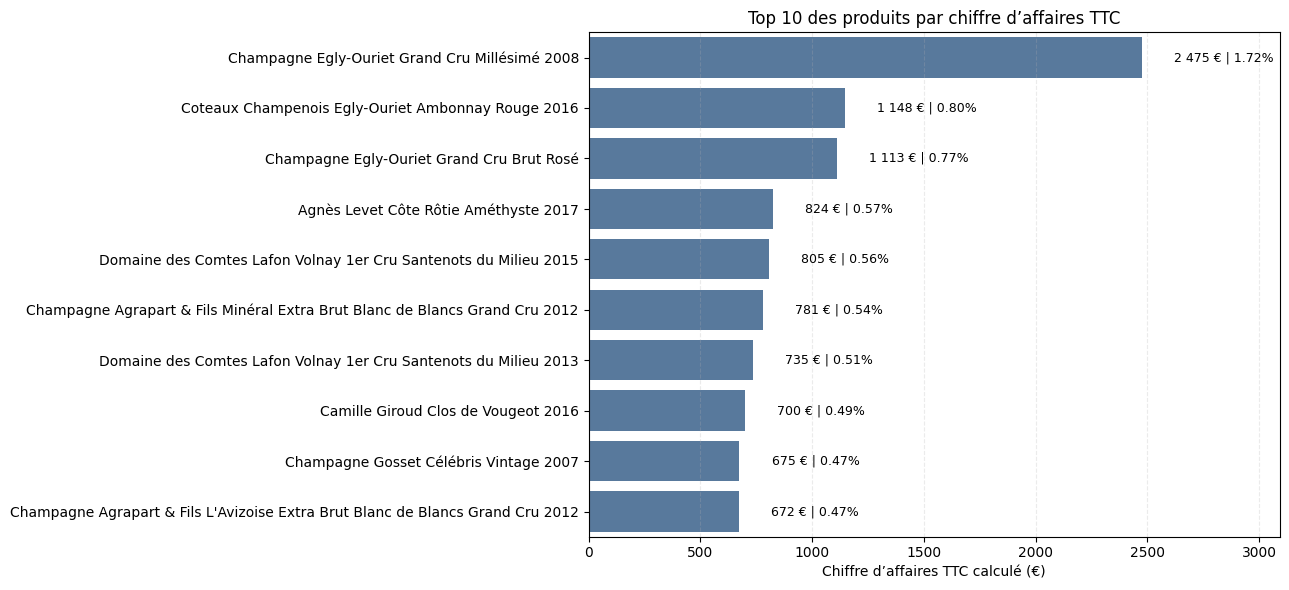

In [55]:
top_10_ca_plot = top_10_ca.sort_values("ca_ttc_calcule", ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))

sns.barplot(
    data=top_10_ca_plot,
    x="ca_ttc_calcule",
    y="post_title_display",
    color="#4C78A8",
    ax=ax)

for position, (_, ligne) in enumerate(top_10_ca_plot.iterrows()):
    valeur_ca = ligne["ca_ttc_calcule"]
    part_ca = ligne["part_ca_total"]

    libelle = (f"{valeur_ca:,.0f} €" f" | {part_ca:.2%}").replace(",", " ")

    ax.text(
        valeur_ca + ca_total_ttc * 0.001,
        position,
        libelle,
        va="center",
        fontsize=9)

ax.set_xlim(0, top_10_ca_plot["ca_ttc_calcule"].max() * 1.25)
ax.set_title("Top 10 des produits par chiffre d’affaires TTC")
ax.set_xlabel("Chiffre d’affaires TTC calculé (€)")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

Le Champagne Egly-Ouriet Grand Cru Millésimé 2008 occupe la première position avec un chiffre d’affaires TTC de **2 475 €**, soit **1,72 %** du total.

Les dix principales références représentent seulement **6,91 % du chiffre d’affaires total**. Le chiffre d’affaires paraît donc réparti sur un nombre important de produits, sans dépendance excessive à une seule référence.

#### 5.1.2 – Analyse de Pareto du chiffre d’affaires

Les produits sont classés par chiffre d’affaires décroissant. La part cumulée du chiffre d’affaires est ensuite comparée à la part cumulée du catalogue.

Le calcul est réalisé par `product_id`, avec un tri complémentaire par identifiant en cas d’égalité, afin de garantir un résultat reproductible.

In [56]:
pareto_ca = df_final[["product_id", "post_title_display", "ca_ttc_calcule"]].copy()

pareto_ca = pareto_ca.sort_values(["ca_ttc_calcule", "product_id"], ascending=[False, True], kind="mergesort").reset_index(drop=True)

pareto_ca["rang"] = range(1, len(pareto_ca) + 1)
pareto_ca["ca_cumule"] = pareto_ca["ca_ttc_calcule"].cumsum()
pareto_ca["part_ca_cumulee"] = pareto_ca["ca_cumule"] / ca_total_ttc
pareto_ca["part_catalogue_cumulee"] = pareto_ca["rang"] / len(pareto_ca)

# Nombre de produits nécessaires pour atteindre au moins 80 % du CA
nombre_produits_80_ca = int(np.searchsorted(pareto_ca["part_ca_cumulee"].to_numpy(), 0.80, side="left") + 1)

part_catalogue_80_ca = nombre_produits_80_ca / len(pareto_ca)
part_ca_atteinte = pareto_ca.loc[nombre_produits_80_ca - 1, "part_ca_cumulee"]

# Part du CA réalisée par les 20 % premiers produits
nombre_produits_top_20 = int(np.ceil(len(pareto_ca) * 0.20))
part_ca_top_20 = pareto_ca.loc[nombre_produits_top_20 - 1,"part_ca_cumulee"]

resume_pareto_ca = pd.DataFrame([
    {  "indicateur": "Produits nécessaires pour atteindre 80 % du CA",
        "nombre_produits": nombre_produits_80_ca,
        "part_catalogue": f"{part_catalogue_80_ca:.2%}",
        "part_ca": f"{part_ca_atteinte:.2%}"},

    {   "indicateur": "Contribution des 20 % premiers produits",
        "nombre_produits": nombre_produits_top_20,
        "part_catalogue": f"{nombre_produits_top_20 / len(pareto_ca):.2%}",
        "part_ca": f"{part_ca_top_20:.2%}"}])

display(resume_pareto_ca)

,indicateur,nombre_produits,part_catalogue,part_ca
0,Produits nécessaires pour atteindre 80 % du CA,435,60.92%,80.09%
1,Contribution des 20 % premiers produits,143,20.03%,40.24%


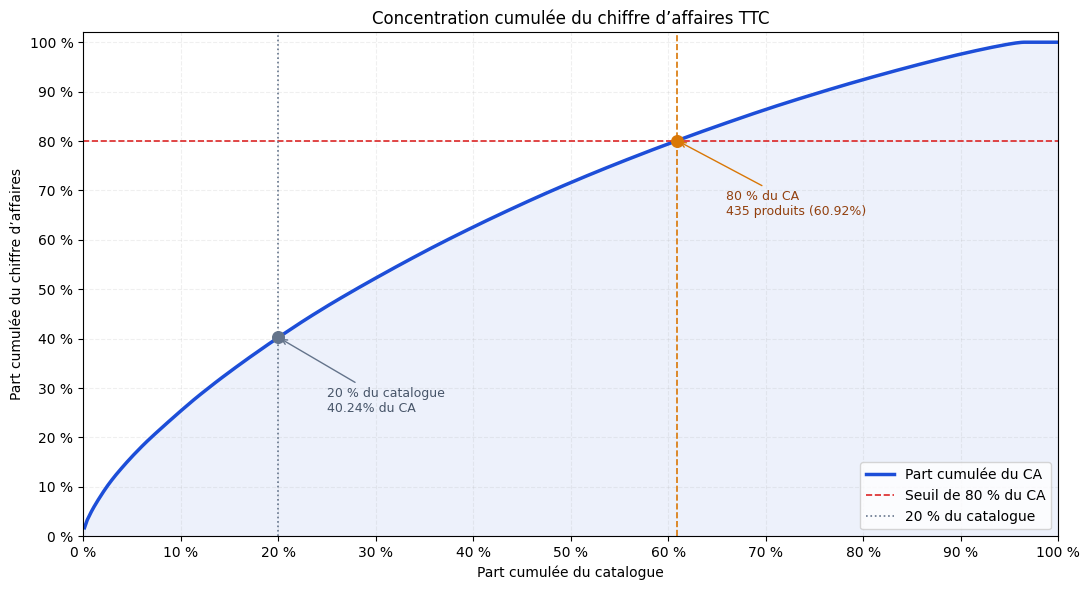

In [57]:
part_catalogue_top_20 = (nombre_produits_top_20 / len(pareto_ca))

x_pareto = pareto_ca["part_catalogue_cumulee"] * 100
y_pareto = pareto_ca["part_ca_cumulee"] * 100

x_seuil_80 = part_catalogue_80_ca * 100
y_seuil_80 = part_ca_atteinte * 100

x_top_20 = part_catalogue_top_20 * 100
y_top_20 = part_ca_top_20 * 100

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    x_pareto,
    y_pareto,
    color="#1D4ED8",
    linewidth=2.5,
    label="Part cumulée du CA")

ax.fill_between(
    x_pareto,
    y_pareto,
    color="#1D4ED8",
    alpha=0.08)

# Seuil de 80 % du chiffre d’affaires
ax.axhline(
    80,
    color="#DC2626",
    linestyle="--",
    linewidth=1.2,
    label="Seuil de 80 % du CA")

ax.axvline(
    x_seuil_80,
    color="#D97706",
    linestyle="--",
    linewidth=1.2)

ax.scatter(
    x_seuil_80,
    y_seuil_80,
    color="#D97706",
    s=70,
    zorder=3)

# Repère des 20 % premiers produits
ax.axvline(
    x_top_20,
    color="#64748B",
    linestyle=":",
    linewidth=1.2,
    label="20 % du catalogue")

ax.scatter(
    x_top_20,
    y_top_20,
    color="#64748B",
    s=70,
    zorder=3)

# Étiquettes
ax.annotate(
    (   f"80 % du CA\n"
        f"{nombre_produits_80_ca} produits "
        f"({part_catalogue_80_ca:.2%})"),

    xy=(x_seuil_80, y_seuil_80),
    xytext=(x_seuil_80 + 5, y_seuil_80 - 15),
    arrowprops={"arrowstyle": "->", "color": "#D97706"},
    fontsize=9,
    color="#92400E")

ax.annotate(
    (   f"20 % du catalogue\n"
        f"{part_ca_top_20:.2%} du CA"),

    xy=(x_top_20, y_top_20),
    xytext=(x_top_20 + 5, y_top_20 - 15),
    arrowprops={"arrowstyle": "->", "color": "#64748B"},
    fontsize=9,
    color="#475569")

graduations = range(0, 101, 10)

ax.set_xticks(graduations)
ax.set_xticklabels([f"{valeur} %" for valeur in graduations])
ax.set_yticks(graduations)
ax.set_yticklabels([f"{valeur} %" for valeur in graduations])

ax.set_xlim(0, 100)
ax.set_ylim(0, 102)
ax.set_title("Concentration cumulée du chiffre d’affaires TTC")
ax.set_xlabel("Part cumulée du catalogue")
ax.set_ylabel("Part cumulée du chiffre d’affaires")
ax.grid(linestyle="--", alpha=0.20)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

##### Interprétation de l’analyse de Pareto

La règle classique des 80/20 n’est pas observée.

Les **20 % premiers produits** représentent seulement **40,24 % du chiffre d’affaires**, bien en dessous des 80 % attendus dans une concentration de type Pareto.

Pour atteindre au moins 80 % du chiffre d’affaires, BottleNeck doit prendre en compte **435 produits**, soit **60,92 % du catalogue analytique**.

Le chiffre d’affaires est donc relativement dispersé entre les références. Une stratégie commerciale ou de gestion des stocks ne peut pas se concentrer uniquement sur un petit nombre de produits, même si les principales références restent pertinentes pour définir un premier niveau de suivi.

Le plateau observé en fin de courbe s’explique par la présence de **25 produits sans vente**, qui augmentent la part cumulée du catalogue sans modifier le chiffre d’affaires cumulé.

### 5.2 – Analyse des quantités vendues

Cette section analyse les volumes vendus indépendamment du prix des produits.

Elle permet d’identifier les références les plus fréquemment vendues et de vérifier si les volumes sont concentrés sur une faible partie du catalogue.

rang,product_id,sku_analysis,post_title_display,price_analysis,total_sales_analysis,part_quantites_totales
1,4867,16148,Château De La Selve IGP Coteaux de l'Ardèche Maguelonne Rosé 2019,9.90 €,36,0.63%
2,4203,15415,Mas Laval IGP Pays d'Hérault Les Pampres Blancs 2018,9.90 €,27,0.47%
3,4275,14864,I Fabbri Chianti Classico Lamole 2017,14.90 €,24,0.42%
4,4647,16525,Bernard Baudry Chinon Rouge La Croix Boissée 2017,28.50 €,22,0.38%
5,4726,14950,François Baur Pinot Noir Schlittweg 2017,12.70 €,22,0.38%
6,5826,15325,Agnès Levet Côte Rôtie Améthyste 2017,41.20 €,20,0.35%
7,6129,14570,Moulin de Gassac IGP Pays d'Hérault Guilhem Blanc 2017,5.20 €,20,0.35%
8,4220,15758,Xavier Frissant Touraine Amboise Chenin Les Pierres 2018,11.60 €,18,0.31%
9,5778,15561,Maurel Pays d'Oc Merlot 2018,5.80 €,17,0.30%
10,5803,13572,Château Tour Haut-Caussan Médoc 2015,17.10 €,17,0.30%


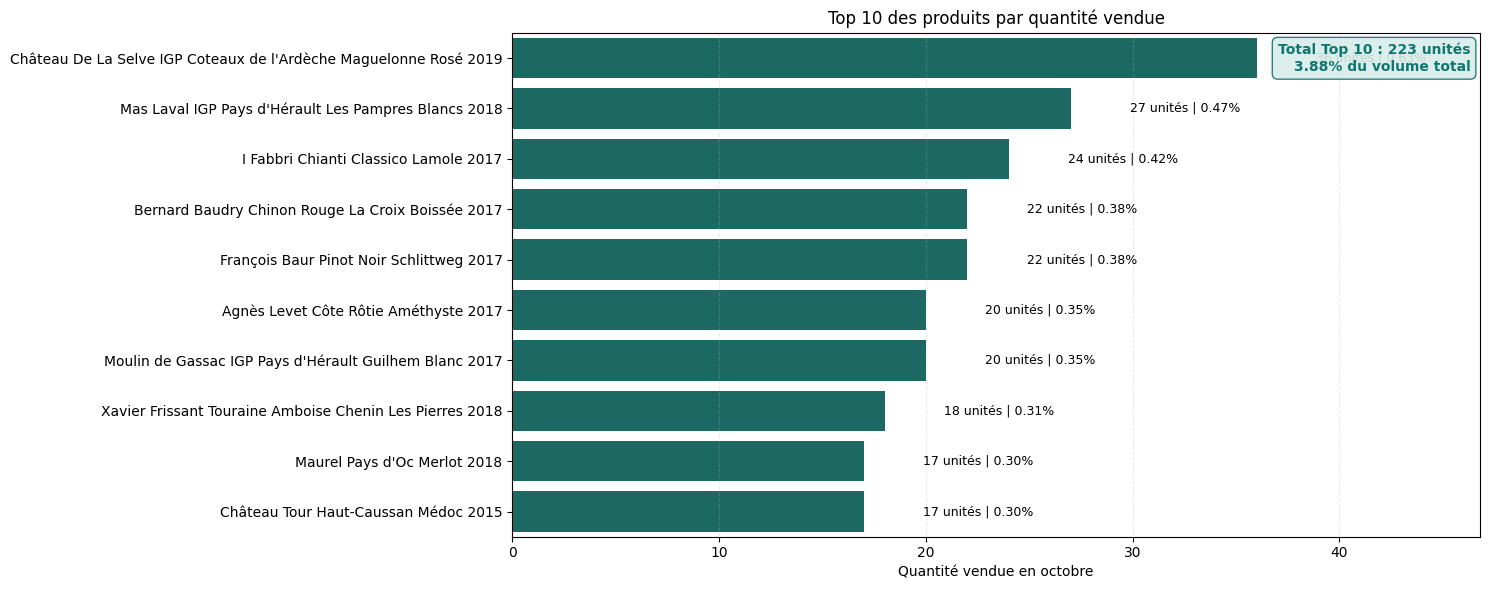

In [58]:
# Classement des produits par quantité vendue
colonnes_quantites = ["product_id", "sku_analysis", "post_title_display", "price_analysis", "total_sales_analysis"]
classement_quantites = df_final[colonnes_quantites].copy()
classement_quantites["part_quantites_totales"] = classement_quantites["total_sales_analysis"] / quantite_totale_vendue
classement_quantites = classement_quantites.sort_values(
    ["total_sales_analysis", "product_id"], ascending=[False, True], kind="mergesort").reset_index(drop=True)
classement_quantites.insert(0, "rang", range(1, len(classement_quantites) + 1))

# Top 10 et total
top_10_quantites = classement_quantites.head(10).copy()
total_top_10_quantites = top_10_quantites["total_sales_analysis"].sum()
part_top_10_quantites = top_10_quantites["part_quantites_totales"].sum()

top_10_affichage = top_10_quantites.copy()
top_10_affichage.loc[len(top_10_affichage)] = {
    "rang": "",
    "product_id": "",
    "sku_analysis": "",
    "post_title_display": "TOTAL TOP 10",
    "price_analysis": np.nan,
    "total_sales_analysis": total_top_10_quantites,
    "part_quantites_totales": part_top_10_quantites}

style_top_10 = (
    top_10_affichage.style
    .format({
        "price_analysis": "{:.2f} €",
        "total_sales_analysis": "{:.0f}",
        "part_quantites_totales": "{:.2%}"}, na_rep="")
    .apply(
        lambda ligne: ["font-weight: 800; background-color: #A7F3D0; ""color: #064E3B; border-top: 2px solid #0F766E; "
    "font-size: 1.05em;"] * len(ligne)
        if ligne["post_title_display"] == "TOTAL TOP 10" else [""] * len(ligne),
        axis=1).hide(axis="index"))

with pd.option_context("display.max_colwidth", None):
    display(style_top_10)

# Graphique
top_10_plot = top_10_quantites.sort_values("total_sales_analysis", ascending=False)
fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(data=top_10_plot, x="total_sales_analysis", y="post_title_display", color="#0F766E", ax=ax)

for position, (_, ligne) in enumerate(top_10_plot.iterrows()):
    quantite, part = ligne["total_sales_analysis"], ligne["part_quantites_totales"]
    ax.text(quantite + quantite_totale_vendue * 0.0005, position,
            f"{quantite:.0f} unités | {part:.2%}", va="center", fontsize=9)

ax.text(
    0.99, 0.98,
    f"Total Top 10 : {total_top_10_quantites:.0f} unités\n{part_top_10_quantites:.2%} du volume total",
    transform=ax.transAxes, ha="right", va="top", fontsize=10, fontweight="bold", color="#0F766E",
    bbox={"boxstyle": "round,pad=0.4", "facecolor": "#D9EDEA", "edgecolor": "#0F766E", "alpha": 0.90})

ax.set_xlim(0, top_10_plot["total_sales_analysis"].max() * 1.30)
ax.set_title("Top 10 des produits par quantité vendue")
ax.set_xlabel("Quantité vendue en octobre")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()

La référence la plus vendue atteint **36 unités**, soit seulement **0,63 %** du volume total.

Les dix produits les plus vendus représentent ensemble **223 unités**, soit **3,88 % des quantités vendues**. Comme pour le chiffre d’affaires, les volumes sont répartis sur un grand nombre de références.

#### 5.2.1 – Analyse de Pareto des quantités vendues

Les produits sont classés par quantité vendue décroissante afin d’évaluer la concentration des volumes. Le calcul utilise les 714 `product_id` uniques de la base analytique.

,indicateur,nombre_produits,part_catalogue,part_quantites
0,Produits nécessaires pour atteindre 80 % des q...,434,60.78%,80.11%
1,Contribution des 20 % premiers produits,143,20.03%,34.34%


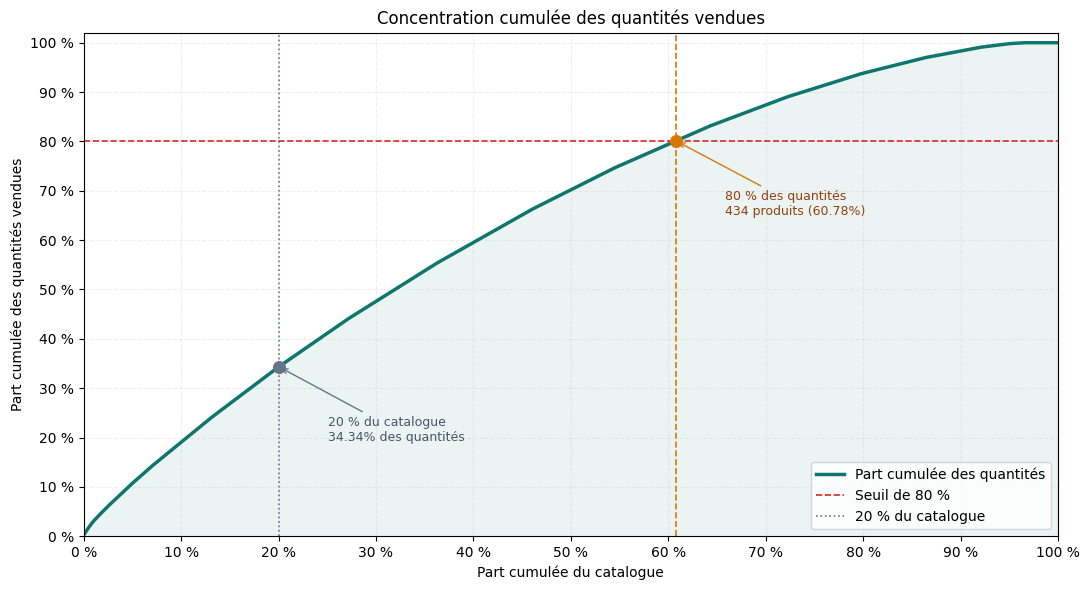

In [59]:
# Calcul du Pareto des quantités
pareto_quantites = classement_quantites[["product_id", "post_title_display", "total_sales_analysis"]
].copy()

pareto_quantites = pareto_quantites.sort_values(
    ["total_sales_analysis", "product_id"], ascending=[False, True], kind="mergesort").reset_index(drop=True)

pareto_quantites["rang"] = range(1, len(pareto_quantites) + 1)
pareto_quantites["quantites_cumulees"] = pareto_quantites["total_sales_analysis"].cumsum()
pareto_quantites["part_quantites_cumulee"] = pareto_quantites["quantites_cumulees"] / quantite_totale_vendue
pareto_quantites["part_catalogue_cumulee"] = pareto_quantites["rang"] / len(pareto_quantites)

# Seuil de 80 % des quantités
nombre_produits_80_quantites = int(np.searchsorted(pareto_quantites["part_quantites_cumulee"].to_numpy(), 0.80, side="left") + 1)

part_catalogue_80_quantites = nombre_produits_80_quantites / len(pareto_quantites)
part_quantites_atteinte = pareto_quantites.loc[nombre_produits_80_quantites - 1, "part_quantites_cumulee"]

# Contribution des 20 % premiers produits
nombre_produits_top_20_quantites = int(np.ceil(len(pareto_quantites) * 0.20))
part_catalogue_top_20_quantites = nombre_produits_top_20_quantites / len(pareto_quantites)
part_quantites_top_20 = pareto_quantites.loc[nombre_produits_top_20_quantites - 1, "part_quantites_cumulee"]

resume_pareto_quantites = pd.DataFrame([
    {   "indicateur": "Produits nécessaires pour atteindre 80 % des quantités",
        "nombre_produits": nombre_produits_80_quantites,
        "part_catalogue": f"{part_catalogue_80_quantites:.2%}",
        "part_quantites": f"{part_quantites_atteinte:.2%}"},

    {   "indicateur": "Contribution des 20 % premiers produits",
        "nombre_produits": nombre_produits_top_20_quantites,
        "part_catalogue": f"{part_catalogue_top_20_quantites:.2%}",
        "part_quantites": f"{part_quantites_top_20:.2%}"}])

display(resume_pareto_quantites)

# Courbe cumulative
x_quantites = pareto_quantites["part_catalogue_cumulee"] * 100
y_quantites = pareto_quantites["part_quantites_cumulee"] * 100
x_80 = part_catalogue_80_quantites * 100
y_80 = part_quantites_atteinte * 100
x_20 = part_catalogue_top_20_quantites * 100
y_20 = part_quantites_top_20 * 100

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x_quantites, y_quantites, color="#0F766E", linewidth=2.5, label="Part cumulée des quantités")
ax.fill_between(x_quantites, y_quantites, color="#0F766E", alpha=0.08)
ax.axhline(80, color="#DC2626", linestyle="--", linewidth=1.2, label="Seuil de 80 %")
ax.axvline(x_80, color="#D97706", linestyle="--", linewidth=1.2)
ax.scatter(x_80, y_80, color="#D97706", s=70, zorder=3)
ax.axvline(x_20, color="#64748B", linestyle=":", linewidth=1.2, label="20 % du catalogue")
ax.scatter(x_20, y_20, color="#64748B", s=70, zorder=3)

ax.annotate(
    f"80 % des quantités\n{nombre_produits_80_quantites} produits ({part_catalogue_80_quantites:.2%})",
    xy=(x_80, y_80), xytext=(x_80 + 5, y_80 - 15),
    arrowprops={"arrowstyle": "->", "color": "#D97706"}, fontsize=9, color="#92400E")

ax.annotate(
    f"20 % du catalogue\n{part_quantites_top_20:.2%} des quantités",
    xy=(x_20, y_20), xytext=(x_20 + 5, y_20 - 15),
    arrowprops={"arrowstyle": "->", "color": "#64748B"}, fontsize=9, color="#475569")

graduations = range(0, 101, 10)
ax.set_xticks(graduations, [f"{v} %" for v in graduations])
ax.set_yticks(graduations, [f"{v} %" for v in graduations])
ax.set_xlim(0, 100)
ax.set_ylim(0, 102)
ax.set_title("Concentration cumulée des quantités vendues")
ax.set_xlabel("Part cumulée du catalogue")
ax.set_ylabel("Part cumulée des quantités vendues")
ax.grid(linestyle="--", alpha=0.20)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

##### Interprétation du Pareto des quantités

La règle des 80/20 n’est pas observée sur les volumes vendus.

Les **20 % premiers produits** représentent seulement **34,34 % des quantités vendues**. Pour atteindre 80 % du volume, il faut considérer **434 produits**, soit **60,78 % du catalogue analytique**.

Les ventes en quantité sont donc encore moins concentrées que le chiffre d’affaires. Le plateau final de la courbe correspond aux 25 produits sans vente.

### 5.3 – Analyse des stocks et de la couverture

Les stocks correspondent à une photographie au **31 octobre**, tandis que les ventes couvrent la période du **1er au 31 octobre**.

La couverture de stock est estimée selon la formule :

`stock au 31 octobre ÷ ventes du mois d’octobre`

Elle représente le nombre de mois de stock disponible si le rythme de vente d’octobre se maintient.

Cette mesure reste une estimation :

- les produits sans vente ont une couverture non calculable, et non égale à zéro ;
- les stocks négatifs sont exclus ;
- le calcul ne constitue pas un taux de rotation comptable standard, car le stock moyen et le coût des ventes de la période ne sont pas disponibles.

In [60]:
# 1. Couverture opérationnelle par produit – périmètre ERP-Web
masque_couverture = df_final["stock_quantity_analysis"].notna() & df_final["total_sales_analysis"].gt(0)
df_final["couverture_stock_mois"] = np.where(
    masque_couverture,
    df_final["stock_quantity_analysis"] / df_final["total_sales_analysis"],
    np.nan)
df_final["valeur_stock_prix_achat"] = (
    df_final["stock_quantity_analysis"] * df_final["purchase_price_analysis"])

synthese_operationnelle = pd.DataFrame({
    "indicateur": [
        "Stock exploitable",
        "Valeur du stock au prix d’achat",
        "Produits avec stock positif",
        "Produits en rupture de stock",
        "Produits vendus mais en rupture",
        "Stocks non exploitables",
        "Couvertures calculables",
        "Couverture physique médiane"],
    "valeur": [
        f'{df_final["stock_quantity_analysis"].sum():,.0f} unités',
        f'{df_final["valeur_stock_prix_achat"].sum():,.2f} €',
        f'{df_final["stock_quantity_analysis"].gt(0).sum()} produits',
        f'{df_final["stock_quantity_analysis"].eq(0).sum()} produits',
        f'{(df_final["stock_quantity_analysis"].eq(0) & df_final["total_sales_analysis"].gt(0)).sum()} produits',
        f'{df_final["stock_quantity_analysis"].isna().sum()} produit',
        f'{masque_couverture.sum()} produits',
        f'{df_final.loc[masque_couverture, "couverture_stock_mois"].median():.2f} mois']})

# 2. DOH financier estimé – ensemble du stock ERP
df_erp["valeur_stock_prix_achat"] = (
    df_erp["stock_quantity_analysis"] * df_erp["purchase_price_analysis"])
df_final["cout_ventes_octobre"] = (
    df_final["purchase_price_analysis"] * df_final["total_sales_analysis"])

valeur_stock_erp = df_erp["valeur_stock_prix_achat"].sum()
cout_ventes_octobre = df_final["cout_ventes_octobre"].sum()
couverture_financiere_mois = valeur_stock_erp / cout_ventes_octobre
doh_financier = couverture_financiere_mois * 30

synthese_financiere = pd.DataFrame({
    "indicateur": [
        "Valeur totale du stock ERP au prix d’achat",
        "Coût des ventes d’octobre",
        "Couverture financière estimée",
        "DOH financier estimé"],
    "valeur": [
        f"{valeur_stock_erp:,.2f} €",
        f"{cout_ventes_octobre:,.2f} €",
        f"{couverture_financiere_mois:.2f} mois",
        f"{doh_financier:.0f} jours"]})

display(synthese_operationnelle)
display(synthese_financiere)

,indicateur,valeur
0,Stock exploitable,"16,740 unités"
1,Valeur du stock au prix d’achat,"277,328.07 €"
2,Produits avec stock positif,669 produits
3,Produits en rupture de stock,44 produits
4,Produits vendus mais en rupture,22 produits
5,Stocks non exploitables,1 produit
6,Couvertures calculables,688 produits
7,Couverture physique médiane,2.40 mois


,indicateur,valeur
0,Valeur totale du stock ERP au prix d’achat,"298,627.66 €"
1,Coût des ventes d’octobre,"75,072.77 €"
2,Couverture financière estimée,3.98 mois
3,DOH financier estimé,119 jours


#### 5.3.1 – Interprétation des indicateurs de stock

Sur le périmètre rapproché ERP–Web, le stock exploitable représente **16 740 unités**, valorisées à **277 328,07 € au prix d’achat**. La couverture physique médiane est estimée à **2,40 mois**.

Parmi les 44 produits sans stock disponible, **22 ont enregistré des ventes en octobre**. Ces références présentent donc un risque potentiel de rupture et nécessitent une vérification des besoins de réapprovisionnement.

Un produit présente une quantité négative. Sa valeur source est conservée pour assurer la traçabilité, mais elle est exclue des calculs analytiques.

À l’échelle de l’ensemble du stock ERP, la valorisation atteint **298 627,66 €**. Rapportée au coût des ventes d’octobre de **75 072,77 €**, elle correspond à une couverture financière estimée de **3,98 mois**, soit environ **119 jours de DOH**.

L’écart de **21 299,59 €** entre le stock ERP global et le périmètre rapproché ERP–Web représente du stock enregistré dans l’ERP mais non intégré à l’analyse commerciale Web. Ce stock reste néanmoins comptabilisé au bilan et contribue au capital immobilisé.

Ces indicateurs reposent sur le stock constaté au 31 octobre et sur un seul mois de ventes. Ils constituent donc une estimation qui ne tient pas compte de la saisonnalité ni du stock moyen de la période.

#### 5.3.2 – Segmentation des risques de rupture et de surstock

Afin de faciliter l’interprétation opérationnelle, les produits sont répartis selon leur niveau de couverture de stock.

Les seuils retenus constituent des hypothèses d’analyse à valider avec les équipes métier :

- **rupture avec ventes** : stock nul et ventes positives ;
- **stock sans vente** : stock positif, mais aucune vente en octobre ;
- **couverture faible** : jusqu’à 3 mois ;
- **couverture modérée** : de 3 à 6 mois ;
- **couverture élevée** : de 6 à 12 mois ;
- **surstock potentiel** : plus de 12 mois de couverture.

Cette segmentation ne prend pas en compte la saisonnalité, les délais d’approvisionnement ni les objectifs de stock de sécurité.

segment_stock,nombre_produits,stock_total,valeur_stock,part_valeur_stock
Anomalie de stock,1,Non calculable,Non calculable,Non calculable
Rupture avec ventes,22,0,"0,00 €",0.00%
Stock nul sans vente,22,0,"0,00 €",0.00%
Stock sans vente,3,255,"14 959,40 €",5.39%
Couverture faible (≤ 3 mois),489,8 779,"104 502,87 €",37.68%
Couverture modérée (3–6 mois),146,4 848,"43 516,60 €",15.69%
Couverture élevée (6–12 mois),7,429,"19 337,28 €",6.97%
Surstock potentiel (> 12 mois),24,2 429,"95 011,92 €",34.26%


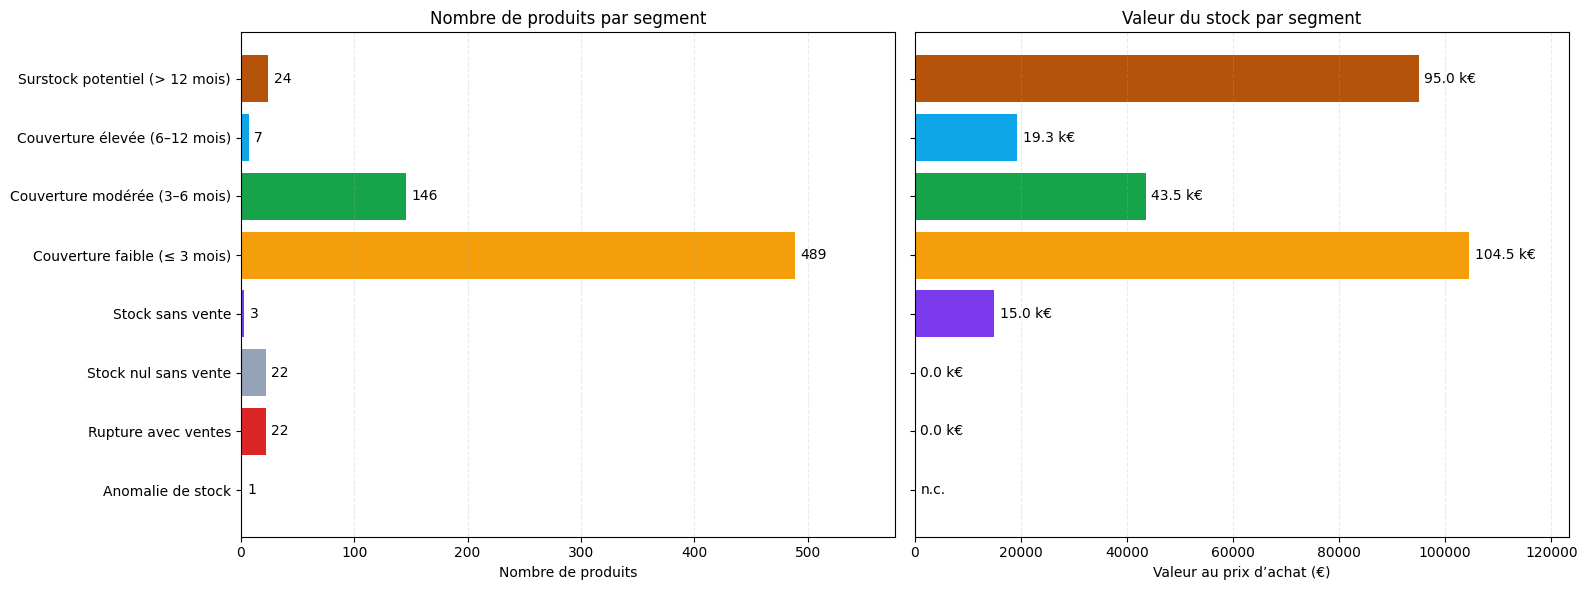

In [61]:
segments = ["Anomalie de stock", "Rupture avec ventes", "Stock nul sans vente",
            "Stock sans vente", "Couverture faible (≤ 3 mois)",
            "Couverture modérée (3–6 mois)", "Couverture élevée (6–12 mois)",
            "Surstock potentiel (> 12 mois)"]

conditions = [
    df_final["stock_quantity_analysis"].isna(),
    df_final["stock_quantity_analysis"].eq(0) & df_final["total_sales_analysis"].gt(0),
    df_final["stock_quantity_analysis"].eq(0) & df_final["total_sales_analysis"].eq(0),
    df_final["stock_quantity_analysis"].gt(0) & df_final["total_sales_analysis"].eq(0),
    df_final["couverture_stock_mois"].le(3),
    df_final["couverture_stock_mois"].gt(3) & df_final["couverture_stock_mois"].le(6),
    df_final["couverture_stock_mois"].gt(6) & df_final["couverture_stock_mois"].le(12),
    df_final["couverture_stock_mois"].gt(12)]

df_final["segment_stock"] = pd.Categorical(
    np.select(conditions, segments, default="À qualifier"),
    categories=segments + ["À qualifier"], ordered=True)

synthese_segments = (df_final.groupby("segment_stock", observed=False)
    .agg(nombre_produits=("product_id", "size"),
         stock_total=("stock_quantity_analysis", lambda x: x.sum(min_count=1)),
         valeur_stock=("valeur_stock_prix_achat", lambda x: x.sum(min_count=1)))
    .reset_index())
synthese_segments["part_valeur_stock"] = (
    synthese_segments["valeur_stock"] / synthese_segments["valeur_stock"].sum())
synthese_segments = synthese_segments[synthese_segments["nombre_produits"].gt(0)]

fmt_nombre = lambda x: f"{x:,.0f}".replace(",", " ")
fmt_euro = lambda x: f"{x:,.2f} €".replace(",", " ").replace(".", ",")

display(synthese_segments.style
    .format({"nombre_produits": fmt_nombre, "stock_total": fmt_nombre,
             "valeur_stock": fmt_euro, "part_valeur_stock": "{:.2%}"},
            na_rep="Non calculable").hide(axis="index"))

couleurs = ["#991B1B", "#DC2626", "#94A3B8", "#7C3AED",
            "#F59E0B", "#16A34A", "#0EA5E9", "#B45309"]
graph = synthese_segments.copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, colonne, titre in zip(
    axes,
    ["nombre_produits", "valeur_stock"],
    ["Nombre de produits par segment", "Valeur du stock par segment"]):

    valeurs = graph[colonne].fillna(0)
    barres = ax.barh(graph["segment_stock"].astype("string"), valeurs, color=couleurs)
    etiquettes = ([f"{int(v)}" for v in valeurs] if colonne == "nombre_produits"
                  else ["n.c." if pd.isna(v) else f"{v / 1000:.1f} k€"
                        for v in graph[colonne]])
    ax.bar_label(barres, labels=etiquettes, padding=4)
    ax.invert_yaxis()
    ax.set_title(titre)
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.margins(x=0.18)

axes[0].set_xlabel("Nombre de produits")
axes[1].set_xlabel("Valeur au prix d’achat (€)")
plt.tight_layout()
plt.show()

#### Interprétation de la segmentation

La segmentation met en évidence plusieurs enjeux opérationnels et financiers :

- **489 produits**, soit **68,49 % du catalogue analysé**, disposent d’une couverture inférieure ou égale à trois mois. Ils représentent **37,68 % de la valeur du stock**.
- **22 produits vendus en octobre sont en rupture de stock**. Ils doivent être analysés en priorité afin d’évaluer les besoins de réapprovisionnement et le risque de ventes perdues.
- **24 produits seulement**, soit **3,36 % du catalogue**, présentent une couverture supérieure à douze mois. Ils concentrent **95 011,92 €**, soit **34,26 % de la valeur totale du stock rapproché**.
- **3 produits sans aucune vente en octobre** immobilisent à eux seuls **14 959,40 €**, soit **5,39 % de la valeur du stock**.
- En ajoutant les 7 produits dont la couverture est comprise entre 6 et 12 mois, **34 produits à surveiller concentrent 129 308,60 €**, soit **46,63 % de la valeur totale du stock analysé**.

Ces résultats montrent qu’une part importante du capital immobilisé est concentrée sur un nombre limité de références. Une validation métier reste nécessaire pour distinguer les véritables surstocks des produits premium, saisonniers, récemment commercialisés ou soumis à de longs délais d’approvisionnement.

#### 5.3.3 – Identification des produits prioritaires

Deux listes d’action sont constituées :

1. les références présentant le plus fort risque d’immobilisation financière, en raison d’une couverture supérieure à douze mois ou de l’absence de ventes ;
2. les ruptures ayant enregistré les volumes de ventes les plus élevés en octobre.

Ces classements permettent de prioriser les analyses métier, les actions commerciales et les décisions de réapprovisionnement.

Produits à risque d’immobilisation : 27


rang,Product ID,SKU,Produit,Segment,Stock,Ventes octobre,Couverture,Valeur du stock
1,5892,14983,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,Surstock potentiel (> 12 mois),98,6,16.3 mois,"11 373,88 €"
2,6126,14923,Champagne Gosset Célébris Vintage 2007,Surstock potentiel (> 12 mois),138,5,27.6 mois,"11 085,54 €"
3,5025,13914,Champagne Agrapart & Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,Surstock potentiel (> 12 mois),136,6,22.7 mois,"9 329,60 €"
4,4355,12589,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,Stock sans vente,97,0,Aucune vente,"7 515,56 €"
5,4337,4679,Champagne Mailly Grand Cru Les Echansons 2007,Stock sans vente,145,0,Aucune vente,"7 090,50 €"
6,4350,12588,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,Surstock potentiel (> 12 mois),145,7,20.7 mois,"6 858,50 €"
7,4359,13853,Champagne Larmandier-Bernier Grand Cru Les Chemins d'Avize 2011,Surstock potentiel (> 12 mois),112,7,16.0 mois,"5 816,16 €"
8,4150,1366,Champagne Mailly Grand Cru Intemporelle 2010,Surstock potentiel (> 12 mois),123,6,20.5 mois,"4 360,35 €"
9,4348,12586,Champagne Egly-Ouriet Grand Cru Brut Tradition,Surstock potentiel (> 12 mois),125,5,25.0 mois,"4 345,00 €"
10,4334,7818,Champagne Gosset Grand Blanc de Blancs,Surstock potentiel (> 12 mois),142,7,20.3 mois,"4 261,42 €"


Produits vendus en rupture : 22


rang,Product ID,SKU,Produit,Ventes octobre,Prix TTC,CA TTC
1,4726,14950,François Baur Pinot Noir Schlittweg 2017,22,"12,70 €","279,40 €"
2,4870,16149,Triennes IGP Méditerranée Rosé 2019,16,"9,30 €","148,80 €"
3,4241,14725,Parcé Frères IGP Côtes Catalanes Hommage à Fernand Blanc 2019,15,"8,90 €","133,50 €"
4,5930,16323,Borie La Vitarèle Languedoc Blanc Le Grand Mayol 2019,14,"14,10 €","197,40 €"
5,4352,15940,Champagne Egly-Ouriet Grand Cru Millésimé 2008,11,"225,00 €","2 475,00 €"
6,4885,14981,Saumaize-Michelin Mâcon Vergisson Sur La Roche 2017,10,"18,70 €","187,00 €"
7,4706,15349,Albert Mann Muscat 2018,10,"16,80 €","168,00 €"
8,5487,16129,Decelle-Villa Nuits-Saint-Georges Rouge 2016,9,"43,50 €","391,50 €"
9,5617,14844,Albert Boxler Pinot Gris Réserve 2016,9,"27,80 €","250,20 €"
10,4256,14253,Domaine Huet Vouvray Haut-Lieu Sec 2017,9,"24,40 €","219,60 €"


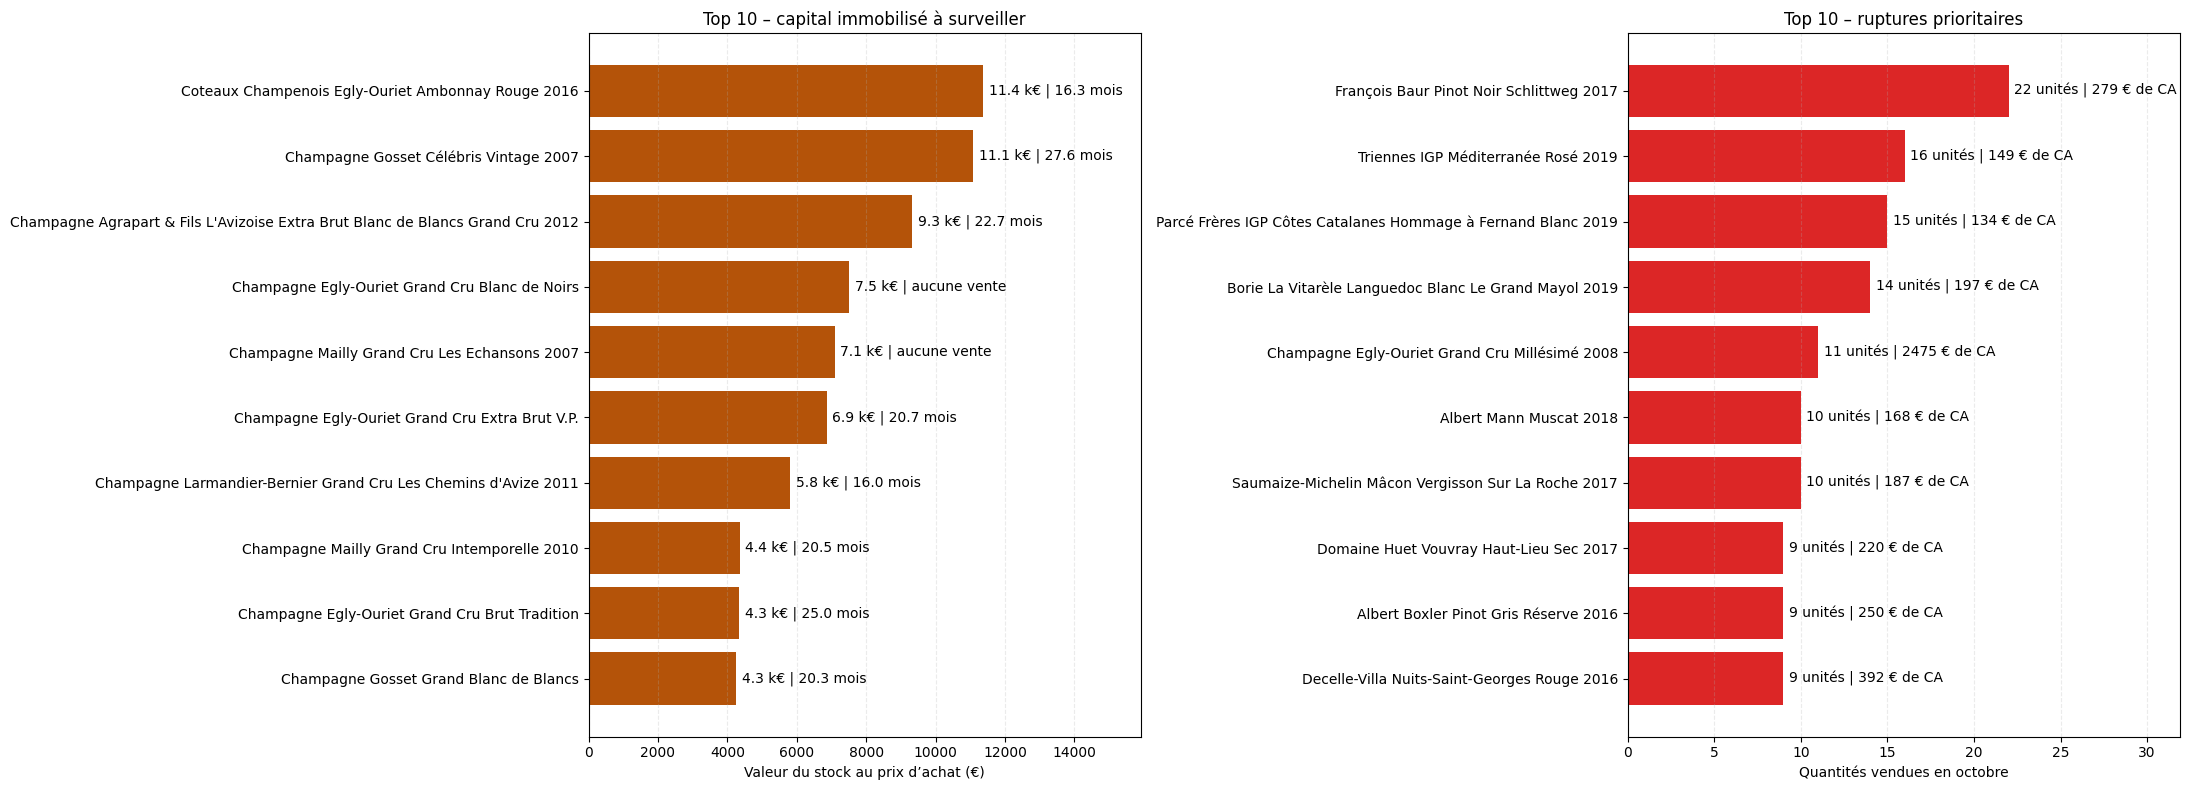

In [62]:
# Produits à risque d’immobilisation
produits_immobilises = (df_final[
    df_final["segment_stock"].isin(["Stock sans vente", "Surstock potentiel (> 12 mois)"])]
    .sort_values("valeur_stock_prix_achat", ascending=False))

top15_immobilisation = produits_immobilises.head(15).copy()
top15_immobilisation.insert(0, "rang", range(1, len(top15_immobilisation) + 1))

table_immobilisation = top15_immobilisation[[
    "rang", "product_id", "sku_analysis", "post_title_display", "segment_stock",
    "stock_quantity_analysis", "total_sales_analysis", "couverture_stock_mois",
    "valeur_stock_prix_achat"]].rename(columns={
    "product_id": "Product ID", "sku_analysis": "SKU",
    "post_title_display": "Produit", "segment_stock": "Segment",
    "stock_quantity_analysis": "Stock", "total_sales_analysis": "Ventes octobre",
    "couverture_stock_mois": "Couverture", "valeur_stock_prix_achat": "Valeur du stock"})

print(f"Produits à risque d’immobilisation : {len(produits_immobilises)}")
display(table_immobilisation.style.format({
    "Stock": fmt_nombre, "Ventes octobre": fmt_nombre,
    "Couverture": lambda x: f"{x:.1f} mois",
    "Valeur du stock": fmt_euro}, na_rep="Aucune vente").hide(axis="index"))

# Ruptures prioritaires
ruptures_prioritaires = (df_final[df_final["segment_stock"].eq("Rupture avec ventes")]
    .sort_values(["total_sales_analysis", "ca_ttc_calcule"], ascending=False))

top10_ruptures = ruptures_prioritaires.head(10).copy()
top10_ruptures.insert(0, "rang", range(1, len(top10_ruptures) + 1))

table_ruptures = top10_ruptures[[
    "rang", "product_id", "sku_analysis", "post_title_display",
    "total_sales_analysis", "price_analysis", "ca_ttc_calcule"]].rename(columns={
    "product_id": "Product ID", "sku_analysis": "SKU",
    "post_title_display": "Produit", "total_sales_analysis": "Ventes octobre",
    "price_analysis": "Prix TTC", "ca_ttc_calcule": "CA TTC"})

print(f"Produits vendus en rupture : {len(ruptures_prioritaires)}")
display(table_ruptures.style.format({
    "Ventes octobre": fmt_nombre, "Prix TTC": fmt_euro,
    "CA TTC": fmt_euro}).hide(axis="index"))

# Visualisations Top 10
graph_immo = produits_immobilises.head(10).sort_values("valeur_stock_prix_achat")
graph_rupture = ruptures_prioritaires.head(10).sort_values("total_sales_analysis")

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

barres1 = axes[0].barh(
    graph_immo["post_title_display"],
    graph_immo["valeur_stock_prix_achat"], color="#B45309")
labels1 = [
    f"{v / 1000:.1f} k€ | {c:.1f} mois" if pd.notna(c)
    else f"{v / 1000:.1f} k€ | aucune vente"
    for v, c in zip(graph_immo["valeur_stock_prix_achat"],
                    graph_immo["couverture_stock_mois"])]
axes[0].bar_label(barres1, labels=labels1, padding=4)
axes[0].set_title("Top 10 – capital immobilisé à surveiller")
axes[0].set_xlabel("Valeur du stock au prix d’achat (€)")
axes[0].set_xlim(0, graph_immo["valeur_stock_prix_achat"].max() * 1.4)

barres2 = axes[1].barh(
    graph_rupture["post_title_display"],
    graph_rupture["total_sales_analysis"], color="#DC2626")
labels2 = [
    f"{int(q)} unités | {ca:.0f} € de CA"
    for q, ca in zip(graph_rupture["total_sales_analysis"],
                     graph_rupture["ca_ttc_calcule"])]
axes[1].bar_label(barres2, labels=labels2, padding=4)
axes[1].set_title("Top 10 – ruptures prioritaires")
axes[1].set_xlabel("Quantités vendues en octobre")
axes[1].set_xlim(0, graph_rupture["total_sales_analysis"].max() * 1.45)

for ax in axes:
    ax.grid(axis="x", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

#### Interprétation des produits prioritaires

Les dix principales références à risque d’immobilisation représentent **72 036,51 €**, soit **25,98 % de la valeur totale du stock rapproché ERP–Web** et environ **65,50 % de la valeur des produits classés en surstock potentiel ou sans vente**.

Les trois premières références concentrent à elles seules **31 789,02 €**. Deux produits sans aucune vente en octobre représentent **14 606,06 €**, soit presque toute la valeur du segment « stock sans vente ».

La valorisation de **7 515,56 €** associée au produit `4355` doit cependant être interprétée avec prudence, car son prix d’achat fait partie des valeurs nécessitant une validation métier.

Concernant les ruptures, les dix références prioritaires cumulent **125 unités vendues** et **4 450,40 € de chiffre d’affaires TTC** en octobre.

Le produit `4352`, Champagne Egly-Ouriet Grand Cru Millésimé 2008, constitue une priorité financière particulière : malgré un volume de 11 unités, il a généré **2 475 € de chiffre d’affaires**, soit le montant le plus élevé du groupe.

Le produit `4885` constitue également une priorité de qualité des données : son stock est nul alors que son statut ERP était renseigné comme `instock`.

Les actions recommandées sont la validation des prix d’achat, la vérification physique des stocks, l’analyse des besoins de réapprovisionnement et la mise en place d’actions commerciales ciblées sur les références à rotation lente.

#### 5.3.4 – Analyse de sensibilité du DOH à la qualité des prix d’achat

Le DOH financier dépend directement de la fiabilité des prix d’achat enregistrés dans l’ERP. Quatre références présentent un prix d’achat supérieur au prix de vente HT estimé.

Deux options sont comparées :

- **option 1 – conserver les données sources** : cohérente avec la valorisation actuellement enregistrée dans l’ERP et avec le bilan ;
- **option 2 – exclure provisoirement les lignes à valider** : utilisée uniquement comme analyse de sensibilité, puisqu’aucune valeur de remplacement fiable n’est disponible.

La valeur source est conservée comme indicateur principal. L’analyse hors lignes à valider permet de mesurer l’impact potentiel des anomalies.

In [63]:
# Qualification des prix d’achat
for dataframe in [df_erp, df_final]:
    dataframe["controle_prix_achat"] = np.select(
        [dataframe["price_ht_analysis"].isna(),
         dataframe["purchase_price_analysis"].gt(dataframe["price_ht_analysis"])],
        ["Non calculable", "Prix d’achat à valider"], default="Cohérent")

lignes_achat_a_valider = df_erp[
    df_erp["controle_prix_achat"].eq("Prix d’achat à valider")].copy()
lignes_achat_a_valider["valeur_stock_concernee"] = (
    lignes_achat_a_valider["stock_quantity_analysis"] *
    lignes_achat_a_valider["purchase_price_analysis"])

controle_achat = lignes_achat_a_valider[[
    "product_id", "price", "price_ht_analysis", "purchase_price_analysis",
    "stock_quantity_analysis", "valeur_stock_concernee"]].rename(columns={
    "product_id": "Product ID", "price": "Prix TTC",
    "price_ht_analysis": "Prix HT estimé",
    "purchase_price_analysis": "Prix d’achat",
    "stock_quantity_analysis": "Stock",
    "valeur_stock_concernee": "Valeur du stock concernée"})

display(controle_achat.style.format({
    "Prix TTC": fmt_euro, "Prix HT estimé": fmt_euro,
    "Prix d’achat": fmt_euro, "Stock": fmt_nombre,
    "Valeur du stock concernée": fmt_euro}).hide(axis="index"))

# Sensibilité du DOH
valeur_prix_a_valider = lignes_achat_a_valider["valeur_stock_concernee"].sum()
valeur_stock_hors_validation = valeur_stock_erp - valeur_prix_a_valider
doh_source = valeur_stock_erp / cout_ventes_octobre * 30
doh_hors_validation = valeur_stock_hors_validation / cout_ventes_octobre * 30

synthese_sensibilite = pd.DataFrame({
    "indicateur": [
        "Références avec prix d’achat à valider",
        "Valeur de stock concernée",
        "Part de la valorisation ERP",
        "DOH basé sur les données sources",
        "DOH hors lignes à valider – sensibilité",
        "Impact potentiel sur le DOH"],
    "valeur": [
        f"{len(lignes_achat_a_valider)} références",
        fmt_euro(valeur_prix_a_valider),
        f"{valeur_prix_a_valider / valeur_stock_erp:.2%}",
        f"{doh_source:.2f} jours",
        f"{doh_hors_validation:.2f} jours",
        f"{doh_source - doh_hors_validation:.2f} jours"]})

display(synthese_sensibilite)

Product ID,Prix TTC,Prix HT estimé,Prix d’achat,Stock,Valeur du stock concernée
4355,"12,65 €","10,54 €","77,48 €",97,"7 515,56 €"
4864,"8,30 €","6,92 €","9,99 €",0,"0,00 €"
6324,"92,00 €","76,67 €","99,00 €",18,"1 782,00 €"
7196,"31,00 €","25,83 €","31,20 €",55,"1 716,00 €"


,indicateur,valeur
0,Références avec prix d’achat à valider,4 références
1,Valeur de stock concernée,"11 013,56 €"
2,Part de la valorisation ERP,3.69%
3,DOH basé sur les données sources,119.34 jours
4,DOH hors lignes à valider – sensibilité,114.93 jours
5,Impact potentiel sur le DOH,4.40 jours


#### Interprétation de l’analyse de sensibilité

Les quatre références à valider représentent **11 013,56 €**, soit **3,69 % de la valorisation totale du stock ERP**.

Le produit `4864` ne génère aucun impact sur la valorisation, car son stock est nul. Le produit `4355` concentre à lui seul **7 515,56 €**, soit environ **68,24 % de la valeur concernée par le contrôle**.

En conservant les prix d’achat enregistrés dans l’ERP, le DOH financier estimé est de **119,34 jours**. L’exclusion provisoire des quatre références ramènerait cet indicateur à **114,93 jours**, soit une variation potentielle de **4,40 jours**.

Cette seconde valeur ne constitue pas un DOH corrigé, car aucune donnée de remplacement fiable n’est disponible. Elle permet uniquement de mesurer la sensibilité de l’indicateur à la qualité des prix d’achat.

**Décision retenue :** conserver le DOH de **119,34 jours** comme indicateur principal, maintenir les valeurs sources pour garantir la traçabilité et demander une validation métier des quatre prix d’achat avant toute correction.

#### 5.3.5 – POC non supervisé de segmentation des profils de stock et de rotation

Ce POC vise à identifier automatiquement des groupes de produits présentant des caractéristiques similaires de ventes, de stock et d’immobilisation financière.

Il s’agit d’une démarche **non supervisée** : aucune catégorie de risque n’est fournie à l’algorithme pendant l’apprentissage. Les segments métier définis précédemment sont conservés uniquement pour interpréter les groupes obtenus et vérifier si les produits en rupture ou en surstock se concentrent dans certains clusters.

Trois variables quantitatives sont utilisées :

- les quantités vendues en octobre ;
- le stock disponible au 31 octobre ;
- la valeur du stock au prix d’achat.

La couverture de stock n’est pas utilisée pour constituer les clusters, car elle n’est pas calculable pour les produits sans vente. Le nombre de clusters sera évalué entre 2 et 6 à partir de l’inertie et du coefficient de silhouette.

Ce POC ne vise pas à prédire une rupture future. Il cherche à déterminer si une segmentation statistique apporte une information complémentaire aux règles métier déjà appliquées.

In [64]:
# Préparation de la base du clustering
variables_clustering = ["total_sales_analysis", "stock_quantity_analysis", "valeur_stock_prix_achat"]
colonnes_identification = ["product_id", "post_title_display", "segment_stock"]

base_clustering = (
    df_final[colonnes_identification + variables_clustering].dropna(subset=variables_clustering).reset_index(drop=True).copy())

assert (base_clustering[variables_clustering] >= 0).all().all(), \
      "Une valeur négative subsiste dans les variables du clustering."

# Réduction de l’asymétrie puis standardisation
X_clustering_log = np.log1p(base_clustering[variables_clustering])
standardiseur_clustering = StandardScaler()
X_clustering = standardiseur_clustering.fit_transform(X_clustering_log)

print(f"Base du clustering : {len(base_clustering)} produits × {len(variables_clustering)} variables")
print("Variables utilisées :", variables_clustering)
print("Produits exclus pour données non exploitables :", len(df_final) - len(base_clustering))

display(base_clustering[variables_clustering].describe().T.round(2))

Base du clustering : 713 produits × 3 variables
Variables utilisées : ['total_sales_analysis', 'stock_quantity_analysis', 'valeur_stock_prix_achat']
Produits exclus pour données non exploitables : 1


,count,mean,std,min,25%,50%,75%,max
total_sales_analysis,713.0,8.05,4.16,0.0,5.00,8.00,11.00,36.00
stock_quantity_analysis,713.0,23.48,22.22,0.0,9.00,20.00,30.00,145.00
valeur_stock_prix_achat,713.0,388.96,994.18,0.0,138.88,202.32,285.44,11373.88


##### Choix du nombre de clusters

Plusieurs segmentations comprises entre deux et six clusters sont comparées. L’inertie mesure la compacité des groupes, tandis que le coefficient de silhouette évalue à la fois leur cohésion interne et leur séparation.

Le nombre de clusters sera choisi en combinant les résultats statistiques et la possibilité d’interpréter les groupes d’un point de vue métier.

nombre_clusters,inertie,silhouette
2,"1,086.33",0.697
3,653.58,0.487
4,500.57,0.524
5,361.19,0.541
6,259.50,0.455


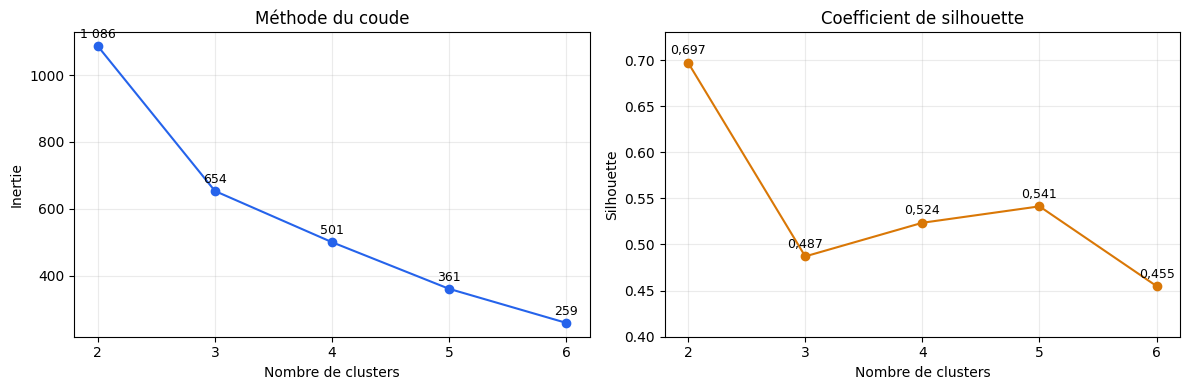

In [65]:
# Comparaison de plusieurs nombres de clusters
resultats_k = []

for k in range(2, 7):
    modele_k = KMeans(n_clusters=k, random_state=42, n_init=20)
    etiquettes_k = modele_k.fit_predict(X_clustering)
    resultats_k.append({
        "nombre_clusters": k,
        "inertie": modele_k.inertia_,
        "silhouette": silhouette_score(X_clustering, etiquettes_k)})

evaluation_clusters = pd.DataFrame(resultats_k)

display(evaluation_clusters.style.format({"inertie": "{:,.2f}", "silhouette": "{:.3f}"}).hide(axis="index"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    evaluation_clusters["nombre_clusters"],
    evaluation_clusters["inertie"],
    marker="o", color="#2563EB")
axes[0].set(
    title="Méthode du coude",
    xlabel="Nombre de clusters",
    ylabel="Inertie")

axes[1].plot(
    evaluation_clusters["nombre_clusters"],
    evaluation_clusters["silhouette"],
    marker="o", color="#D97706")
axes[1].set(
    title="Coefficient de silhouette",
    xlabel="Nombre de clusters",
    ylabel="Silhouette",
    ylim=(0.40, 0.73))

for x, y in zip(
        evaluation_clusters["nombre_clusters"],
        evaluation_clusters["inertie"]):
    axes[0].annotate(
        f"{y:,.0f}".replace(",", " "),
       (x, y), xytext=(0, 6),
       textcoords="offset points",
       ha="center", fontsize=9)

for x, y in zip(
        evaluation_clusters["nombre_clusters"],
        evaluation_clusters["silhouette"]):
   axes[1].annotate(
       f"{y:.3f}".replace(".", ","),
       (x, y), xytext=(0, 6),
       textcoords="offset points",
       ha="center", fontsize=9)
   
for ax in axes:
    ax.set_xticks(range(2, 7))
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

##### Comparaison des segmentations candidates

La solution à deux clusters présente le meilleur coefficient de silhouette (0,697), ce qui indique une séparation statistique nette. Elle peut cependant produire une lecture métier trop générale.

La solution à cinq clusters obtient un coefficient de silhouette inférieur mais encore satisfaisant (0,541). Elle pourrait faire apparaître des profils plus différenciés de rotation, de rupture et d’immobilisation.

Les deux solutions sont donc comparées à partir de la taille des groupes, de leurs valeurs médianes et de la concentration des segments métier à risque.

In [66]:
# Comparaison métier des solutions à 2 et 5 clusters
base_clustering["est_rupture"] = base_clustering["segment_stock"].eq("Rupture avec ventes")
base_clustering["risque_immobilisation"] = base_clustering["segment_stock"].isin(
    ["Stock sans vente", "Surstock potentiel (> 12 mois)"])

profils_candidats = {}

for k in [2, 5]:
    modele = KMeans(n_clusters=k, random_state=42, n_init=20)
    base_clustering[f"cluster_k{k}"] = modele.fit_predict(X_clustering)

    profil = (
        base_clustering.groupby(f"cluster_k{k}")
        .agg(
            produits=("product_id", "size"),
            ventes_medianes=("total_sales_analysis", "median"),
            stock_median=("stock_quantity_analysis", "median"),
            valeur_stock_mediane=("valeur_stock_prix_achat", "median"),
            ruptures=("est_rupture", "sum"),
            risques_immobilisation=("risque_immobilisation", "sum"))
        .reset_index())

    profil["part_ruptures"] = 100 * profil["ruptures"] / profil["produits"]
    profil["part_risque_immobilisation"] = (
        100 * profil["risques_immobilisation"] / profil["produits"])
    profils_candidats[k] = profil

    print(f"\nSolution à {k} clusters")
    display(
        profil.style
        .format({
            "ventes_medianes": "{:.1f}",
            "stock_median": "{:.1f}",
            "valeur_stock_mediane": "{:,.2f} €",
            "part_ruptures": "{:.1f} %",
            "part_risque_immobilisation": "{:.1f} %"})
        .hide(axis="index"))


Solution à 2 clusters


cluster_k2,produits,ventes_medianes,stock_median,valeur_stock_mediane,ruptures,risques_immobilisation,part_ruptures,part_risque_immobilisation
0,658,8.0,23.0,213.36 €,0,27,0.0 %,4.1 %
1,55,1.0,0.0,0.00 €,22,0,40.0 %,0.0 %



Solution à 5 clusters


cluster_k5,produits,ventes_medianes,stock_median,valeur_stock_mediane,ruptures,risques_immobilisation,part_ruptures,part_risque_immobilisation
0,435,10.0,27.0,232.12 €,0,0,0.0 %,0.0 %
1,24,0.0,0.0,0.00 €,2,0,8.3 %,0.0 %
2,20,8.5,0.0,0.00 €,20,0,100.0 %,0.0 %
3,206,4.0,7.0,157.86 €,0,3,0.0 %,1.5 %
4,28,6.0,102.0,"3,919.35 €",0,24,0.0 %,85.7 %


##### Sélection de la solution retenue

La solution à deux clusters obtient le meilleur coefficient de silhouette, mais elle sépare principalement les produits disposant d’un stock des produits présentant un stock faible ou nul. Cette segmentation reste trop générale pour orienter précisément les actions métier.

La solution à cinq clusters est retenue, car elle apporte une lecture plus opérationnelle :

- un cluster concentre 20 des 22 produits vendus en rupture de stock ;
- les deux clusters caractérisés par un stock nul regroupent ensemble les 22 ruptures observées ;
- un cluster de 28 produits concentre 24 des 27 risques d’immobilisation, avec un stock médian de 102 unités et une valeur de stock médiane de 3 919,35 € ;
- les trois autres risques d’immobilisation apparaissent dans un groupe de produits à faible rotation.

Bien que son coefficient de silhouette soit inférieur à celui de la solution à deux clusters, la segmentation à cinq groupes est conservée pour sa meilleure interprétabilité et sa plus grande utilité métier. Les numéros attribués aux clusters sont uniquement des identifiants techniques et ne représentent aucun ordre de priorité.

In [67]:
# Modèle de clustering retenu
nombre_clusters_retenu = 5
modele_clustering = KMeans(
    n_clusters=nombre_clusters_retenu,
    random_state=42,
    n_init=20)

base_clustering["cluster"] = modele_clustering.fit_predict(X_clustering)

comparaison_segments_clusters = pd.crosstab(
    base_clustering["cluster"],
    base_clustering["segment_stock"],
    margins=True,
    margins_name="Total")

display(comparaison_segments_clusters)

segment_stock,Rupture avec ventes,Stock nul sans vente,Stock sans vente,Couverture faible (≤ 3 mois),Couverture modérée (3–6 mois),Couverture élevée (6–12 mois),Surstock potentiel (> 12 mois),Total
cluster,,,,,,,,
0,0,0,0,303,132,0,0,435
1,2,22,0,0,0,0,0,24
2,20,0,0,0,0,0,0,20
3,0,0,1,186,14,3,2,206
4,0,0,2,0,0,4,22,28
Total,22,22,3,489,146,7,24,713


##### Interprétation métier des clusters

Le croisement avec les segments définis par les règles métier permet d’interpréter les cinq groupes :

- le cluster 0 regroupe les produits présentant une rotation soutenue et une couverture globalement maîtrisée ;
- le cluster 1 rassemble principalement les produits sans stock et sans vente ;
- le cluster 2 isole les ruptures actives, c’est-à-dire les produits vendus malgré un stock nul ;
- le cluster 3 correspond à des produits à rotation plus faible, généralement associés à un stock limité ;
- le cluster 4 concentre les situations de surstock et de capital immobilisé.

Les libellés métier sont ajoutés après l’apprentissage. Ils n’ont donc pas influencé la constitution des clusters.

In [68]:
# Attribution de libellés métier après le clustering
libelles_clusters = {
    0: "Rotation soutenue – stock maîtrisé",
    1: "Stock nul – ventes absentes ou marginales",
    2: "Ruptures actives – réapprovisionnement prioritaire",
    3: "Rotation faible – stock limité",
    4: "Surstock – capital immobilisé"}

base_clustering["profil_cluster"] = base_clustering["cluster"].map(libelles_clusters)

profil_clusters = (
    base_clustering.groupby(["cluster", "profil_cluster"])
    .agg(
        produits=("product_id", "size"),
        ventes_medianes=("total_sales_analysis", "median"),
        stock_median=("stock_quantity_analysis", "median"),
        valeur_stock_totale=("valeur_stock_prix_achat", "sum"),
        valeur_stock_mediane=("valeur_stock_prix_achat", "median"),
        ruptures=("est_rupture", "sum"),
        risques_immobilisation=("risque_immobilisation", "sum"))
    .reset_index())

profil_clusters["part_catalogue"] = 100 * profil_clusters["produits"] / len(base_clustering)
profil_clusters["part_valeur_stock"] = (
    100 * profil_clusters["valeur_stock_totale"]
    / profil_clusters["valeur_stock_totale"].sum())

profil_clusters = profil_clusters[[
    "cluster", "profil_cluster", "produits", "part_catalogue",
    "ventes_medianes", "stock_median", "valeur_stock_totale",
    "part_valeur_stock", "ruptures", "risques_immobilisation"]]

display(
    profil_clusters.style
    .format({
        "part_catalogue": "{:.1f} %",
        "ventes_medianes": "{:.1f}",
        "stock_median": "{:.1f}",
        "valeur_stock_totale": "{:,.2f} €",
        "part_valeur_stock": "{:.1f} %"})
    .hide(axis="index"))

cluster,profil_cluster,produits,part_catalogue,ventes_medianes,stock_median,valeur_stock_totale,part_valeur_stock,ruptures,risques_immobilisation
0,Rotation soutenue – stock maîtrisé,435,61.0 %,10.0,27.0,"108,230.76 €",39.0 %,0,0
1,Stock nul – ventes absentes ou marginales,24,3.4 %,0.0,0.0,0.00 €,0.0 %,2,0
2,Ruptures actives – réapprovisionnement prioritaire,20,2.8 %,8.5,0.0,0.00 €,0.0 %,20,0
3,Rotation faible – stock limité,206,28.9 %,4.0,7.0,"45,948.58 €",16.6 %,0,3
4,Surstock – capital immobilisé,28,3.9 %,6.0,102.0,"123,148.73 €",44.4 %,0,24


##### Identification des produits par cluster

Chaque produit est rattaché à son cluster, à son profil métier et à ses principaux indicateurs. Cette table permet aux équipes métier d’identifier les références concernées et de passer de la segmentation statistique à une liste d’actions opérationnelles.

Le clustering complète les règles métier : celles-ci restent utilisées pour établir les listes exhaustives de ruptures et de risques d’immobilisation.

In [69]:
# Table détaillée des produits et de leur cluster
detail_clusters = (
    base_clustering[[
        "product_id", "post_title_display", "cluster", "profil_cluster",
        "segment_stock", "total_sales_analysis", "stock_quantity_analysis",
        "valeur_stock_prix_achat", "est_rupture",
        "risque_immobilisation"]]
    .merge(
        df_final[[
            "product_id", "price_analysis", "purchase_price_analysis",
            "couverture_stock_mois"]],
        on="product_id", how="left", validate="one_to_one"))

detail_clusters = detail_clusters[[
    "product_id", "post_title_display", "cluster", "profil_cluster",
    "segment_stock", "price_analysis", "purchase_price_analysis",
    "total_sales_analysis", "stock_quantity_analysis",
    "couverture_stock_mois", "valeur_stock_prix_achat",
    "est_rupture", "risque_immobilisation"]]

print(f"Produits rattachés à un cluster : {len(detail_clusters)}")

Produits rattachés à un cluster : 713


##### Exemple de consultation d’un cluster

L’exemple ci-dessous présente le détail du cluster 4, associé au surstock et au capital immobilisé. Le numéro peut être modifié afin de consulter chacun des cinq clusters.

In [70]:
# Exemple de consultation du cluster 4
cluster_a_consulter = 4

produits_cluster_selectionne = (
    detail_clusters[detail_clusters["cluster"] == cluster_a_consulter]
    .sort_values(
        ["valeur_stock_prix_achat", "total_sales_analysis"],
        ascending=False))

print(
    f"Cluster {cluster_a_consulter} – "
    f"{libelles_clusters[cluster_a_consulter]} : "
    f"{len(produits_cluster_selectionne)} produits")

display(
    produits_cluster_selectionne[[
        "product_id", "post_title_display", "segment_stock",
        "total_sales_analysis", "stock_quantity_analysis",
        "couverture_stock_mois", "valeur_stock_prix_achat"]]
    .style
    .format({
        "total_sales_analysis": "{:.0f}",
        "stock_quantity_analysis": "{:.0f}",
        "couverture_stock_mois": lambda x: "Non calculable" if pd.isna(x) else f"{x:.1f} mois",
        "valeur_stock_prix_achat": "{:,.2f} €"})
    .hide(axis="index"))

Cluster 4 – Surstock – capital immobilisé : 28 produits


product_id,post_title_display,segment_stock,total_sales_analysis,stock_quantity_analysis,couverture_stock_mois,valeur_stock_prix_achat
5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016,Surstock potentiel (> 12 mois),6,98,16.3 mois,"11,373.88 €"
6126,Champagne Gosset Célébris Vintage 2007,Surstock potentiel (> 12 mois),5,138,27.6 mois,"11,085.54 €"
5025,Champagne Agrapart & Fils L'Avizoise Extra Brut Blanc de Blancs Grand Cru 2012,Surstock potentiel (> 12 mois),6,136,22.7 mois,"9,329.60 €"
4355,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,Stock sans vente,0,97,Non calculable,"7,515.56 €"
4337,Champagne Mailly Grand Cru Les Echansons 2007,Stock sans vente,0,145,Non calculable,"7,090.50 €"
4350,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,Surstock potentiel (> 12 mois),7,145,20.7 mois,"6,858.50 €"
4353,Champagne Egly-Ouriet Grand Cru Brut Rosé,Couverture élevée (6–12 mois),14,127,9.1 mois,"5,830.57 €"
4359,Champagne Larmandier-Bernier Grand Cru Les Chemins d'Avize 2011,Surstock potentiel (> 12 mois),7,112,16.0 mois,"5,816.16 €"
5026,Champagne Agrapart & Fils Minéral Extra Brut Blanc de Blancs Grand Cru 2012,Couverture élevée (6–12 mois),9,101,11.2 mois,"5,063.13 €"
4150,Champagne Mailly Grand Cru Intemporelle 2010,Surstock potentiel (> 12 mois),6,123,20.5 mois,"4,360.35 €"


##### Visualisation du poids opérationnel et financier des clusters

Les graphiques comparent la part des produits et la valeur du stock associée à chaque profil. La valorisation présentée concerne uniquement les 713 produits inclus dans le clustering et ne correspond donc pas à la valeur totale du stock enregistrée dans l’ERP.

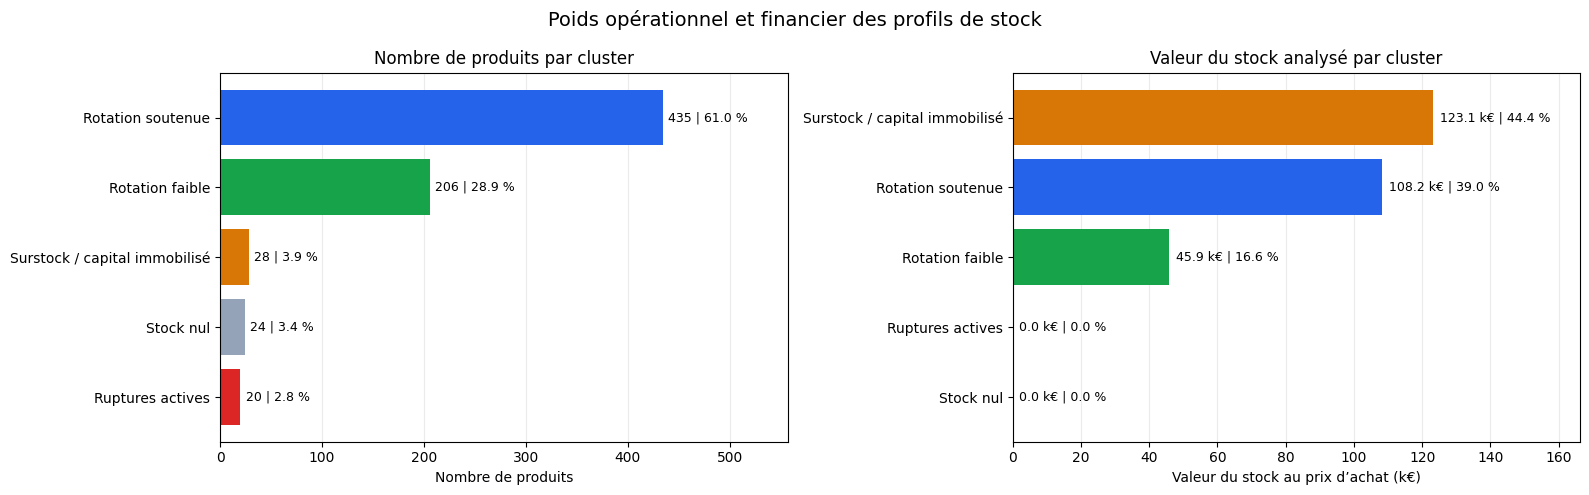

In [71]:
# Comparaison ordonnée du nombre de produits et de la valeur du stock
resume_graphique = profil_clusters.copy()

libelles_courts = {
    0: "Rotation soutenue",
    1: "Stock nul",
    2: "Ruptures actives",
    3: "Rotation faible",
    4: "Surstock / capital immobilisé"}

couleurs_par_cluster = {
    0: "#2563EB",
    1: "#94A3B8",
    2: "#DC2626",
    3: "#16A34A",
    4: "#D97706"}

resume_graphique["profil_court"] = resume_graphique["cluster"].map(libelles_courts)
resume_graphique["couleur"] = resume_graphique["cluster"].map(couleurs_par_cluster)
resume_graphique["valeur_stock_k€"] = resume_graphique["valeur_stock_totale"] / 1000

resume_produits = resume_graphique.sort_values("produits")
resume_valeur = resume_graphique.sort_values("valeur_stock_k€")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

barres_produits = axes[0].barh(
    resume_produits["profil_court"],
    resume_produits["produits"],
    color=resume_produits["couleur"])

axes[0].set(
    title="Nombre de produits par cluster",
    xlabel="Nombre de produits",
    xlim=(0, resume_produits["produits"].max() * 1.28))

for barre, nombre, part in zip(
        barres_produits,
        resume_produits["produits"],
        resume_produits["part_catalogue"]):
    axes[0].text(
        barre.get_width() + 5,
        barre.get_y() + barre.get_height() / 2,
        f"{nombre} | {part:.1f} %",
        va="center", fontsize=9)

barres_valeur = axes[1].barh(
    resume_valeur["profil_court"],
    resume_valeur["valeur_stock_k€"],
    color=resume_valeur["couleur"])

axes[1].set(
    title="Valeur du stock analysé par cluster",
    xlabel="Valeur du stock au prix d’achat (k€)",
    xlim=(0, resume_valeur["valeur_stock_k€"].max() * 1.35))

for barre, valeur, part in zip(
        barres_valeur,
        resume_valeur["valeur_stock_k€"],
        resume_valeur["part_valeur_stock"]):
    axes[1].text(
        barre.get_width() + 2,
        barre.get_y() + barre.get_height() / 2,
        f"{valeur:.1f} k€ | {part:.1f} %",
        va="center", fontsize=9)

for ax in axes:
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)

fig.suptitle(
    "Poids opérationnel et financier des profils de stock",
    fontsize=14)

plt.tight_layout()
plt.show()

##### Visualisation des clusters par type de produit

La catégorie de produit n’a pas été utilisée pour constituer les clusters. Elle est croisée avec les profils obtenus après l’apprentissage afin de vérifier si certains enjeux de rotation, de rupture ou d’immobilisation sont concentrés dans des catégories particulières.

Le tableau présente les effectifs, tandis que la carte thermique représente la composition en pourcentage de chaque cluster.


type_produit,Vin,Champagne,Whisky,Cognac,Huile d'olive,Gin,Non renseigné
Rotation soutenue,430,0,0,2,1,1,1
Stock nul,23,0,1,0,0,0,0
Ruptures actives,19,1,0,0,0,0,0
Rotation faible,185,0,13,6,1,1,0
Surstock / capital immobilisé,0,27,0,0,1,0,0


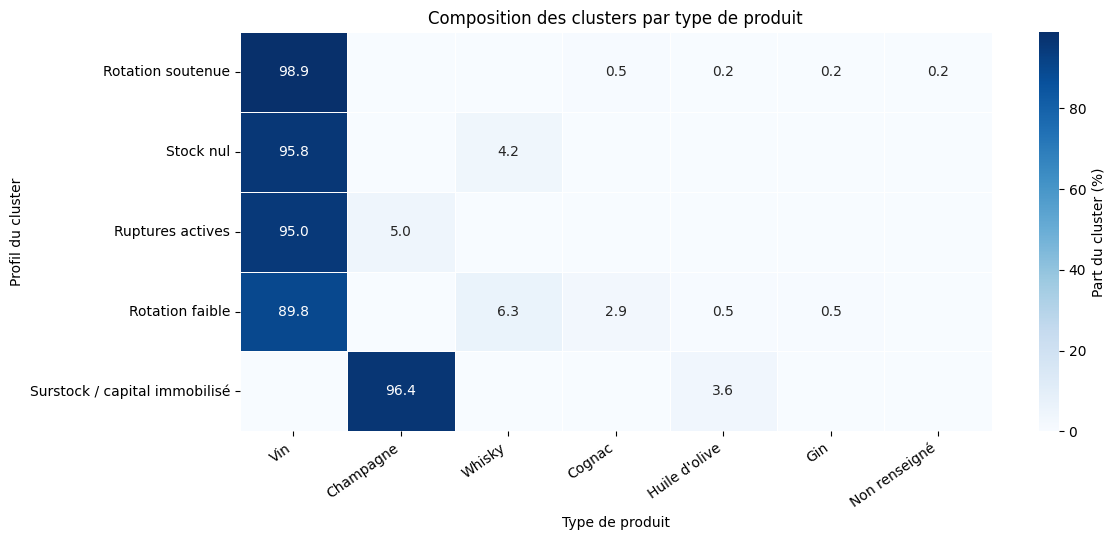

In [72]:
# Croisement a posteriori entre clusters et types de produit
categories_clusters = (
    base_clustering[["product_id", "cluster", "profil_cluster"]]
    .merge(
        df_final[["product_id", "product_type"]],
        on="product_id", how="left", validate="one_to_one"))

categories_clusters["type_produit"] = (
    categories_clusters["product_type"]
    .fillna("Non renseigné")
    .astype("string"))

tableau_categories_clusters = pd.crosstab(
    categories_clusters["cluster"],
    categories_clusters["type_produit"])

ordre_categories = (
    tableau_categories_clusters.sum(axis=0)
    .sort_values(ascending=False)
    .index)

tableau_categories_clusters = tableau_categories_clusters.reindex(
    index=range(nombre_clusters_retenu),
    columns=ordre_categories,
    fill_value=0)

tableau_categories_clusters.index = [
    libelles_courts[cluster]
    for cluster in tableau_categories_clusters.index]

part_categories_clusters = (
    100 * tableau_categories_clusters.div(
        tableau_categories_clusters.sum(axis=1), axis=0))

display(tableau_categories_clusters)

annotations_categories = part_categories_clusters.map(
    lambda valeur: "" if valeur == 0 else f"{valeur:.1f}")

plt.figure(figsize=(12, 5.5))
sns.heatmap(
    part_categories_clusters,
    annot=annotations_categories,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Part du cluster (%)"})

plt.title("Composition des clusters par type de produit")
plt.xlabel("Type de produit")
plt.ylabel("Profil du cluster")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


**Interprétation.** Le profil **Surstock – capital immobilisé** est presque exclusivement composé de Champagne : **27 produits sur 28**, soit **96,4 %** du cluster. Les **ruptures actives** concernent principalement le Vin, avec **19 produits sur 20**. Le cluster **Stock nul** regroupe 23 vins et un whisky, tandis que le profil de rotation faible est plus diversifié, avec notamment 185 vins, 13 whiskies et 6 cognacs.

Cette visualisation permet de cibler les actions par famille de produits, notamment l’analyse du stock de Champagne. La catégorie n’ayant pas participé à l’apprentissage du K-means, le résultat constitue une lecture métier a posteriori et non une relation causale.


##### Conclusion du POC non supervisé

Le clustering confirme l’existence de profils de stock fortement différenciés. La solution à cinq clusters est retenue malgré un coefficient de silhouette inférieur à celui de la solution à deux clusters, car elle produit une segmentation plus exploitable par les équipes métier.

Les principaux résultats sont les suivants :

- 435 produits présentent une rotation soutenue et un stock globalement maîtrisé ;
- 20 produits sont regroupés dans un cluster composé exclusivement de ruptures actives ;
- deux ruptures supplémentaires apparaissent dans le cluster des produits à stock nul, ce qui porte à 22 la liste exhaustive établie par les règles métier ;
- 28 produits, soit 3,9 % du catalogue analysé, concentrent 123 148,73 € de stock, soit 44,4 % de sa valeur ;
- ce dernier cluster regroupe 24 des 27 produits déjà identifiés comme présentant un risque d’immobilisation.

| Critère | Évaluation | Décision |
|---|---|---|
| Qualité | La solution à deux clusters obtient la meilleure silhouette, mais la solution à cinq clusters distingue plus précisément les profils opérationnels. | Cinq clusters retenus pour l’analyse métier. |
| Robustesse / biais | Les résultats dépendent des variables, de leur transformation et de la période observée. La transformation logarithmique limite l’influence des valeurs élevées. | Interprétation limitée aux données disponibles. |
| Interprétabilité | Le croisement avec les règles métier permet de nommer et d’expliquer les groupes. | Segmentation exploitable pour orienter les analyses. |
| Temps | Calcul négligeable sur 713 produits et trois variables. | Méthode proportionnée au volume. |
| Reproductibilité | Standardisation documentée, `n_init=20` et `random_state=42`. | Résultats reproductibles dans le même environnement. |
| Sécurité / conformité | Calcul local sur des données produit sans information personnelle. | Conforme au périmètre. |
| Maintenabilité | Implémentation courte avec scikit-learn et variables explicitement définies. | Réexécution simple lors d’une nouvelle extraction. |
| Sobriété | Trois variables et un algorithme léger suffisent à produire les groupes. | Aucun outil plus complexe nécessaire. |

Le clustering est conservé comme outil exploratoire complémentaire. Il ne remplace pas les règles métier, qui restent plus transparentes pour établir les listes exhaustives de ruptures et de surstocks, et ne constitue pas un modèle de prédiction des ruptures futures.

Avec une seule période d’observation, les clusters décrivent la situation au 31 octobre. Leur stabilité devra être vérifiée sur plusieurs mois avant toute utilisation récurrente ou automatisée.

### 5.4 – Analyse de la marge commerciale

L’analyse distingue deux indicateurs souvent confondus :

- **taux de marque** = marge brute / chiffre d’affaires HT ;
- **taux de marge** = marge brute / coût d’achat.

La marge brute est calculée comme suit :

> **Marge brute = chiffre d’affaires HT estimé – coût d’achat des produits vendus**

Les hypothèses retenues sont les suivantes :

- le prix de vente ERP est considéré comme TTC ;
- le prix HT est estimé avec un taux de TVA de 20 % ;
- le prix d’achat est considéré comme HT ;
- seuls les produits ayant enregistré des ventes et disposant des données nécessaires sont intégrés aux indicateurs globaux.

Dans le P6, le résultat de 37,3 % avait été présenté comme un taux de marge. Il correspond en réalité au **taux de marque global**. Cette distinction est corrigée dans la présente analyse.

In [73]:
# Calculs de marge par produit
df_final["marge_unitaire_ht"] = (
    df_final["price_ht_analysis"] - df_final["purchase_price_analysis"])
df_final["marge_brute_estimee"] = (
    df_final["ca_ht_estime"] - df_final["cout_ventes_octobre"])
df_final["taux_marque"] = np.where(
    df_final["price_ht_analysis"].gt(0),
    df_final["marge_unitaire_ht"] / df_final["price_ht_analysis"], np.nan)
df_final["taux_marge"] = np.where(
    df_final["purchase_price_analysis"].gt(0),
    df_final["marge_unitaire_ht"] / df_final["purchase_price_analysis"], np.nan)

masque_marge = (
    df_final["total_sales_analysis"].gt(0) &
    df_final["price_ht_analysis"].notna() &
    df_final["purchase_price_analysis"].notna())

df_marge = df_final[masque_marge].copy()
ca_ht_global = df_marge["ca_ht_estime"].sum()
cout_ventes_global = df_marge["cout_ventes_octobre"].sum()
marge_brute_globale = df_marge["marge_brute_estimee"].sum()
taux_marque_global = marge_brute_globale / ca_ht_global
taux_marge_global = marge_brute_globale / cout_ventes_global

synthese_marge = pd.DataFrame({
    "indicateur": [
        "Produits vendus",
        "Produits avec marge calculable",
        "Produits vendus avec marge négative",
        "Chiffre d’affaires HT estimé",
        "Coût d’achat des produits vendus",
        "Marge brute estimée",
        "Taux de marque global",
        "Taux de marge global"],
    "valeur": [
        f'{df_final["total_sales_analysis"].gt(0).sum()} produits',
        f"{len(df_marge)} produits",
        f'{df_marge["marge_brute_estimee"].lt(0).sum()} produit',
        fmt_euro(ca_ht_global),
        fmt_euro(cout_ventes_global),
        fmt_euro(marge_brute_globale),
        f"{taux_marque_global:.2%}",
        f"{taux_marge_global:.2%}"]})

display(synthese_marge)

,indicateur,valeur
0,Produits vendus,689 produits
1,Produits avec marge calculable,689 produits
2,Produits vendus avec marge négative,0 produit
3,Chiffre d’affaires HT estimé,"119 733,42 €"
4,Coût d’achat des produits vendus,"75 072,77 €"
5,Marge brute estimée,"44 660,65 €"
6,Taux de marque global,37.30%
7,Taux de marge global,59.49%


#### Interprétation des indicateurs globaux de marge

Les 689 produits ayant enregistré des ventes disposent des informations nécessaires au calcul de la marge. Aucune marge brute négative n’est observée sur ce périmètre.

Le chiffre d’affaires HT estimé s’élève à **119 733,42 €**, pour un coût d’achat des produits vendus de **75 072,77 €**. La marge brute estimée atteint ainsi **44 660,65 €**.

Le **taux de marque global de 37,30 %** signifie que chaque tranche de 100 € de chiffre d’affaires HT génère 37,30 € de marge brute.

Le **taux de marge global de 59,49 %** signifie que chaque tranche de 100 € de coût d’achat génère 59,49 € de marge brute.

Ces indicateurs globaux sont calculés à partir des montants cumulés de chiffre d’affaires et de coût. Ils ne correspondent pas à une moyenne simple des pourcentages calculés par produit. Cette méthode permet de prendre correctement en compte le poids de chaque référence dans le mix des ventes.

La marge brute ne correspond pas au résultat net : elle ne prend pas en compte les coûts logistiques, les frais de personnel, les dépenses marketing, les frais de structure ni les éventuelles remises non disponibles dans les données.

Les résultats reposent également sur l’hypothèse d’une TVA uniforme de 20 %, sur les prix d’achat enregistrés dans l’ERP et sur les seules ventes du mois d’octobre.

#### 5.4.1 – Analyse de la marge et du mix par type de produit

L’analyse par type de produit permet d’identifier :

- le poids de chaque catégorie dans le chiffre d’affaires HT ;
- sa contribution à la marge brute globale ;
- son taux de marque ;
- son taux de marge.

Une catégorie peut présenter un taux de marge élevé, mais contribuer faiblement à la marge totale si son volume de ventes est limité. À l’inverse, une catégorie avec un taux inférieur peut constituer le principal moteur de rentabilité grâce à son poids dans le mix.

Cette analyse décrit la composition des ventes d’octobre. Elle ne mesure pas une variation de mix par rapport à une autre période.

Type de produit,Produits vendus,Quantités vendues,CA HT,Coût d’achat,Marge brute,Taux de marque,Taux de marge,Part du CA HT,Part de la marge
Vin,637,5 456,"102 931,67 €","63 895,24 €","39 036,43 €",37.92%,61.09%,85.97%,87.41%
Champagne,26,169,"10 773,83 €","7 749,80 €","3 024,03 €",28.07%,39.02%,9.00%,6.77%
Cognac,7,35,"2 641,83 €","1 452,97 €","1 188,86 €",45.00%,81.82%,2.21%,2.66%
Whisky,13,48,"2 405,50 €","1 332,46 €","1 073,04 €",44.61%,80.53%,2.01%,2.40%
Gin,2,14,"420,00 €","240,24 €","179,76 €",42.80%,74.83%,0.35%,0.40%
Huile d'olive,3,22,"414,75 €","308,96 €","105,79 €",25.51%,34.24%,0.35%,0.24%
Non renseigné,1,7,"145,83 €","93,10 €","52,73 €",36.16%,56.64%,0.12%,0.12%


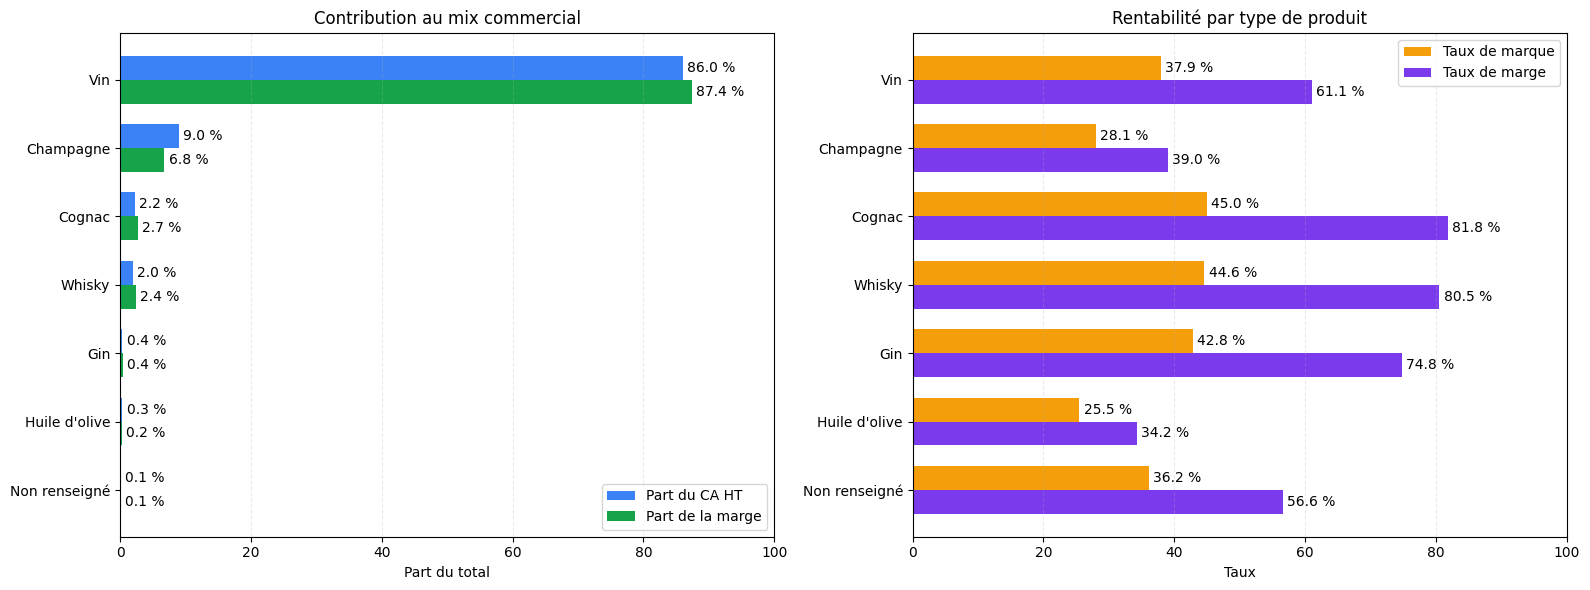

In [74]:
# Agrégation par type de produit
df_marge["product_type_analysis"] = df_marge["product_type"].fillna("Non renseigné")

marge_par_type = (df_marge.groupby("product_type_analysis", as_index=False)
    .agg(nombre_produits=("product_id", "nunique"),
         quantites_vendues=("total_sales_analysis", "sum"),
         ca_ht=("ca_ht_estime", "sum"),
         cout_achat=("cout_ventes_octobre", "sum"),
         marge_brute=("marge_brute_estimee", "sum")))

marge_par_type["taux_marque"] = marge_par_type["marge_brute"] / marge_par_type["ca_ht"]
marge_par_type["taux_marge"] = marge_par_type["marge_brute"] / marge_par_type["cout_achat"]
marge_par_type["part_ca_ht"] = marge_par_type["ca_ht"] / marge_par_type["ca_ht"].sum()
marge_par_type["part_marge_brute"] = (
    marge_par_type["marge_brute"] / marge_par_type["marge_brute"].sum())
marge_par_type = marge_par_type.sort_values("marge_brute", ascending=False).reset_index(drop=True)

table_mix = marge_par_type.rename(columns={
    "product_type_analysis": "Type de produit",
    "nombre_produits": "Produits vendus",
    "quantites_vendues": "Quantités vendues",
    "ca_ht": "CA HT",
    "cout_achat": "Coût d’achat",
    "marge_brute": "Marge brute",
    "taux_marque": "Taux de marque",
    "taux_marge": "Taux de marge",
    "part_ca_ht": "Part du CA HT",
    "part_marge_brute": "Part de la marge"})

display(table_mix.style.format({
    "Produits vendus": fmt_nombre,
    "Quantités vendues": fmt_nombre,
    "CA HT": fmt_euro,
    "Coût d’achat": fmt_euro,
    "Marge brute": fmt_euro,
    "Taux de marque": "{:.2%}",
    "Taux de marge": "{:.2%}",
    "Part du CA HT": "{:.2%}",
    "Part de la marge": "{:.2%}"}).hide(axis="index"))

# Comparaison visuelle du mix et des taux
categories = marge_par_type["product_type_analysis"]
y = np.arange(len(categories))
hauteur = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

barres_ca = axes[0].barh(
    y - hauteur / 2, marge_par_type["part_ca_ht"] * 100,
    height=hauteur, color="#3B82F6", label="Part du CA HT")
barres_marge = axes[0].barh(
    y + hauteur / 2, marge_par_type["part_marge_brute"] * 100,
    height=hauteur, color="#16A34A", label="Part de la marge")
axes[0].bar_label(barres_ca, fmt="%.1f %%", padding=3)
axes[0].bar_label(barres_marge, fmt="%.1f %%", padding=3)
axes[0].set_title("Contribution au mix commercial")
axes[0].set_xlabel("Part du total")
axes[0].set_yticks(y, categories)
axes[0].set_xlim(0, 100)
axes[0].invert_yaxis()
axes[0].legend()

barres_marque = axes[1].barh(
    y - hauteur / 2, marge_par_type["taux_marque"] * 100,
    height=hauteur, color="#F59E0B", label="Taux de marque")
barres_taux_marge = axes[1].barh(
    y + hauteur / 2, marge_par_type["taux_marge"] * 100,
    height=hauteur, color="#7C3AED", label="Taux de marge")
axes[1].bar_label(barres_marque, fmt="%.1f %%", padding=3)
axes[1].bar_label(barres_taux_marge, fmt="%.1f %%", padding=3)
axes[1].set_title("Rentabilité par type de produit")
axes[1].set_xlabel("Taux")
axes[1].set_yticks(y, categories)
axes[1].set_xlim(0, 100)
axes[1].invert_yaxis()
axes[1].legend()

for ax in axes:
    ax.grid(axis="x", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

In [75]:
articles_sans_categorie = df_final.loc[
    df_final["product_type"].isna() | df_final["product_type"].astype("string").str.strip().eq(""),
    ["product_id", "sku_analysis", "post_title_display", "total_sales_analysis"]].sort_values("total_sales_analysis", ascending=False)

print(f"Articles sans catégorie : {len(articles_sans_categorie)}")
display(articles_sans_categorie)

Articles sans catégorie : 1


,product_id,sku_analysis,post_title_display,total_sales_analysis
410,4954,bon-cadeau-25-euros,Bon cadeau de 25€,7.0


#### Interprétation de la marge et du mix

La catégorie **Vin** constitue le principal moteur économique de BottleNeck. Elle représente **85,97 % du chiffre d’affaires HT** et génère **87,41 % de la marge brute totale**.

Son taux de marque de **37,92 %** et son taux de marge de **61,09 %** sont légèrement supérieurs aux indicateurs globaux. La rentabilité globale de l’entreprise dépend donc fortement de cette catégorie.

Le **Champagne** constitue la deuxième catégorie en valeur, avec **9,00 % du CA HT**, mais seulement **6,77 % de la marge brute**. Ses taux de marque de **28,07 %** et de marge de **39,02 %** sont inférieurs aux résultats globaux. Cette catégorie exerce donc un effet défavorable sur le taux de marge global.

Cette observation doit être rapprochée de l’analyse des stocks : plusieurs références présentant les niveaux les plus élevés de capital immobilisé sont des Champagnes. La catégorie combine ainsi une rentabilité relative plus faible et un risque de rotation lente sur certaines références.

Le **Cognac**, le **Whisky** et le **Gin** présentent les taux de marge les plus élevés, compris entre **74,83 % et 81,82 %**. Leur contribution à la marge reste néanmoins limitée en raison de leur faible poids dans le mix commercial.

Ces catégories pourraient constituer des pistes de développement, sous réserve d’une validation de la demande, du positionnement commercial, des volumes disponibles et des contraintes de stock.

La catégorie non renseignée correspond à une référence vendue dont le type de produit doit être complété dans le système Web.

L’analyse repose uniquement sur le mois d’octobre. Une recommandation définitive sur l’évolution du mix nécessiterait une comparaison avec d’autres périodes afin d’intégrer la saisonnalité et l’évolution de la demande.

> **Point de vigilance :** la catégorie « Non renseigné » présente des taux de rentabilité apparemment satisfaisants, mais elle ne représente qu’un seul produit, 7 unités vendues et 52,73 € de marge brute, soit 0,12 % de la marge totale. Il s’agit du bon cadeau de 25 €, dont la catégorisation et le traitement métier doivent être validés. Ces taux ne doivent donc pas être interprétés comme un levier significatif du mix commercial.

### 5.5 – Analyse des corrélations quantitatives

Cette section étudie les relations entre quatre variables quantitatives directement observées : le prix de vente TTC, le prix d’achat, le stock et les ventes d’octobre.

Deux méthodes sont comparées :

- **Pearson**, qui mesure l’intensité d’une relation linéaire, mais reste sensible aux valeurs extrêmes et aux distributions asymétriques ;
- **Spearman**, fondé sur le rang des observations, qui mesure une relation monotone et présente une meilleure robustesse face aux valeurs extrêmes.

L’objectif est de vérifier si les conclusions varient selon la méthode utilisée et de sélectionner l’approche la plus adaptée aux caractéristiques des données BottleNeck. Une corrélation met en évidence une association statistique, mais ne démontre pas une relation de causalité.

Observations communes analysées : 713


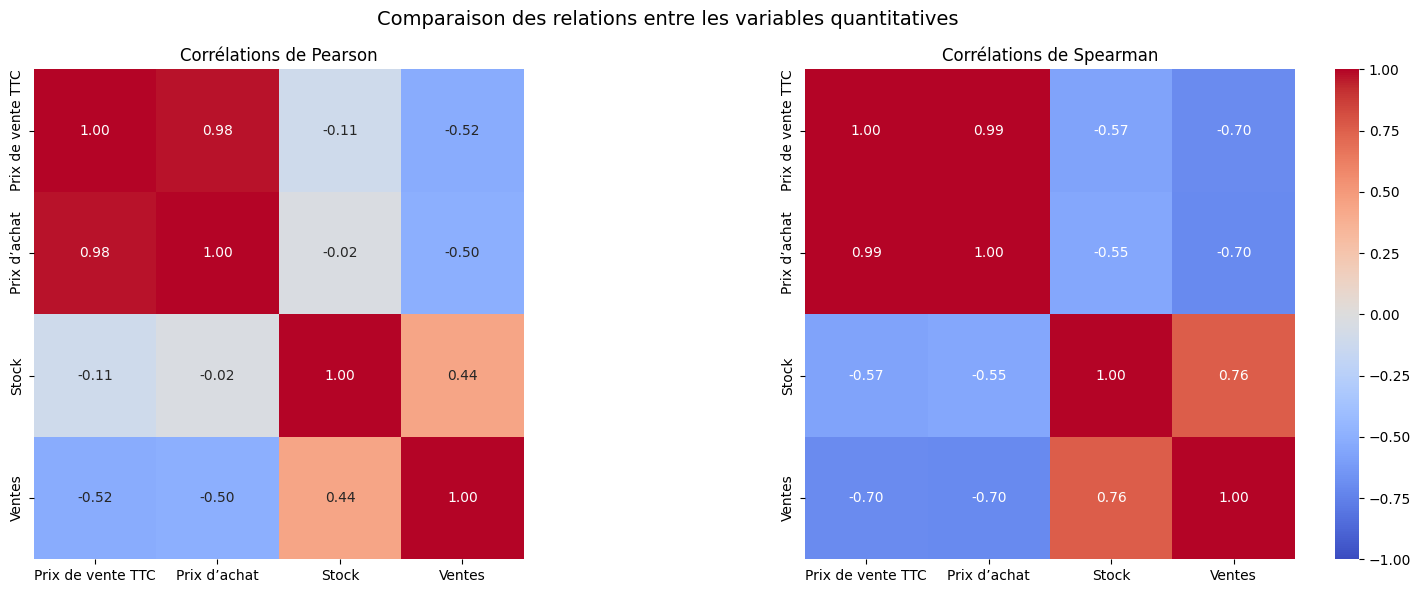

In [76]:
# Base commune aux deux méthodes
variables_correlation = {
    "price_analysis": "Prix de vente TTC",
    "purchase_price_analysis": "Prix d’achat",
    "stock_quantity_analysis": "Stock",
    "total_sales_analysis": "Ventes"}

df_correlation = (df_final[list(variables_correlation)]
    .rename(columns=variables_correlation)
    .apply(pd.to_numeric, errors="coerce")
    .dropna())

corr_pearson = df_correlation.corr(method="pearson")
corr_spearman = df_correlation.corr(method="spearman")

print(f"Observations communes analysées : {len(df_correlation)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True, cbar=False, ax=axes[0])
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True, ax=axes[1])

axes[0].set_title("Corrélations de Pearson")
axes[1].set_title("Corrélations de Spearman")
plt.suptitle("Comparaison des relations entre les variables quantitatives", fontsize=14)
plt.tight_layout()
plt.show()

In [77]:
# Comparaison des coefficients par relation
paires = [
    ("Prix de vente TTC", "Prix d’achat"),
    ("Prix de vente TTC", "Stock"),
    ("Prix de vente TTC", "Ventes"),
    ("Prix d’achat", "Stock"),
    ("Prix d’achat", "Ventes"),
    ("Stock", "Ventes")]

comparaison_correlation = pd.DataFrame([{
    "relation": f"{a} ↔ {b}",
    "Pearson": corr_pearson.loc[a, b],
    "Spearman": corr_spearman.loc[a, b],
    "écart_absolu": abs(corr_spearman.loc[a, b] - corr_pearson.loc[a, b])}
    for a, b in paires])

comparaison_correlation["interprétation_Spearman"] = np.select(
    [comparaison_correlation["Spearman"] >= 0.7,
     comparaison_correlation["Spearman"] >= 0.5,
     comparaison_correlation["Spearman"] <= -0.7,
     comparaison_correlation["Spearman"] <= -0.5],
    ["relation positive forte", "relation positive modérée",
     "relation négative forte", "relation négative modérée"],
    default="relation faible")

display(comparaison_correlation.style
    .format({"Pearson": "{:.2f}", "Spearman": "{:.2f}", "écart_absolu": "{:.2f}"})
    .hide(axis="index"))

relation,Pearson,Spearman,écart_absolu,interprétation_Spearman
Prix de vente TTC ↔ Prix d’achat,0.98,0.99,0.02,relation positive forte
Prix de vente TTC ↔ Stock,-0.11,-0.57,0.47,relation négative modérée
Prix de vente TTC ↔ Ventes,-0.52,-0.70,0.19,relation négative forte
Prix d’achat ↔ Stock,-0.02,-0.55,0.53,relation négative modérée
Prix d’achat ↔ Ventes,-0.50,-0.70,0.20,relation négative forte
Stock ↔ Ventes,0.44,0.76,0.32,relation positive forte


In [78]:
comparaison_methodes_correlation = pd.DataFrame([
    ["Qualité et adaptation", "Mesure les relations linéaires.", "Mesure les relations monotones à partir des rangs.", "Avantage Spearman pour ces distributions asymétriques."],
    ["Robustesse et biais", "Sensible aux valeurs extrêmes.", "Moins influencé par les valeurs extrêmes.", "Spearman limite l’influence des produits atypiques."],
    ["Résultats observés", "Relations plus faibles pour le stock et les ventes.", "Relations plus fortes et cohérentes avec les classements observés.", "Spearman révèle une structure partiellement non linéaire."],
    ["Temps de calcul", "Négligeable sur 713 observations.", "Négligeable sur 713 observations.", "Différence non significative."],
    ["Reproductibilité", "Méthode déterministe.", "Méthode déterministe.", "Les deux méthodes sont reproductibles."],
    ["Maintenabilité", "Disponible directement dans Pandas.", "Disponible directement dans Pandas.", "Les deux méthodes sont simples à maintenir."],
    ["Sécurité et conformité", "Calcul local sans transmission de données.", "Calcul local sans transmission de données.", "Niveau équivalent."],
    ["Sobriété", "Coût de calcul négligeable.", "Coût de calcul négligeable.", "Impact comparable et limité."]],
    columns=["critère", "Pearson", "Spearman", "évaluation"])

display(comparaison_methodes_correlation.style
    .set_properties(subset=["Pearson", "Spearman", "évaluation"],
                    **{"min-width": "260px", "max-width": "380px", "white-space": "normal", "text-align": "left"})
    .set_properties(subset=["critère"], **{"font-weight": "bold", "text-align": "left"})
    .hide(axis="index"))

critère,Pearson,Spearman,évaluation
Qualité et adaptation,Mesure les relations linéaires.,Mesure les relations monotones à partir des rangs.,Avantage Spearman pour ces distributions asymétriques.
Robustesse et biais,Sensible aux valeurs extrêmes.,Moins influencé par les valeurs extrêmes.,Spearman limite l’influence des produits atypiques.
Résultats observés,Relations plus faibles pour le stock et les ventes.,Relations plus fortes et cohérentes avec les classements observés.,Spearman révèle une structure partiellement non linéaire.
Temps de calcul,Négligeable sur 713 observations.,Négligeable sur 713 observations.,Différence non significative.
Reproductibilité,Méthode déterministe.,Méthode déterministe.,Les deux méthodes sont reproductibles.
Maintenabilité,Disponible directement dans Pandas.,Disponible directement dans Pandas.,Les deux méthodes sont simples à maintenir.
Sécurité et conformité,Calcul local sans transmission de données.,Calcul local sans transmission de données.,Niveau équivalent.
Sobriété,Coût de calcul négligeable.,Coût de calcul négligeable.,Impact comparable et limité.


#### 5.5.1 – Interprétation et décision méthodologique

Les écarts observés entre Pearson et Spearman indiquent que plusieurs relations sont **monotones, mais pas strictement linéaires**. Les distributions asymétriques et les produits présentant des prix, stocks ou volumes atypiques réduisent notamment la capacité de Pearson à représenter certaines relations.

Les principaux résultats de Spearman sont les suivants :

- **Prix de vente et prix d’achat (0,99) :** les deux variables évoluent presque dans le même ordre. Les produits dont le coût d’achat est élevé sont généralement vendus plus cher. Cette relation ne suffit cependant pas à valider individuellement les prix ou les marges.
- **Prix de vente et ventes (-0,70) :** les produits les plus chers tendent à enregistrer des volumes de ventes plus faibles.
- **Prix d’achat et ventes (-0,70) :** les produits les plus coûteux tendent également à être moins vendus.
- **Stock et ventes (0,76) :** les références les plus vendues tendent à présenter les niveaux de stock les plus élevés, ce qui peut refléter une adaptation du stock à la demande.
- **Prix et stock (-0,57) :** les produits les moins chers tendent à être stockés en plus grandes quantités, probablement en lien avec leur rotation plus élevée.

La corrélation entre stock et ventes doit toutefois être interprétée avec prudence : le stock correspond à une situation au 31 octobre, tandis que les ventes couvrent l’ensemble du mois. Les stocks initiaux et les éventuels réapprovisionnements ne sont pas disponibles.

##### Décision méthodologique

La méthode de **Spearman est retenue comme méthode principale**, car elle est mieux adaptée aux distributions asymétriques et moins sensible aux valeurs extrêmes. Pearson est conservé comme méthode complémentaire afin d’évaluer la composante linéaire des relations.

Ces résultats mettent en évidence des associations statistiques, mais ne démontrent aucune causalité. L’analyse reste également limitée à un seul mois d’activité.

### 5.6 – POC de prédiction du volume mensuel des ventes

#### 5.6.1 – Objectif et cadre de l’expérimentation

Ce POC vise à évaluer la possibilité d’estimer la quantité mensuelle vendue par produit (`total_sales_analysis`) à partir des caractéristiques disponibles dans les fichiers ERP et Web.

Quatre approches seront comparées :

- un modèle naïf servant de référence ;
- une régression linéaire, simple et directement interprétable ;
- une régression de Poisson, adaptée à une cible de comptage non négative ;
- un modèle non linéaire capable de représenter des relations plus complexes.

Les performances seront évaluées par validation croisée à l’aide du MAE, du RMSE et du coefficient de détermination R².

Les données disponibles couvrant uniquement le mois d’octobre, cette expérimentation constitue un **POC de prédiction exploratoire** et non un système opérationnel de prévision des ventes futures.


#### 5.6.2 – Préparation de la base de modélisation

Une base spécifique est créée à partir de la base analytique finale. Cette copie permet de préparer les variables nécessaires au POC sans modifier les données destinées à l’export.

La quantité vendue en octobre constitue la variable cible. Le prix de vente, le prix d’achat et le type de produit sont retenus comme variables explicatives principales. Le stock de fin de mois est conservé séparément afin d’évaluer ultérieurement le risque de fuite de données.

In [79]:
# Création d’une base indépendante pour le POC prédictif
colonnes_modelisation = [
    "product_id", "price_analysis", "purchase_price_analysis",
    "stock_quantity_analysis", "product_type", "total_sales_analysis"]

df_modelisation = df_final[colonnes_modelisation].copy()
df_modelisation["product_type_model"] = (
    df_modelisation["product_type"].fillna("Non renseigné").astype("string"))

df_modelisation = df_modelisation.dropna(
    subset=["price_analysis", "purchase_price_analysis", "total_sales_analysis"])
df_modelisation = df_modelisation[
    df_modelisation["total_sales_analysis"].ge(0)].reset_index(drop=True)

print(
    f"Base de modélisation : {len(df_modelisation)} produits × "
    f"{df_modelisation.shape[1]} variables")
print("Cible :", "total_sales_analysis")
print("Quantité moyenne vendue par produit :", round(df_modelisation["total_sales_analysis"].mean(), 2), "unités")
print("Quantité médiane vendue par produit :", round(df_modelisation["total_sales_analysis"].median(), 2), "unités")

display(df_modelisation.head())

Base de modélisation : 714 produits × 7 variables
Cible : total_sales_analysis
Quantité moyenne vendue par produit : 8.05 unités
Quantité médiane vendue par produit : 8.0 unités


,product_id,price_analysis,purchase_price_analysis,stock_quantity_analysis,product_type,total_sales_analysis,product_type_model
0,3847,24.2,12.88,16.0,Vin,6.0,Vin
1,3849,34.3,17.54,10.0,Vin,9.0,Vin
2,3850,20.8,10.64,0.0,Vin,0.0,Vin
3,4032,14.1,6.92,26.0,Vin,12.0,Vin
4,4039,46.0,23.77,3.0,Vin,3.0,Vin


#### 5.6.3 – Définition des scénarios et stratégie de validation

Deux scénarios de modélisation sont étudiés :

- **scénario principal sans stock** : prix de vente, prix d’achat et type de produit ;
- **scénario de sensibilité avec stock** : ajout du stock disponible au 31 octobre.

Le second scénario permettra de mesurer l’apport apparent du stock, mais aussi d’évaluer le risque de fuite de données, puisque le stock de fin de mois a déjà été influencé par les ventes d’octobre.

Le `product_id` est conservé comme identifiant, mais n’est pas utilisé comme variable prédictive. Les performances seront estimées par validation croisée en cinq partitions avec un ordre aléatoire reproductible (`random_state=42`).

In [80]:
# Définition de la cible et des deux scénarios
cible = "total_sales_analysis"
variables_sans_stock = ["price_analysis", "purchase_price_analysis", "product_type_model"]
variables_avec_stock = variables_sans_stock + ["stock_quantity_analysis"]

X_sans_stock = df_modelisation[variables_sans_stock]
X_avec_stock = df_modelisation[variables_avec_stock]
y = df_modelisation[cible]

validation_croisee = KFold(n_splits=5, shuffle=True, random_state=42)

print("Observations :", len(y))
print("Scénario principal :", variables_sans_stock)
print("Scénario de sensibilité :", variables_avec_stock)
print("Validation croisée :", validation_croisee.get_n_splits(), "partitions")

Observations : 714
Scénario principal : ['price_analysis', 'purchase_price_analysis', 'product_type_model']
Scénario de sensibilité : ['price_analysis', 'purchase_price_analysis', 'product_type_model', 'stock_quantity_analysis']
Validation croisée : 5 partitions


#### 5.6.4 – Prétraitement et modèles comparés

Les variables numériques sont complétées par la médiane en cas de valeur manquante, puis standardisées. Le type de produit est transformé en variables indicatrices par encodage One-Hot.

Le prétraitement est intégré à chaque pipeline afin qu’il soit recalculé uniquement sur les données d’apprentissage de chaque partition et d’éviter une fuite d’information pendant la validation croisée.

Quatre modèles sont comparés :

- **Dummy Regressor** : référence naïve prédisant la moyenne des ventes ;
- **Régression linéaire** : modèle additif simple, utile comme comparaison interprétable mais pouvant produire des valeurs négatives ;
- **Régression de Poisson** : modèle adapté à une cible constituée de quantités non négatives ;
- **Random Forest Regressor** : modèle non linéaire capable de représenter des interactions plus complexes.


In [81]:
# Fonction de prétraitement commune aux modèles
def creer_preprocesseur(variables_numeriques):
    traitement_numerique = Pipeline([
        ("imputation", SimpleImputer(strategy="median")),
        ("standardisation", StandardScaler())])
    
    traitement_categoriel = Pipeline([
        ("imputation", SimpleImputer(strategy="most_frequent")),
        ("encodage", OneHotEncoder(handle_unknown="ignore"))])
    
    return ColumnTransformer([
        ("numeriques", traitement_numerique, variables_numeriques),
        ("categorie", traitement_categoriel, ["product_type_model"])])

# Modèles comparés
modeles = {
    "Référence naïve": DummyRegressor(strategy="mean"),
    "Régression linéaire": LinearRegression(),
    "Régression de Poisson": PoissonRegressor(alpha=1.0, max_iter=2000),
    "Forêt aléatoire": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1)}

print("Modèles comparés :", ", ".join(modeles))

Modèles comparés : Référence naïve, Régression linéaire, Régression de Poisson, Forêt aléatoire


#### 5.6.5 – Évaluation du scénario principal sans stock

Le premier scénario utilise uniquement les informations pouvant être considérées comme indépendantes du niveau de stock constaté à la fin du mois.

Les modèles sont comparés selon quatre éléments :

- **MAE** : erreur absolue moyenne exprimée en unités vendues — plus elle est faible, meilleur est le modèle ;
- **RMSE** : erreur donnant davantage de poids aux écarts importants — plus elle est faible, meilleur est le modèle ;
- **R²** : part de la variabilité des ventes expliquée — plus il est élevé, meilleur est le modèle ;
- **temps d’entraînement** : indicateur de coût de calcul et de sobriété.

In [82]:
# Fonction d’évaluation commune
def evaluer_modeles(X, variables_numeriques):
    resultats = []
    criteres = {
        "mae": "neg_mean_absolute_error",
        "mse": "neg_mean_squared_error",
        "r2": "r2"}
    
    for nom, modele in modeles.items():
        pipeline = Pipeline([
            ("pretraitement", creer_preprocesseur(variables_numeriques)),
            ("modele", modele)])
        
        scores = cross_validate(
            pipeline, X, y, cv=validation_croisee, scoring=criteres)
        
        resultats.append({
            "Modèle": nom,
            "MAE moyenne": -scores["test_mae"].mean(),
            "RMSE moyenne": np.sqrt(-scores["test_mse"]).mean(),
            "R² moyen": scores["test_r2"].mean(),
            "Écart-type R²": scores["test_r2"].std(),
            "Temps moyen (s)": scores["fit_time"].mean()})
    
    return pd.DataFrame(resultats).sort_values(
        "MAE moyenne").reset_index(drop=True)

# Évaluation sans le stock de fin de mois
resultats_sans_stock = evaluer_modeles(
    X_sans_stock,
    ["price_analysis", "purchase_price_analysis"])

display(resultats_sans_stock.style.format({
    "MAE moyenne": "{:.2f}",
    "RMSE moyenne": "{:.2f}",
    "R² moyen": "{:.2f}",
    "Écart-type R²": "{:.2f}",
    "Temps moyen (s)": "{:.3f}"}).hide(axis="index"))

Modèle,MAE moyenne,RMSE moyenne,R² moyen,Écart-type R²,Temps moyen (s)
Régression de Poisson,2.46,3.31,0.36,0.04,0.056
Forêt aléatoire,2.52,3.46,0.29,0.07,0.608
Régression linéaire,2.74,4.09,-0.08,0.61,0.023
Référence naïve,3.26,4.15,-0.01,0.01,0.027


**Lecture intermédiaire.**  
Sans utiliser le stock de fin de mois, la régression de Poisson obtient les meilleures performances : MAE de 2,46 unités, RMSE de 3,31 unités et R² moyen de 0,36. Elle réduit ainsi le MAE d’environ 24,5 % par rapport à la référence naïve, dont le MAE atteint 3,26 unités.

La forêt aléatoire améliore également la référence, mais reste moins performante et légèrement moins stable que la régression de Poisson. La régression linéaire obtient un MAE de 2,74 unités, mais son RMSE atteint 4,09 et son R² moyen est négatif (−0,08), avec une forte variabilité entre les partitions. Cette divergence montre que quelques erreurs importantes dégradent fortement sa performance globale.

À ce stade, le modèle de Poisson constitue donc l’option principale, tout en conservant un pouvoir explicatif modéré.


##### Diagnostic complémentaire de la régression linéaire

La régression linéaire est examinée au-delà des métriques moyennes afin de vérifier si ses prédictions respectent la nature non négative des quantités vendues. Les prédictions sont produites hors échantillon avec les cinq mêmes partitions que celles utilisées pour comparer les modèles.


In [83]:
# Prédictions hors échantillon de la régression linéaire sans stock
modele_lineaire = Pipeline([
    ("pretraitement", creer_preprocesseur(["price_analysis", "purchase_price_analysis"])),
    ("modele", LinearRegression())])

predictions_lineaires_cv = cross_val_predict(
    modele_lineaire, X_sans_stock, y, cv=validation_croisee)

diagnostic_lineaire = pd.DataFrame({
    "Indicateur": [
        "Prédictions négatives",
        "Prédiction minimale",
        "Prédiction maximale",
        "Vente observée maximale"],
    "Valeur": [
        f"{(predictions_lineaires_cv < 0).sum()} produits",
        f"{predictions_lineaires_cv.min():.2f} unités",
        f"{predictions_lineaires_cv.max():.2f} unités",
        f"{y.max():.0f} unités"]})

display(diagnostic_lineaire.style.hide(axis="index"))


Indicateur,Valeur
Prédictions négatives,10 produits
Prédiction minimale,-10.16 unités
Prédiction maximale,54.06 unités
Vente observée maximale,36 unités


**Interprétation.** La régression linéaire produit **10 prédictions négatives**, avec un minimum de **−10,16 unités**, alors qu’une quantité vendue ne peut pas être négative. Elle atteint également **54,06 unités prédites**, contre un maximum observé de **36 unités**. Ces erreurs extrêmes expliquent son RMSE élevé et son R² moyen négatif.

La régression linéaire est donc conservée comme comparaison pédagogique, mais elle n’est pas retenue. La régression de Poisson reste plus cohérente pour une cible de comptage, car elle garantit des prédictions non négatives et obtient de meilleures performances en validation croisée.


#### 5.6.6 – Scénario de sensibilité avec le stock de fin de mois

Le même protocole est réexécuté en ajoutant le stock disponible au 31 octobre. Cette comparaison vise à mesurer l’amélioration apparente des performances et à déterminer si elle repose sur une information réellement disponible au moment de la prédiction.

Le stock manquant est imputé par la médiane à l’intérieur du pipeline. Les autres paramètres, modèles et partitions de validation restent identiques afin de garantir une comparaison équitable.

In [84]:
# Évaluation avec ajout du stock de fin de mois
resultats_avec_stock = evaluer_modeles(X_avec_stock, ["price_analysis", "purchase_price_analysis", "stock_quantity_analysis"])

display(resultats_avec_stock.style.format({
    "MAE moyenne": "{:.2f}",
    "RMSE moyenne": "{:.2f}",
    "R² moyen": "{:.2f}",
    "Écart-type R²": "{:.2f}",
    "Temps moyen (s)": "{:.3f}"}).hide(axis="index"))

Modèle,MAE moyenne,RMSE moyenne,R² moyen,Écart-type R²,Temps moyen (s)
Forêt aléatoire,1.45,2.25,0.70,0.06,0.574
Régression linéaire,1.84,3.25,0.29,0.44,0.016
Régression de Poisson,2.05,2.76,0.55,0.04,0.022
Référence naïve,3.26,4.15,-0.01,0.01,0.014


#### 5.6.7 – Comparaison des scénarios et décision

L’ajout du stock de fin de mois améliore fortement les performances, particulièrement pour la forêt aléatoire. Cependant, cette information n’aurait pas été disponible au moment d’une prédiction réalisée avant ou pendant le mois d’octobre.

Le scénario avec stock présente donc un risque de **fuite temporelle de données** : le modèle utilise une variable mesurée après les événements qu’il cherche à prédire. Il est conservé comme test de sensibilité, mais écarté du modèle principal.

La régression de Poisson sans stock est retenue pour le POC. Elle est moins performante que la variante avec stock, mais repose sur des variables compatibles avec une utilisation prédictive et améliore nettement la référence naïve.

Scénario,Meilleur modèle,MAE,RMSE,R²,Décision
Sans stock,Régression de Poisson,2.46,3.31,0.36,Retenu pour le POC
Avec stock,Forêt aléatoire,1.45,2.25,0.70,Écarté pour fuite temporelle


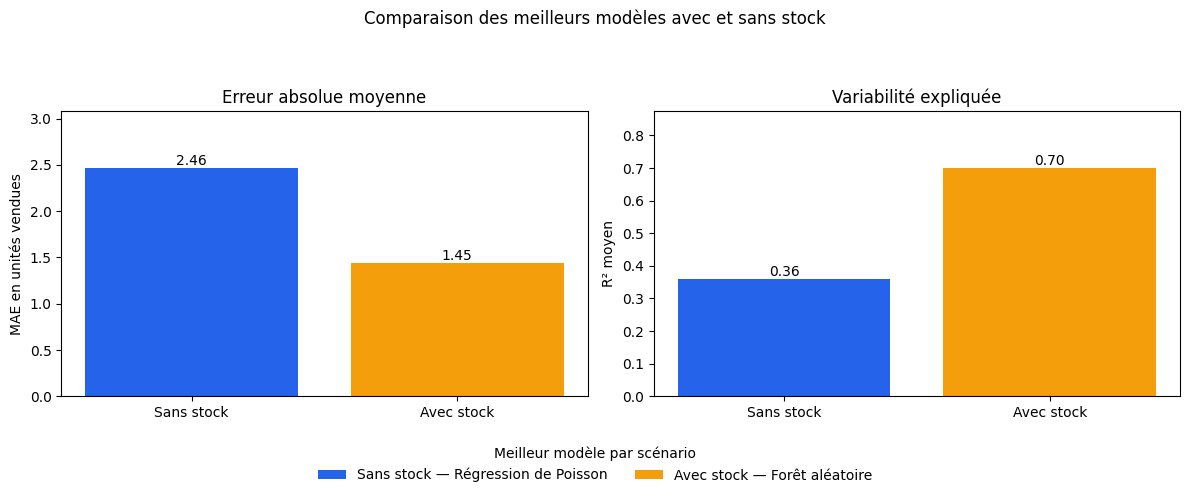

In [85]:
# Synthèse des meilleurs résultats de chaque scénario
meilleur_sans_stock = resultats_sans_stock.iloc[0]
meilleur_avec_stock = resultats_avec_stock.iloc[0]

comparaison_scenarios = pd.DataFrame([
    {   "Scénario": "Sans stock",
        "Meilleur modèle": meilleur_sans_stock["Modèle"],
        "MAE": meilleur_sans_stock["MAE moyenne"],
        "RMSE": meilleur_sans_stock["RMSE moyenne"],
        "R²": meilleur_sans_stock["R² moyen"],
        "Décision": "Retenu pour le POC"},

    {   "Scénario": "Avec stock",
        "Meilleur modèle": meilleur_avec_stock["Modèle"],
        "MAE": meilleur_avec_stock["MAE moyenne"],
        "RMSE": meilleur_avec_stock["RMSE moyenne"],
        "R²": meilleur_avec_stock["R² moyen"],
        "Décision": "Écarté pour fuite temporelle"}])

display(comparaison_scenarios.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R²": "{:.2f}"}).hide(axis="index"))

# Comparaison visuelle
couleurs = ["#2563EB", "#F59E0B"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

barres_mae = axes[0].bar(comparaison_scenarios["Scénario"], comparaison_scenarios["MAE"], color=couleurs)

axes[0].bar_label(barres_mae, fmt="%.2f")
axes[0].set_title("Erreur absolue moyenne")
axes[0].set_ylabel("MAE en unités vendues")
axes[0].set_ylim(0, comparaison_scenarios["MAE"].max() * 1.25)

barres_r2 = axes[1].bar(comparaison_scenarios["Scénario"], comparaison_scenarios["R²"], color=couleurs)

axes[1].bar_label(barres_r2, fmt="%.2f")
axes[1].set_title("Variabilité expliquée")
axes[1].set_ylabel("R² moyen")
axes[1].set_ylim(0, comparaison_scenarios["R²"].max() * 1.25)

labels_legende = (comparaison_scenarios["Scénario"] + " — " + comparaison_scenarios["Meilleur modèle"]).tolist()

fig.legend(
    handles=[barres_mae[0], barres_mae[1]],
    labels=labels_legende,
    title="Meilleur modèle par scénario",
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01))

fig.suptitle("Comparaison des meilleurs modèles avec et sans stock", y=0.98)

plt.tight_layout(rect=[0, 0.13, 1, 0.92])
plt.show()

#### 5.6.8 – Prédictions hors échantillon du modèle retenu

Des prédictions hors échantillon sont générées par validation croisée. Chaque produit est ainsi prédit par un modèle qui n’a pas été entraîné sur cette observation, ce qui évite de présenter comme performance prédictive un résultat obtenu sur les données d’apprentissage.

La comparaison entre quantités observées et prédites permet d’identifier la précision globale du modèle, ses erreurs importantes et ses éventuels biais.

Indicateur,Valeur,Interprétation
MAE,2.46,Erreur absolue moyenne en unités
RMSE,3.33,Erreur pénalisant davantage les grands écarts
R²,0.36,Part de la variabilité expliquée


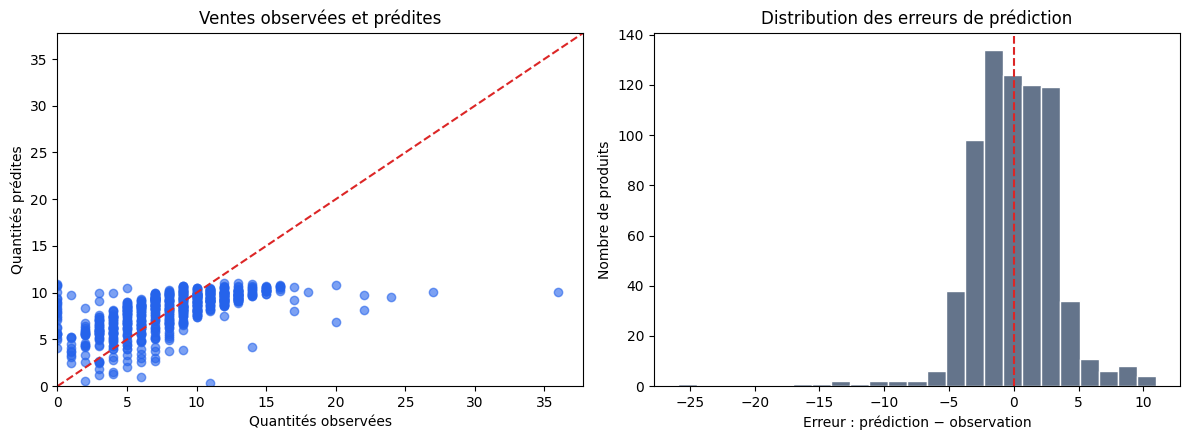

In [86]:
# Pipeline retenu : régression de Poisson sans stock
modele_retenu = Pipeline([("pretraitement", creer_preprocesseur(["price_analysis", "purchase_price_analysis"])),
    ("modele", PoissonRegressor(alpha=1.0, max_iter=2000))])

# Prédictions hors échantillon avec validation croisée
predictions_cv = cross_val_predict(modele_retenu, X_sans_stock, y, cv=validation_croisee)

# Métriques globales
mae_cv = mean_absolute_error(y, predictions_cv)

rmse_cv = np.sqrt(mean_squared_error(y, predictions_cv))
r2_cv = r2_score(y, predictions_cv)

# Tableau récapitulatif des performances
resume_prediction = pd.DataFrame({"Indicateur": ["MAE", "RMSE", "R²"],
    "Valeur": [mae_cv, rmse_cv, r2_cv],
    "Interprétation": [
        "Erreur absolue moyenne en unités",
        "Erreur pénalisant davantage les grands écarts",
        "Part de la variabilité expliquée"]})

display(resume_prediction.style.format({"Valeur": "{:.2f}"}).hide(axis="index"))

# Comparaison entre observations et prédictions
erreurs_cv = predictions_cv - y.to_numpy()

limite = max(y.max(), predictions_cv.max()) * 1.05

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Ventes observées et prédites
axes[0].scatter(y, predictions_cv, alpha=0.6, color="#2563EB")
axes[0].plot([0, limite], [0, limite], "--", color="#DC2626")
axes[0].set_xlim(0, limite)
axes[0].set_ylim(0, limite)
axes[0].set_title("Ventes observées et prédites")
axes[0].set_xlabel("Quantités observées")
axes[0].set_ylabel("Quantités prédites")

# Distribution des erreurs
axes[1].hist(erreurs_cv, bins=25, color="#64748B", edgecolor="white")
axes[1].axvline(0, linestyle="--", color="#DC2626")
axes[1].set_title("Distribution des erreurs de prédiction")
axes[1].set_xlabel("Erreur : prédiction − observation")
axes[1].set_ylabel("Nombre de produits")

plt.tight_layout()
plt.show()

#### 5.6.9 – Analyse des erreurs selon le niveau de ventes

Les erreurs sont analysées par tranche de ventes afin de vérifier si les performances sont homogènes ou si le modèle rencontre davantage de difficultés sur certains profils de produits.

In [87]:
# Tableau des prédictions hors échantillon
df_predictions_cv = df_modelisation[["product_id"]].copy()
titres_produits = df_final.set_index("product_id")["post_title_display"]

df_predictions_cv["Produit"] = df_predictions_cv["product_id"].map(titres_produits)
df_predictions_cv["Ventes observées"] = y.to_numpy()
df_predictions_cv["Ventes prédites"] = predictions_cv
df_predictions_cv["Erreur"] = predictions_cv - y.to_numpy()
df_predictions_cv["Erreur absolue"] = df_predictions_cv["Erreur"].abs()

# Analyse par tranche de ventes
df_predictions_cv["Tranche de ventes"] = pd.cut(
    df_predictions_cv["Ventes observées"],
    bins=[-0.1, 0, 5, 10, 15, np.inf],
    labels=["0", "1 à 5", "6 à 10", "11 à 15", "Plus de 15"])

synthese_erreurs = (
    df_predictions_cv.groupby("Tranche de ventes", observed=False)
    .agg(
        Produits=("product_id", "count"),
        Ventes_observées=("Ventes observées", "mean"),
        Ventes_prédites=("Ventes prédites", "mean"),
        MAE=("Erreur absolue", "mean"))
    .reset_index())

display(synthese_erreurs.style.format({
    "Ventes_observées": "{:.2f}",
    "Ventes_prédites": "{:.2f}",
    "MAE": "{:.2f}"}).hide(axis="index"))

# Dix erreurs les plus importantes
top_erreurs = (
    df_predictions_cv.nlargest(10, "Erreur absolue")
    [["product_id", "Produit", "Ventes observées",
      "Ventes prédites", "Erreur"]])

display(top_erreurs.style.format({
    "Ventes observées": "{:.0f}",
    "Ventes prédites": "{:.2f}",
    "Erreur": "{:+.2f}"}).hide(axis="index"))

Tranche de ventes,Produits,Ventes_observées,Ventes_prédites,MAE
0,25,0.00,7.66,7.66
1 à 5,174,3.64,6.01,2.64
6 à 10,322,8.05,8.24,1.38
11 à 15,175,12.42,9.63,2.79
Plus de 15,18,19.56,9.85,9.71


product_id,Produit,Ventes observées,Ventes prédites,Erreur
4867,Château De La Selve IGP Coteaux de l'Ardèche Maguelonne Rosé 2019,36,10.08,-25.92
4203,Mas Laval IGP Pays d'Hérault Les Pampres Blancs 2018,27,10.06,-16.94
4275,I Fabbri Chianti Classico Lamole 2017,24,9.56,-14.44
4647,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22,8.18,-13.82
5826,Agnès Levet Côte Rôtie Améthyste 2017,20,6.84,-13.16
4726,François Baur Pinot Noir Schlittweg 2017,22,9.81,-12.19
4923,Cave de Castelmaure Corbières Rouge Vigneron 2018,0,10.98,+10.98
4051,Jeanne Gaillard IGP Collines Rhodaniennes Syrah Terre de Mandrin 2018,0,10.86,+10.86
4198,Moulin de Gassac IGP Pays d'Hérault Guilhem Rouge 2019,0,10.75,+10.75
4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,11,0.39,-10.61


**Lecture des erreurs.**  
Le modèle est principalement performant sur les 322 produits ayant vendu entre 6 et 10 unités, pour lesquels le MAE est limité à 1,38 unité. Il surestime en revanche fortement les produits sans vente et sous-estime les références à rotation élevée.

Pour les produits ayant vendu plus de 15 unités, la moyenne observée atteint 19,56 unités contre seulement 9,85 unités prédites. Les erreurs les plus importantes concernent ainsi les produits aux comportements extrêmes.

Cette concentration des prédictions autour des volumes moyens montre que le prix, le prix d’achat et le type de produit ne suffisent pas à expliquer les différences de demande.

#### 5.6.10 – Décision, limites et pistes d’amélioration

La régression de Poisson sans stock est retenue comme résultat du POC, car elle surpasse la référence naïve, la régression linéaire et la forêt aléatoire tout en utilisant des informations compatibles avec une logique prédictive. Elle atteint un MAE de 2,46 unités et explique 36 % de la variabilité des ventes.

La régression linéaire améliore le MAE par rapport à la référence naïve, mais elle produit dix prédictions négatives, un RMSE élevé et un R² moyen négatif. Elle est conservée comme point de comparaison, mais écartée pour la cible étudiée. Le modèle de Poisson n’est toutefois pas retenu pour une utilisation opérationnelle : ses performances restent insuffisantes sur les produits sans vente et sur les références à forte rotation. La variante Random Forest avec stock obtient de meilleurs résultats, mais elle est écartée en raison d’une fuite temporelle de données.

Une future version nécessiterait plusieurs mois d’historique ainsi que des variables disponibles avant la période prédite, notamment :

- ventes historiques par produit ;
- stock au début du mois ;
- promotions et variations de prix ;
- disponibilité effective du produit ;
- saisonnalité ;
- caractéristiques détaillées des produits ;
- trafic et visibilité sur le site Web.

La validation devrait alors être réalisée chronologiquement, en entraînant les modèles sur les mois antérieurs et en évaluant leurs prédictions sur un mois ultérieur. Le POC démontre donc la faisabilité technique de la démarche, mais également les limites qui empêchent actuellement son industrialisation.


In [88]:
decision_poc = pd.DataFrame([
    ["Qualité", f"MAE de {mae_cv:.2f} unités et R² de {r2_cv:.2f}", "Amélioration mesurable mais modérée"],
    ["Biais", "Surestimation des ventes nulles et sous-estimation des fortes ventes", "Usage opérationnel écarté"],
    ["Temps", "Entraînement inférieur à une seconde par partition", "Coût de calcul négligeable"],
    ["Reproductibilité", "Pipeline et validation croisée à 5 partitions avec random_state=42", "Reproductible"],
    ["Sécurité", "Calcul local sur des données sans information personnelle", "Conforme au périmètre"],
    ["Maintenabilité", "Pipeline scikit-learn avec prétraitement intégré", "Solution simple à réexécuter"],
    ["Décision", "Régression de Poisson sans stock", "POC conservé, non industrialisé"]],
    columns=["Critère", "Évaluation", "Décision"])

display(decision_poc.style
    .set_properties(subset=["Évaluation", "Décision"], **{
        "min-width": "280px", "max-width": "420px",
        "white-space": "normal", "text-align": "left"}).set_properties(subset=["Critère"], **{"font-weight": "bold"}).hide(axis="index"))

Critère,Évaluation,Décision
Qualité,MAE de 2.46 unités et R² de 0.36,Amélioration mesurable mais modérée
Biais,Surestimation des ventes nulles et sous-estimation des fortes ventes,Usage opérationnel écarté
Temps,Entraînement inférieur à une seconde par partition,Coût de calcul négligeable
Reproductibilité,Pipeline et validation croisée à 5 partitions avec random_state=42,Reproductible
Sécurité,Calcul local sur des données sans information personnelle,Conforme au périmètre
Maintenabilité,Pipeline scikit-learn avec prétraitement intégré,Solution simple à réexécuter
Décision,Régression de Poisson sans stock,"POC conservé, non industrialisé"


##### Lecture métier des erreurs

L’analyse par tranche de ventes révèle que la performance moyenne masque des comportements très différents selon le niveau de rotation :

| Niveau de ventes | Vente observée moyenne | Prédiction moyenne | Lecture |
| --- | ---: | ---: | --- |
| Aucune vente | 0,00 | 7,66 | Forte surestimation |
| 6 à 10 unités | 8,05 | 8,24 | Performance satisfaisante |
| Plus de 15 unités | 19,56 | 9,85 | Forte sous-estimation |

Le modèle fonctionne principalement pour les références proches du niveau moyen de ventes. Il surestime les produits sans vente et sous-estime fortement les références à rotation élevée. Une utilisation pour le réapprovisionnement pourrait ainsi accroître simultanément le surstock sur les produits peu demandés et le risque de rupture sur les meilleures ventes.

#### 5.6.11 – Entraînement final et préparation des prédictions

Après la sélection de la régression de Poisson sans stock, le pipeline retenu est entraîné sur l’ensemble des 714 observations afin de constituer un modèle final réutilisable.

Les performances restent évaluées à partir des prédictions hors échantillon produites par validation croisée. Les prédictions obtenues sur les données d’apprentissage ne sont pas utilisées pour mesurer la qualité du modèle.

Le modèle final pourra être appliqué à une nouvelle période lorsque les caractéristiques des produits seront disponibles. Une véritable prévision future nécessitera cependant les données explicatives d’un nouveau mois et, idéalement, un historique mensuel.

In [89]:
# Entraînement du modèle final retenu sur l’ensemble des observations
modele_final = modele_retenu.fit(X_sans_stock, y)

# Préparation des prédictions hors échantillon pour l’export
resultats_predictions_poc = df_predictions_cv[
    ["product_id", "Produit", "Ventes observées", "Ventes prédites", "Erreur", "Erreur absolue"]].copy()

print("Modèle final :", type(modele_final.named_steps["modele"]).__name__)
print("Observations d’apprentissage :", len(y))
print("Variables prédictives :", variables_sans_stock)
print("Prédictions hors échantillon disponibles :", len(resultats_predictions_poc))

display(resultats_predictions_poc.head(10).style.format({
    "Ventes observées": "{:.0f}",
    "Ventes prédites": "{:.2f}",
    "Erreur": "{:+.2f}",
    "Erreur absolue": "{:.2f}"}).hide(axis="index"))

Modèle final : PoissonRegressor
Observations d’apprentissage : 714
Variables prédictives : ['price_analysis', 'purchase_price_analysis', 'product_type_model']
Prédictions hors échantillon disponibles : 714


product_id,Produit,Ventes observées,Ventes prédites,Erreur,Erreur absolue
3847,Pierre Jean Villa Saint-Joseph Préface 2018,6,8.48,+2.48,2.48
3849,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,9,7.48,-1.52,1.52
3850,Pierre Jean Villa Crozes-Hermitage Accroche Coeur 2018,0,8.95,+8.95,8.95
4032,Pierre Jean Villa IGP Collines Rhodaniennes Gamine 2018,12,9.70,-2.30,2.30
4039,Pierre Jean Villa Côte Rôtie Carmina 2017,3,6.45,+3.45,3.45
4040,Pierre Jean Villa Saint-Joseph Saut De l'Ange 2018,7,7.46,+0.46,0.46
4041,Pierre Gaillard Condrieu 2018,6,7.67,+1.67,1.67
4042,Pierre Gaillard Cornas 2017,8,7.87,-0.13,0.13
4043,Pierre Gaillard Côte Rôtie Esprit de Blonde 2017,0,5.56,+5.56,5.56
4045,Pierre Gaillard Côte Rôtie 2018,3,6.65,+3.65,3.65


#### 5.6.12 – Influence des variables dans la régression de Poisson

Après l’entraînement final, les coefficients de la régression de Poisson sont extraits afin d’examiner le sens et l’amplitude des associations apprises par le modèle. Pour les variables numériques standardisées, un coefficient mesure l’effet associé à une augmentation d’un écart-type, toutes choses égales par ailleurs.

Le facteur multiplicatif est calculé avec `exp(coefficient)`. Une valeur supérieure à 1 indique une association positive avec le volume estimé ; une valeur inférieure à 1 indique une association négative.


Variable,Type d’effet,Coefficient,Facteur multiplicatif,Variation associée
price_analysis,+ 1 écart-type,-0.194,0.824,-17.6 %
purchase_price_analysis,+ 1 écart-type,-0.163,0.850,-15.0 %
Type de produit : Whisky,Catégorie encodée,-0.036,0.965,-3.5 %
Type de produit : Champagne,Catégorie encodée,+0.034,1.035,+3.5 %
Type de produit : Vin,Catégorie encodée,+0.005,1.005,+0.5 %
Type de produit : Huile d'olive,Catégorie encodée,-0.004,0.996,-0.4 %
Type de produit : Cognac,Catégorie encodée,+0.003,1.003,+0.3 %
Type de produit : Non renseigné,Catégorie encodée,-0.002,0.998,-0.2 %
Type de produit : Gin,Catégorie encodée,-0.001,0.999,-0.1 %


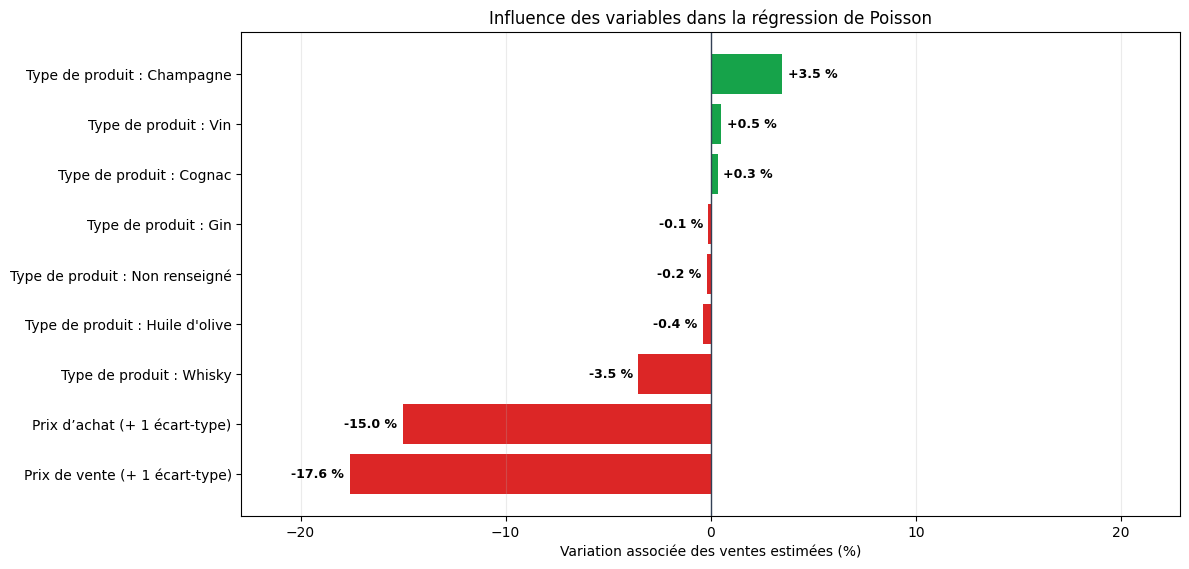

In [90]:
# Extraction et interprétation des coefficients du modèle de Poisson final
preprocesseur_final = modele_final.named_steps["pretraitement"]
regression_poisson_finale = modele_final.named_steps["modele"]

noms_variables_transformees = preprocesseur_final.get_feature_names_out()

influence_poisson = pd.DataFrame({
    "Variable technique": noms_variables_transformees,
    "Coefficient": regression_poisson_finale.coef_})

influence_poisson["Variable"] = (
    influence_poisson["Variable technique"]
    .str.replace("numeriques__", "", regex=False)
    .str.replace(
        "categorie__product_type_model_",
        "Type de produit : ",
        regex=False))

influence_poisson["Type d’effet"] = np.where(
    influence_poisson["Variable technique"].str.startswith("numeriques__"),
    "+ 1 écart-type",
    "Catégorie encodée")

influence_poisson["Facteur multiplicatif"] = np.exp(
    influence_poisson["Coefficient"])
influence_poisson["Variation associée"] = 100 * (
    influence_poisson["Facteur multiplicatif"] - 1)
influence_poisson["Influence absolue"] = influence_poisson[
    "Coefficient"].abs()

influence_poisson = influence_poisson.sort_values(
    "Influence absolue", ascending=False).reset_index(drop=True)

display(
    influence_poisson[[
        "Variable", "Type d’effet", "Coefficient",
        "Facteur multiplicatif", "Variation associée"]]
    .style
    .format({
        "Coefficient": "{:+.3f}",
        "Facteur multiplicatif": "{:.3f}",
        "Variation associée": "{:+.1f} %"})
    .hide(axis="index"))

# Visualisation de l’influence en pourcentage
influence_graphique = influence_poisson.sort_values("Variation associée")

couleurs_influence = np.where(
    influence_graphique["Variation associée"] >= 0,
    "#16A34A",
    "#DC2626")

fig, ax = plt.subplots(figsize=(12, 5.8))

libelles_affiches = {"price_analysis": "Prix de vente (+ 1 écart-type)", "purchase_price_analysis": "Prix d’achat (+ 1 écart-type)"}

influence_graphique["Variable affichée"] = (influence_graphique["Variable"].replace(libelles_affiches))

barres = ax.barh(
    influence_graphique["Variable affichée"],
    influence_graphique["Variation associée"],
    color=couleurs_influence)

ax.axvline(0, color="#334155", linewidth=1)

etiquettes = [
    f"{valeur:+.1f} %" for valeur in influence_graphique["Variation associée"]]

ax.bar_label(
    barres,
    labels=etiquettes,
    padding=4,
    fontsize=9,
    fontweight="bold")

limite = influence_graphique["Variation associée"].abs().max() * 1.30
ax.set_xlim(-limite, limite)

ax.set(
    title="Influence des variables dans la régression de Poisson",
    xlabel="Variation associée des ventes estimées (%)",
    ylabel="")

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

**Interprétation.** Une augmentation d’un écart-type du prix de vente est associée à une diminution d’environ **17,6 %** du volume estimé, toutes choses égales par ailleurs. Pour le prix d’achat, la diminution associée est d’environ **15,0 %**. Les coefficients des catégories sont beaucoup plus faibles : le Champagne présente une association positive d’environ **3,5 %**, tandis que le Whisky présente une association négative d’environ **3,5 %** dans le modèle régularisé.

Ces résultats ne démontrent pas une causalité. Les ventes ne couvrent qu’un mois, les catégories sont très déséquilibrées et le prix de vente est fortement lié au prix d’achat. Les coefficients améliorent l’interprétabilité du POC, mais ne justifient pas une utilisation opérationnelle sans historique supplémentaire.


### 5.7 – Synthèse décisionnelle et recommandations

L’analyse met en évidence une activité commercialement rentable, mais également plusieurs enjeux liés à la qualité des données, aux ruptures de stock et à l’immobilisation financière. Le POC prédictif montre par ailleurs qu’une estimation des volumes de ventes est techniquement possible, mais que les données disponibles ne permettent pas encore une utilisation opérationnelle du modèle.

#### 5.7.1 – Principaux résultats

| Axe | Indicateur | Résultat | Lecture métier |
| --- | --- | ---: | --- |
| Activité | Chiffre d’affaires TTC d’octobre | 143 680,10 € | Niveau de ventes calculé sur les 714 produits rapprochés |
| Activité | Quantités vendues | 5 751 unités | Les ventes sont réparties sur 689 produits |
| Rentabilité | Marge brute estimée | 44 660,65 € | Calcul fondé sur un prix HT estimé avec une TVA de 20 % |
| Rentabilité | Taux de marque global | 37,30 % | Part de la marge brute dans le chiffre d’affaires HT |
| Stock ERP | Valeur totale au prix d’achat | 298 627,66 € | Capital total enregistré dans l’ERP |
| Stock ERP | DOH financier estimé | 119 jours | Près de quatre mois de coût des ventes immobilisés |
| Stock rapproché | Couverture physique médiane | 2,40 mois | Situation médiane satisfaisante, mais masquant de fortes disparités |
| Surstock | Produits à risque d’immobilisation | 27 produits | Environ 109 971 € de stock sans vente ou avec plus de 12 mois de couverture |
| Ruptures | Produits vendus mais en rupture | 22 produits | Risque de ventes futures non réalisées |
| Concentration | CA généré par les 20 % premiers produits | 40,24 % | Le catalogue ne suit pas une concentration stricte de type 80/20 |
| Qualité | Prix d’achat à valider | 4 références | 11 013,56 € de stock concerné et un impact potentiel de 4,40 jours sur le DOH |
| Qualité | Anomalies consignées | 41 anomalies | 18 anomalies sont classées en priorité haute |
| Prédiction | Modèle retenu | Régression de Poisson sans stock | Modèle plus performant que la référence naïve et compatible avec une logique prédictive |
| Prédiction | Performance hors échantillon | MAE : 2,46 unités ; R² : 0,36 | Capacité prédictive modérée ; POC conservé mais non industrialisé |
| Prédiction | Variante avec stock | Random Forest ; R² : 0,70 | Meilleure performance apparente, mais modèle écarté pour fuite temporelle |
| POC prédictif | Bias selon le niveau de ventes | Prévision moyenne de 7,66 unités pour les produits sans vente et de 9,85 unités pour les produits vendus à plus de 15 unités | Le modèle surestime les faibles rotations et sous-estime les fortes rotations ; usage opérationnel non recommandé|
| Segmentation | Profils de stock et de rotation | 5 clusters | 28 produits, soit 3,9 % du catalogue analysé, concentrent 123 148,73 €, soit 44,4 % de la valeur du stock analysé ; 20 des 22 ruptures actives sont isolées dans un cluster spécifique. |*


#### 5.7.2 – Plan d’action priorisé

Les recommandations ci-dessous constituent des propositions à valider avec les responsables métier de BottleNeck. Elles intègrent les actions immédiates sur la qualité et les stocks ainsi que les conditions nécessaires à une future amélioration du modèle prédictif.

| Priorité | Horizon | Constat | Action recommandée | Responsable proposé | Indicateur de suivi |
| --- | --- | --- | --- | --- | --- |
| P1 – Critique | Immédiat | 18 anomalies de données sont classées en priorité haute | Traiter le journal des anomalies, en commençant par les prix et stocks négatifs, les incohérences de statut et les prix d’achat à valider | Référent ERP / Finance | Nombre d’anomalies hautes non résolues |
| P1 – Critique | Immédiat | 22 produits vendus sont en rupture | Prioriser le réapprovisionnement selon les ventes, le CA et la marge, notamment pour les références à forte contribution | Achats / Supply Chain | Nombre de ruptures et CA des références concernées |
| P1 – Critique | Sous 2 semaines | 3 produits actifs ne disposent pas d’identifiant Web dans la liaison | Valider les références concernées et compléter les SKU et la table de liaison | Référent Web / ERP | Taux de produits actifs correctement rapprochés |
| P2 – Élevée | Sous 1 mois | 27 produits représentent environ 109 971 € de stock à risque d’immobilisation | Examiner les achats en cours, suspendre si nécessaire les réapprovisionnements et définir des actions commerciales ciblées | Direction commerciale / Achats | Valeur du stock avec plus de 12 mois de couverture ou sans vente |
| P2 – Élevée | Sous 1 mois | Le Champagne contribue moins à la marge qu’au CA et certaines références présentent une couverture élevée | Analyser les références de Champagne par rotation, rentabilité et valeur immobilisée avant de décider des actions promotionnelles | Direction commerciale | Marge, rotation et couverture du segment Champagne |
| P2 – Élevée | Sous 1 mois | Le bon cadeau de 25 € ne possède pas de catégorie renseignée | Compléter sa classification et faire valider son traitement commercial et comptable | Référent Web / Finance | Nombre de produits sans catégorie |
| P3 – Amélioration | Mensuel | Les contrôles sont actuellement réalisés après extraction | Automatiser les contrôles de qualité lors de chaque actualisation des données | Data Analyst / Référent SI | Taux d’anomalies détectées avant production du reporting |
| P3 – Pilotage | Mensuel | Les indicateurs reposent sur une seule période | Mettre en place un suivi mensuel du CA, de la marge, des ruptures, de la couverture et du DOH | Contrôle de gestion / Direction | Tableau de bord actualisé et évolution mensuelle des KPI |
| P3 – Expérimentation | Après constitution d’un historique | Le modèle explique 36 % de la variabilité, mais surestime les ventes nulles et sous-estime les fortes ventes | Collecter plusieurs mois de ventes, les stocks initiaux, les promotions et la disponibilité des produits, puis réentraîner les modèles avec une validation temporelle | Data Analyst / Direction commerciale / SI | MAE, RMSE et R² mesurés sur un mois futur |

## 6 – Export des livrables analytiques

### 6.1 – Export de la base analytique finale

La base finale contient les produits rapprochés entre l’ERP et le fichier Web, ainsi que les variables analytiques créées pour les analyses commerciales, financières et de stock.

Le format CSV avec séparateur `;` et encodage UTF-8 est retenu afin de faciliter l’ouverture du fichier dans Excel tout en conservant un format ouvert et reproductible.

In [91]:
dossier_export = Path("exports")
dossier_export.mkdir(exist_ok=True)

fichier_base_finale = dossier_export / "bottleneck_base_analytique_finale.csv"

df_export_final = df_final.sort_values("product_id").reset_index(drop=True)
df_export_final.to_csv(
    fichier_base_finale,
    sep=";",
    decimal=",",
    encoding="utf-8-sig",
    index=False)

print(f"Fichier exporté : {fichier_base_finale}")
print(f"Dimensions : {df_export_final.shape[0]} lignes × {df_export_final.shape[1]} colonnes")

Fichier exporté : exports\bottleneck_base_analytique_finale.csv
Dimensions : 714 lignes × 36 colonnes


### 6.2 – Export du journal des anomalies

Le journal consolide les anomalies détectées dans les fichiers ERP, Web et Liaison. Il précise leur nature, la décision de traitement retenue et l’action corrective recommandée.

Ce fichier permet de transmettre aux responsables métier une liste exploitable des corrections à réaliser dans les systèmes sources.

In [92]:
fichier_journal_anomalies = dossier_export / "bottleneck_journal_anomalies.csv"

journal_anomalies_global.to_csv(
    fichier_journal_anomalies,
    sep=";",
    decimal=",",
    encoding="utf-8-sig",
    index=False)

print(f"Fichier exporté : {fichier_journal_anomalies}")
print(f"Anomalies consignées : {len(journal_anomalies_global)}")

Fichier exporté : exports\bottleneck_journal_anomalies.csv
Anomalies consignées : 41


### 6.3 – Export du modèle prédictif et des prédictions du POC

Le pipeline final de régression de Poisson est enregistré au format `joblib`. Il intègre le prétraitement des variables et le modèle entraîné sur les 714 produits.

Les prédictions exportées correspondent aux estimations hors échantillon obtenues par validation croisée. Elles permettent de conserver la trace des résultats utilisés pour évaluer le POC sans les confondre avec de futures prévisions opérationnelles.

In [93]:
# Définition des fichiers de sortie du POC
fichier_modele = dossier_export / "bottleneck_modele_poisson_ventes.joblib"
fichier_predictions = dossier_export / "bottleneck_predictions_ventes_poc.csv"

# Préparation des prédictions pour l’export
predictions_export = (
    resultats_predictions_poc.rename(columns={
        "Produit": "produit",
        "Ventes observées": "ventes_observees",
        "Ventes prédites": "ventes_predites_cv",
        "Erreur": "erreur_prediction",
        "Erreur absolue": "erreur_absolue"}).sort_values("product_id").reset_index(drop=True))

# Export des prédictions hors échantillon
predictions_export.to_csv(
    fichier_predictions,
    sep=";",
    decimal=",",
    encoding="utf-8-sig",
    index=False)

# Export du pipeline entraîné
joblib.dump(modele_final, fichier_modele)

print(f"Modèle exporté : {fichier_modele}")
print(f"Prédictions exportées : {fichier_predictions}")
print(f"Nombre de prédictions : {len(predictions_export)}")

Modèle exporté : exports\bottleneck_modele_poisson_ventes.joblib
Prédictions exportées : exports\bottleneck_predictions_ventes_poc.csv
Nombre de prédictions : 714


### 6.4 – Contrôle des fichiers exportés

La base analytique, le journal des anomalies, les prédictions hors échantillon et le modèle entraîné sont relus afin de contrôler leur intégrité, leur cohérence et leur reproductibilité.

Les contrôles portent notamment sur les dimensions, l’unicité des identifiants, la conservation du chiffre d’affaires, les métriques prédictives et la capacité de recharger le pipeline enregistré.

In [94]:
# Relecture des fichiers exportés
base_exportee = pd.read_csv(
    fichier_base_finale, sep=";", decimal=",", encoding="utf-8-sig")
journal_exporte = pd.read_csv(
    fichier_journal_anomalies, sep=";", decimal=",", encoding="utf-8-sig")
predictions_exportees = pd.read_csv(
    fichier_predictions, sep=";", decimal=",", encoding="utf-8-sig")
modele_exporte = joblib.load(fichier_modele)

# Recalcul des indicateurs de contrôle
ca_attendu = (
    df_final["price_analysis"] *
    df_final["total_sales_analysis"]).sum()
ca_exporte = (
    base_exportee["price_analysis"] *
    base_exportee["total_sales_analysis"]).sum()

mae_exporte = predictions_exportees["erreur_absolue"].mean()
rmse_exporte = np.sqrt(
    np.mean(predictions_exportees["erreur_prediction"] ** 2))
r2_exporte = r2_score(
    predictions_exportees["ventes_observees"],
    predictions_exportees["ventes_predites_cv"])

type_modele_exporte = type(
    modele_exporte.named_steps["modele"]).__name__
prediction_test = modele_exporte.predict(
    X_sans_stock.head(1))[0]

# Tableau de validation
controle_exports = pd.DataFrame([
    ["Nombre de produits", len(base_exportee), len(df_final),
     len(base_exportee) == len(df_final)],
    ["Nombre de colonnes", base_exportee.shape[1], df_final.shape[1],
     base_exportee.shape[1] == df_final.shape[1]],
    ["Product ID dupliqués", base_exportee["product_id"].duplicated().sum(), 0,
     base_exportee["product_id"].duplicated().sum() == 0],
    ["Product ID manquants", base_exportee["product_id"].isna().sum(), 0,
     base_exportee["product_id"].isna().sum() == 0],
    ["Chiffre d’affaires TTC", round(ca_exporte, 2), round(ca_attendu, 2),
     np.isclose(ca_exporte, ca_attendu)],
    ["Anomalies consignées", len(journal_exporte),
     len(journal_anomalies_global),
     len(journal_exporte) == len(journal_anomalies_global)],
    ["Prédictions exportées", len(predictions_exportees),
     len(df_modelisation),
     len(predictions_exportees) == len(df_modelisation)],
    ["Product ID dupliqués – prédictions",
     predictions_exportees["product_id"].duplicated().sum(), 0,
     predictions_exportees["product_id"].duplicated().sum() == 0],
    ["Valeurs manquantes – prédictions",
     predictions_exportees.isna().sum().sum(), 0,
     predictions_exportees.isna().sum().sum() == 0],
    ["MAE des prédictions", round(mae_exporte, 2), round(mae_cv, 2),
     np.isclose(mae_exporte, mae_cv)],
    ["RMSE des prédictions", round(rmse_exporte, 2), round(rmse_cv, 2),
     np.isclose(rmse_exporte, rmse_cv)],
    ["R² des prédictions", round(r2_exporte, 2), round(r2_cv, 2),
     np.isclose(r2_exporte, r2_cv)],
    ["Type du modèle", type_modele_exporte, "PoissonRegressor",
     type_modele_exporte == "PoissonRegressor"],
    ["Test de rechargement", np.isfinite(prediction_test), True,
     np.isfinite(prediction_test)]],
    columns=[
        "contrôle", "valeur_observée",
        "valeur_attendue", "conforme"])

controle_exports["statut"] = np.where(
    controle_exports["conforme"], "Conforme", "À vérifier")

display(controle_exports.drop(columns="conforme"))

,contrôle,valeur_observée,valeur_attendue,statut
0,Nombre de produits,714,714,Conforme
1,Nombre de colonnes,36,36,Conforme
2,Product ID dupliqués,0,0,Conforme
3,Product ID manquants,0,0,Conforme
4,Chiffre d’affaires TTC,143680.1,143680.1,Conforme
5,Anomalies consignées,41,41,Conforme
6,Prédictions exportées,714,714,Conforme
7,Product ID dupliqués – prédictions,0,0,Conforme
8,Valeurs manquantes – prédictions,0,0,Conforme
9,MAE des prédictions,2.46,2.46,Conforme


**Conclusion du contrôle.**  
L’ensemble des fichiers exportés est conforme aux résultats produits dans le notebook. La base analytique et les prédictions conservent leurs dimensions, leurs identifiants et leurs indicateurs de référence.

Le pipeline de régression de Poisson a été rechargé avec succès et produit une prédiction valide. Les exports du POC sont donc techniquement reproductibles, tout en restant soumis aux limites d’utilisation documentées précédemment.

### 6.5 – Informations de reproductibilité

Les traitements de préparation, les calculs métier et la régression de Poisson sont déterministes.

Le POC mobilise également une validation croisée avec mélange des observations ainsi qu’une forêt aléatoire dans les modèles comparés. Le paramètre `random_state=42` est fixé pour ces méthodes afin de garantir la reproductibilité des partitions et des résultats.

In [95]:
environnement_execution = pd.DataFrame([
    ["Python", sys.version.split()[0]],
    ["Pandas", pd.__version__],
    ["NumPy", np.__version__],
    ["Matplotlib", matplotlib.__version__],
    ["Seaborn", sns.__version__],
    ["OpenPyXL", openpyxl.__version__],
    ["Scikit-learn", sklearn.__version__],
    ["Joblib", joblib.__version__],
    ["Pandera", pandera.__version__],
    ["Fichiers sources", "erp.xlsx, web.xlsx, liaison.xlsx"],
    ["Validation croisée", "KFold, 5 partitions, shuffle=True, random_state=42"],
    ["Forêt aléatoire", "300 arbres, min_samples_leaf=2, random_state=42"],
    ["Modèle retenu", "PoissonRegressor, alpha=1.0, max_iter=2000"]],
    columns=["composant", "version_ou_information"])

display(
    environnement_execution.style.set_properties(
        subset=["version_ou_information"], **{"min-width": "420px", "max-width": "600px", "white-space": "normal", "text-align": "left"}).hide(axis="index"))

composant,version_ou_information
Python,3.12.9
Pandas,2.3.3
NumPy,2.3.5
Matplotlib,3.10.7
Seaborn,0.13.2
OpenPyXL,3.1.5
Scikit-learn,1.9.0
Joblib,1.5.3
Pandera,0.32.1
Fichiers sources,"erp.xlsx, web.xlsx, liaison.xlsx"


### 6.6 – POC de validation automatisée avec Pandera

#### 6.6.1 – Validation de la base réelle

Le schéma Pandera contrôle les colonnes obligatoires, les types, l’unicité des identifiants, les domaines autorisés et les principales bornes métier. Les autres colonnes de la base sont conservées sans être contrôlées dans ce POC.

In [96]:
# Définition du schéma de validation de la base analytique finale
schema_base_finale = pa.DataFrameSchema({
    "product_id": pa.Column(int, nullable=False, unique=True, coerce=True),
    "sku_analysis": pa.Column("string", nullable=False, unique=True, coerce=True),
    "price_analysis": pa.Column(float, pa.Check.gt(0), nullable=False, coerce=True),
    "purchase_price_analysis": pa.Column(float, pa.Check.gt(0), nullable=False, coerce=True),
    "stock_quantity_analysis": pa.Column(float, pa.Check.ge(0), nullable=True, coerce=True),
    "total_sales_analysis": pa.Column(float, pa.Check.ge(0), nullable=False, coerce=True),
    "onsale_web": pa.Column(int, pa.Check.isin([0, 1]), nullable=False, coerce=True),
    "product_type_analysis": pa.Column("string", nullable=False, coerce=True)}, strict=False, name="Base analytique BottleNeck")

# Validation complète : lazy=True rassemble toutes les erreurs éventuelles
base_validee_pandera = schema_base_finale.validate(df_final, lazy=True)

controle_pandera = pd.DataFrame({
    "indicateur": ["Lignes validées", "Colonnes contrôlées", "Product ID uniques", "Statut"],
    "valeur": [
        len(base_validee_pandera),
        len(schema_base_finale.columns),
        base_validee_pandera["product_id"].nunique(),
        "Conforme"]})

display(controle_pandera)

,indicateur,valeur
0,Lignes validées,714
1,Colonnes contrôlées,8
2,Product ID uniques,714
3,Statut,Conforme


#### 6.6.2 – Test contrôlé sur une copie invalide

Une copie de la base est volontairement altérée afin de vérifier que Pandera détecte simultanément plusieurs catégories d’erreurs. La base originale `df_final` reste inchangée.

In [97]:
# Création d’une copie volontairement invalide
base_test_invalide = df_final.copy()
base_test_invalide.loc[1, "product_id"] = base_test_invalide.loc[0, "product_id"]
base_test_invalide.loc[2, "price_analysis"] = -10
base_test_invalide.loc[3, "total_sales_analysis"] = -5
base_test_invalide.loc[4, "onsale_web"] = 2
base_test_invalide.loc[5, "product_type_analysis"] = pd.NA

# Validation contrôlée sans interrompre le notebook
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="The behavior of DataFrame concatenation with empty or all-NA entries is deprecated.*",
        category=FutureWarning,
        module=r"pandera\.backends\.pandas\.error_formatters")

    try:
        schema_base_finale.validate(base_test_invalide, lazy=True)
        print("Échec du test : les anomalies artificielles n’ont pas été détectées.")
    except pa.errors.SchemaErrors as erreur:
        erreurs_pandera = (
            erreur.failure_cases[["column", "check", "failure_case", "index"]].drop_duplicates().reset_index(drop=True))
        print(
            f"Test réussi : {len(erreurs_pandera)} cas de non-conformité "
            f"détectés sur {erreurs_pandera['check'].nunique()} règles.")
        display(erreurs_pandera)

Test réussi : 6 cas de non-conformité détectés sur 5 règles.


,column,check,failure_case,index
0,product_id,field_uniqueness,3847.0,0
1,product_id,field_uniqueness,3847.0,1
2,price_analysis,greater_than(0),-10.0,2
3,total_sales_analysis,greater_than_or_equal_to(0),-5.0,3
4,onsale_web,"isin([0, 1])",2.0,4
5,product_type_analysis,not_nullable,NaN,5


#### 6.6.3 – Résultats et décision

Le POC confirme que Pandera permet de formaliser les principales règles de qualité dans un schéma centralisé et réutilisable.

La base analytique réelle a été validée sur **714 lignes et huit colonnes contrôlées**, sans non-conformité. Sur une copie volontairement altérée, Pandera a identifié en une seule exécution **six cas de non-conformité correspondant à cinq règles** : unicité de l’identifiant, prix positif, ventes non négatives, domaine autorisé pour `onsale_web` et catégorie obligatoire.

| Critère | Contrôles Pandas existants | POC Pandera | Décision |
| --- | --- | --- | --- |
| Qualité | Contrôles flexibles et adaptés aux règles spécifiques du projet | Règles centralisées et détection simultanée des non-conformités | Approches complémentaires |
| Temps | Aucun nouvel apprentissage, mais contrôles à programmer séparément | Mise en place initiale du schéma, puis réutilisation simple | Coût initial acceptable |
| Reproductibilité | Dépend de l’organisation du code | Schéma explicite et réexécutable | Avantage Pandera |
| Maintenabilité | Risque de dispersion des règles dans le notebook | Règles regroupées dans un contrat de validation | Pandera retenu pour les contrôles structurels |
| Sécurité et sobriété | Calcul local et coût négligeable | Calcul local, dépendance supplémentaire mais coût limité | Niveau équivalent dans ce périmètre |

**Décision :** les contrôles Pandas sont conservés pour le profilage, les jointures et les règles métier spécifiques. 
Le POC Pandera ayant confirmé la faisabilité d’un contrat de validation réutilisable, la prochaine étape consisterait à étendre progressivement le schéma aux autres variables pertinentes et à l’intégrer à chaque actualisation mensuelle. La constitution d’un historique de ventes, l’évaluation chronologique du modèle prédictif et la création d’un tableau de bord mensuel constituent les autres évolutions recommandées.

## 7 – Conclusion générale

L’amélioration du notebook a permis de transformer une analyse essentiellement descriptive en une démarche plus robuste, comparative, traçable et orientée vers la décision métier. Elle intègre désormais des contrôles structurés, une priorisation des anomalies, des indicateurs réconciliés ainsi qu’un POC de prédiction des ventes.

L’analyse porte sur 714 produits rapprochés entre l’ERP et le fichier Web. Le chiffre d’affaires TTC d’octobre atteint **143 680,10 €**, pour **5 751 unités vendues**. La marge brute estimée s’élève à **44 660,65 €**, soit un taux de marque global de **37,30 %**.

La valeur totale du stock enregistrée dans l’ERP atteint **298 627,66 €**, correspondant à un DOH financier estimé à **119 jours**. Parmi les produits rapprochés, 27 références représentent environ **109 971 € de stock à risque d’immobilisation**, tandis que 22 références vendues sont en rupture de stock.

Le journal consolide **41 anomalies**, dont **18 de priorité haute**. Les principaux axes d’action concernent donc :

- la correction prioritaire des anomalies dans les systèmes sources ;
- la validation des prix d’achat présentant une incohérence ;
- le réapprovisionnement ciblé des références vendues en rupture ;
- la réduction du stock sans vente ou présentant plus de douze mois de couverture ;
- la mise en place d’un suivi mensuel du CA, de la marge, des ruptures et du DOH ;
- la constitution d’un historique permettant d’améliorer progressivement la prédiction des ventes.

### Choix méthodologiques

Deux méthodes de détection des prix atypiques ont été comparées. L’IQR a été retenu comme méthode principale en raison de sa robustesse face à une distribution asymétrique, tandis que le Z-score est conservé comme contrôle complémentaire.

Pour l’analyse des corrélations, Spearman a été retenu comme méthode principale, car il est moins sensible aux valeurs extrêmes et met mieux en évidence les relations monotones. Pearson reste utilisé comme méthode complémentaire.

Pour le POC prédictif, trois modèles ont été comparés : une référence naïve, une régression de Poisson et une forêt aléatoire. Deux scénarios ont été testés, avec et sans utilisation du stock disponible au 31 octobre.

La forêt aléatoire avec stock obtient la meilleure performance apparente, avec un R² moyen de **0,70** et un MAE de **1,45 unité**. Cette variante est toutefois écartée, car le stock de fin de mois n’aurait pas été disponible au moment d’une prédiction réalisée avant les ventes d’octobre. Son utilisation introduirait donc une fuite temporelle de données.

La régression de Poisson sans stock est retenue pour le POC. Elle obtient un MAE de **2,46 unités** et un R² de **0,36**, et améliore nettement la référence naïve. Le pipeline final a été entraîné sur les 714 produits, puis enregistré au format `joblib`. Les 714 prédictions hors échantillon ont également été exportées et contrôlées.

Le modèle est conservé comme preuve de faisabilité technique, mais n’est pas retenu pour une utilisation opérationnelle dans les conditions actuelles.

Un POC de segmentation non supervisée par K-means a également été réalisé sur les ventes, le stock et sa valeur au prix d’achat. La solution à deux clusters présente la meilleure séparation statistique, avec un coefficient de silhouette de 0,697, mais reste trop générale pour l’usage métier. Une solution à cinq clusters, dont le coefficient de silhouette atteint 0,541, est retenue pour sa capacité à distinguer les profils de rotation, de rupture et d’immobilisation financière. Cette segmentation complète les règles métier sans les remplacer et ne constitue pas une prédiction des ruptures futures.

### Limites de l’analyse

- Les ventes couvrent uniquement le mois d’octobre.
- Le stock correspond à une extraction au 31 octobre, sans information sur le stock initial ni sur les réapprovisionnements du mois.
- Le prix HT est estimé à partir d’un taux de TVA uniforme de 20 %.
- Les prix d’achat sont supposés exprimés hors taxes et quatre références nécessitent une validation métier.
- Les valeurs sources incertaines ont été conservées pour la traçabilité, mais exclues des calculs concernés.
- Les corrélations mettent en évidence des associations et non des liens de causalité.
- Le modèle prédictif surestime les produits sans vente et sous-estime les références à forte rotation.
- Les variables disponibles ne suffisent pas à expliquer les comportements de ventes extrêmes.
- Les données analysées concernent les produits et ne contiennent pas de données personnelles.

### Prochaines étapes

Une analyse sur plusieurs mois permettrait d’évaluer les tendances, la saisonnalité, la rotation réelle des stocks et la stabilité des marges.

Pour améliorer le modèle prédictif, il serait nécessaire de collecter les ventes historiques, les stocks initiaux, les réapprovisionnements, les promotions, les variations de prix, la disponibilité des produits et leur visibilité sur le site Web. Les modèles devraient ensuite être évalués chronologiquement sur un mois futur, distinct des périodes utilisées pour leur entraînement.

L’automatisation des contrôles de qualité, l’expérimentation d’un schéma de validation Pandera et la création d’un tableau de bord mensuel constituent les prochaines évolutions recommandées.